# Predicting Medium Article Engagement with Leakage-Aware NLP and Gradient Boosting

## Project overview

This project predicts Medium article engagement from article text, metadata, author/publication information, and publication timing. The target is **claps**. Since clap counts are highly skewed, the main modeling target is:

$$
\log(1 + \text{claps})
$$

The objective is to build a complete, leakage-conscious machine learning workflow that simulates predicting engagement for future Medium articles from earlier articles.

## Dataset

This project uses the Medium dataset from the MedData Engineering Hub / Hugging Face dataset:

**`Alaamer/medium-articles-posts-with-content`**

The dataset contains Medium articles with titles, article text, author and publication metadata, timestamps, tags, clap counts, reading time, word count, and other article-level fields. The notebook keeps a clean English-language supervised subset and uses a chronological train/validation/test split to reduce temporal leakage.

## Modeling approach

The workflow includes:

1. Dataset loading and cleaning
2. Target and feature exploration
3. Row-level feature engineering
4. Chronological train/validation/test split
5. Leakage-aware sparse feature construction
6. Ridge regression baseline
7. Clipped-target Ridge experiment
8. LightGBM model with compact engineered and SVD-compressed sparse features
9. Ridge/LightGBM blending and validation-based calibration
10. Final held-out test evaluation
11. Error analysis, feature importance, and target-encoding ablation
12. Saved final outputs and project summary

## Final result from the executed full-data run

The final selected model is a **Ridge/LightGBM blend**. In the completed full-data run shown in this notebook, the final model achieved:

- **Validation MAE:** `1.09060`
- **Held-out test MAE:** `1.02867`
- **Ridge weight:** `0.32`
- **LightGBM weight:** `0.68`
- **Mean shift:** `-0.06047`

All model and calibration choices are validation-driven. The held-out chronological test set is used for final benchmark reporting and error analysis, not for selecting hyperparameters, blend weights, or calibration settings.

## Main takeaway

The strongest result came from combining complementary models:

- Ridge on high-dimensional sparse text and categorical features
- clipped-target training to reduce the influence of rare viral outliers
- LightGBM on compact engineered, target-encoded, and SVD-compressed sparse features
- validation-selected blending and mean-shift calibration

This makes the notebook an end-to-end machine learning project rather than only a model-training exercise.


## Dataset source and target definition

The MedData page describes this dataset as a large collection of Medium articles with rich metadata such as title, subtitle, author, publication, claps, recommendations, responses, reading time, word count, tags, and text content.

The Hugging Face dataset card shows that the dataset is available in Parquet format and includes fields such as `title`, `subTitle`, `text`, `author`, `publicationname`, `firstPublishedDatetime`, `totalClapCount`, `recommends`, `responsesCreatedCount`, `wordCount`, `tags`, and several user/publication metadata fields.

This notebook prefers `totalClapCount` as the target column when it is available. If a different version of the dataset exposes a string column named `claps`, the notebook includes a parser for values such as `1.2K`, `3.4k`, or `1,234`.

Useful links:

- MedData dataset page: https://alaamer12.github.io/MedData/dataset/medium/
- Hugging Face dataset: https://huggingface.co/datasets/Alaamer/medium-articles-posts-with-content

## Install and import dependencies

Run the install cell if these packages are not already available in your environment.

In [31]:
# Uncomment this if needed.
# %pip install -q datasets pyarrow scikit-learn lightgbm matplotlib pandas scipy

In [32]:
import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")

RANDOM_STATE = 17
np.random.seed(RANDOM_STATE)

## Configuration

The dataset is large. If your machine has enough memory, keep `MAX_ROWS = None` to use all available rows. For a faster development run, set `MAX_ROWS` to a smaller number such as `100_000` or `150_000`.

The notebook uses chronological splitting, so when `MAX_ROWS` is not `None`, it takes the earliest rows after sorting by publication time. This keeps the time-based validation setup intact.

In [33]:
DATASET_NAME = "Alaamer/medium-articles-posts-with-content"
DATASET_SPLIT = "train"

# Use None for the full dataset, or set an integer for faster experimentation.
MAX_ROWS = None

# Restricting to English articles often makes the text modeling cleaner.
USE_ENGLISH_ONLY = True

OUTPUT_DIR = Path("./medium_claps_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_RAW_DATA_PATH = OUTPUT_DIR / "medium_raw_dataset.parquet"

print(f"Dataset: {DATASET_NAME}")
print(f"Split:   {DATASET_SPLIT}")
print(f"MAX_ROWS: {MAX_ROWS}")
print(f"USE_ENGLISH_ONLY: {USE_ENGLISH_ONLY}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Local raw dataset path: {LOCAL_RAW_DATA_PATH}")


Dataset: Alaamer/medium-articles-posts-with-content
Split:   train
MAX_ROWS: None
USE_ENGLISH_ONLY: True
Output directory: medium_claps_outputs
Local raw dataset path: medium_claps_outputs/medium_raw_dataset.parquet


## Load the dataset with a local cache

The raw dataset is large, so the notebook uses a local Parquet cache.

On the first run, if the local file does not exist, the notebook downloads the dataset from Hugging Face and saves it to:

```text
medium_claps_outputs/medium_raw_dataset.parquet
```

On later runs, the notebook loads directly from this local Parquet file. This avoids repeated multi-gigabyte downloads and makes the notebook easier to rerun.

To force a fresh download, set:

```python
FORCE_REDOWNLOAD = True
```

In [34]:
# Install Hugging Face Datasets if it is not already installed.
# After running this cell, restart the kernel if the import still fails.

import sys
import subprocess
import importlib.util

if not LOCAL_RAW_DATA_PATH.exists():
    if importlib.util.find_spec("datasets") is None:
        print("Installing datasets because the local raw file does not exist yet...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "datasets",
        ])
    else:
        print("datasets is already installed.")
else:
    print("Local raw dataset file exists, so datasets is not needed for loading.")

Local raw dataset file exists, so datasets is not needed for loading.


In [35]:
FORCE_REDOWNLOAD = False

if LOCAL_RAW_DATA_PATH.exists() and not FORCE_REDOWNLOAD:
    print("Loading raw dataset from local file.")
    print(f"Local path: {LOCAL_RAW_DATA_PATH}")

    raw_df = pd.read_parquet(LOCAL_RAW_DATA_PATH)

else:
    print("Local raw dataset file not found, or FORCE_REDOWNLOAD=True.")
    print("Loading dataset from Hugging Face...")

    from datasets import load_dataset

    ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
    print(ds)

    raw_df = ds.to_pandas()

    print("Saving downloaded dataset locally for future runs...")
    raw_df.to_parquet(LOCAL_RAW_DATA_PATH, index=False)
    print(f"Saved to: {LOCAL_RAW_DATA_PATH}")

print(f"Raw shape: {raw_df.shape}")
print(raw_df.columns.tolist())

raw_df.head()


Loading raw dataset from local file.
Local path: medium_claps_outputs/medium_raw_dataset.parquet
Raw shape: (444593, 56)
['audioVersionDurationSec', 'codeBlock', 'codeBlockCount', 'collectionId', 'createdDate', 'createdDatetime', 'firstPublishedDate', 'firstPublishedDatetime', 'imageCount', 'isSubscriptionLocked', 'language', 'latestPublishedDate', 'latestPublishedDatetime', 'linksCount', 'postId', 'readingTime', 'recommends', 'responsesCreatedCount', 'socialRecommendsCount', 'subTitle', 'tagsCount', 'text', 'title', 'totalClapCount', 'uniqueSlug', 'updatedDate', 'updatedDatetime', 'url', 'vote', 'wordCount', 'publicationdescription', 'publicationdomain', 'publicationfacebookPageName', 'publicationfollowerCount', 'publicationname', 'publicationpublicEmail', 'publicationslug', 'publicationtags', 'publicationtwitterUsername', 'tag_name', 'slug', 'name', 'postCount', 'author', 'bio', 'userId', 'userName', 'usersFollowedByCount', 'usersFollowedCount', 'scrappedDate', 'claps', 'reading_time

,audioVersionDurationSec,codeBlock,codeBlockCount,collectionId,createdDate,createdDatetime,firstPublishedDate,firstPublishedDatetime,imageCount,isSubscriptionLocked,...,userName,usersFollowedByCount,usersFollowedCount,scrappedDate,claps,reading_time,link,authors,timestamp,tags
0,0.0,None,0.0,638f418c8464,2018-09-18,2018-09-18 20:55:34,2018-09-18,2018-09-18 20:57:03,1.0,False,...,babaevanar,450.0,404.0,20181104.0,None,NaN,None,None,None,None
1,0.0,None,0.0,None,2018-01-07,2018-01-07 17:04:37,2018-01-07,2018-01-07 17:06:29,13.0,False,...,tasty231,6.0,22.0,20181104.0,None,NaN,None,None,None,None
2,0.0,None,0.0,None,2018-03-08,2018-03-08 07:04:31,2018-03-08,2018-03-08 07:07:42,1.0,False,...,techdatasolutions18,4.0,1.0,20181104.0,None,NaN,None,None,None,None
3,0.0,None,0.0,a8fc5dd0676e,2018-04-16,2018-04-16 22:49:09,2018-04-16,2018-04-16 22:58:07,0.0,False,...,stewartalsop,512.0,531.0,20181104.0,None,NaN,None,None,None,None
4,0.0,None,0.0,None,2017-10-20,2017-10-20 21:11:41,2017-10-22,2017-10-22 20:23:57,2.0,False,...,melodyucros,195.0,47.0,20181104.0,None,NaN,None,None,None,None


## Helper functions for target parsing and text preparation

The dataset may contain clap counts in more than one possible column:

- `totalClapCount`: numeric total claps, preferred when available
- `claps`: sometimes a string field, depending on the source/version

The preprocessing step prefers `totalClapCount` when available. If a dataset version provides clap counts only through a string column named `claps`, the parser handles compact values such as `1.2K`, `3.4k`, and `1,234`.

In [36]:
def parse_compact_number(value):
    """
    Convert numeric-like strings into floats.

    Examples:
    - "1,234" -> 1234
    - "1.2K" -> 1200
    - "3M" -> 3000000
    - missing values -> NaN
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip().replace(",", "")
    if text == "" or text.lower() in {"nan", "none", "null"}:
        return np.nan

    multiplier = 1.0
    last = text[-1].lower()

    if last == "k":
        multiplier = 1_000.0
        text = text[:-1]
    elif last == "m":
        multiplier = 1_000_000.0
        text = text[:-1]

    try:
        return float(text) * multiplier
    except ValueError:
        return np.nan


def choose_first_existing_column(frame, candidates):
    """Return the first column name from candidates that exists in frame."""
    for column in candidates:
        if column in frame.columns:
            return column
    return None


def clean_text(value):
    """Return a safe string for text vectorization."""
    if pd.isna(value):
        return ""
    return str(value).replace("\n", " ").replace("\r", " ").strip()


def combine_text_columns(frame, columns):
    """Combine multiple text columns into one string per row."""
    existing = [col for col in columns if col in frame.columns]
    if not existing:
        return pd.Series([""] * len(frame), index=frame.index)

    combined = pd.Series([""] * len(frame), index=frame.index, dtype=object)
    for col in existing:
        combined = combined + " " + frame[col].map(clean_text)
    return combined.str.strip()


def numeric_column(frame, column_name):
    """Return a numeric column if it exists, otherwise a zero-valued Series."""
    if column_name in frame.columns:
        return pd.to_numeric(frame[column_name], errors="coerce").fillna(0).astype(np.float32)
    return pd.Series(0, index=frame.index, dtype=np.float32)

## Prepare the modeling dataframe

This step converts the raw Medium dataset into a clean dataframe for supervised clap prediction.

The modeling dataframe keeps the columns needed for feature building and validation:

- `post_id`
- `title_text`
- `body_text`
- `metadata_text`
- `author_clean`
- `publication_clean`
- `published_at`
- `claps`
- `log_claps`

The raw target is `claps`, using `totalClapCount` when available. Since clap counts are highly skewed, the main modeling target is:

$$
\text{log\_claps} = \log(1 + \text{claps})
$$

The preprocessing workflow is:

1. Start from the raw dataframe.
2. Keep only articles explicitly labeled as English.
3. Select canonical ID, publication-date, and clap-count columns.
4. Create standardized text and metadata columns.
5. Check for duplicate article IDs.
6. Remove rows with missing or invalid clap counts.
7. Sort articles chronologically for leakage-aware time-based validation.

The strict English filter is intentionally conservative. The raw dataset contains many rows with missing language metadata, but this notebook focuses on rows that are explicitly labeled as English and have valid clap targets. This keeps the supervised modeling subset clean and easier to explain in a professional project setting.


In [37]:
df = raw_df.copy()

# Strict English-only filtering
if USE_ENGLISH_ONLY and "language" in df.columns:
    before = len(df)
    df = df[df["language"].fillna("").str.lower().eq("en")].copy()
    print(f"Filtered to English articles: {before:,} -> {len(df):,}")

print(f"Rows after English filtering: {len(df):,}")

if "language" in df.columns:
    display(
        df["language"]
        .fillna("MISSING")
        .astype(str)
        .str.lower()
        .value_counts()
        .head(20)
    )

id_col = choose_first_existing_column(df, ["postId", "uniqueSlug", "url", "id"])
date_col = choose_first_existing_column(
    df,
    [
        "firstPublishedDatetime",
        "firstPublishedDate",
        "latestPublishedDatetime",
        "createdDatetime",
        "createdDate",
        "timestamp",
    ],
)

preferred_clap_col = choose_first_existing_column(df, ["totalClapCount", "claps"])

if preferred_clap_col is None:
    raise ValueError("Could not find a clap-count column. Expected totalClapCount or claps.")

if preferred_clap_col == "totalClapCount":
    df["claps"] = pd.to_numeric(df["totalClapCount"], errors="coerce")
else:
    df["claps"] = df["claps"].map(parse_compact_number)

# Canonical modeling columns
if id_col is not None:
    df["post_id"] = df[id_col].astype(str)
else:
    df["post_id"] = pd.Series(np.arange(len(df)), index=df.index).astype(str)

if date_col is not None:
    df["published_at"] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
else:
    df["published_at"] = pd.NaT

# Duplicate check after post_id has been created
print(f"\nRows before duplicate check: {len(df):,}")
print(f"Unique post_id values:       {df['post_id'].nunique():,}")
print(f"Duplicate post_id rows:      {df['post_id'].duplicated().sum():,}")

if df["post_id"].duplicated().sum() > 0:
    before = len(df)
    df = (
        df.sort_values("published_at")
        .drop_duplicates(subset="post_id", keep="first")
        .reset_index(drop=True)
    )
    print(f"Rows after dropping duplicate post_id rows: {before:,} -> {len(df):,}")

df["title_text"] = combine_text_columns(df, ["title", "subTitle"])
df["body_text"] = combine_text_columns(df, ["text"])
df["metadata_text"] = combine_text_columns(df, ["tags", "tag_name", "publicationtags", "publicationname"])
df["author_clean"] = combine_text_columns(df, ["author", "authors", "userName"])
df["publication_clean"] = combine_text_columns(df, ["publicationname", "publicationslug"])

for col in [
    "wordCount",
    "readingTime",
    "responsesCreatedCount",
    "recommends",
    "imageCount",
    "linksCount",
    "tagsCount",
    "publicationfollowerCount",
    "usersFollowedByCount",
    "usersFollowedCount",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid target rows
before = len(df)
df = df[np.isfinite(df["claps"]) & (df["claps"] >= 0)].copy()
df["log_claps"] = np.log1p(df["claps"].astype(float))
print(f"\nRows after valid clap filtering: {before:,} -> {len(df):,}")

# Optional date sanity check
missing_dates = df["published_at"].isna().sum()
print(f"Rows with missing publication dates: {missing_dates:,}")

# Sort chronologically for leakage-free time-based splitting
df["sort_time"] = df["published_at"].fillna(pd.Timestamp("1900-01-01", tz="UTC"))
df = df.sort_values("sort_time").reset_index(drop=True)

if MAX_ROWS is not None:
    df = df.iloc[:MAX_ROWS].copy().reset_index(drop=True)
    print(f"Using first {len(df):,} chronological rows because MAX_ROWS={MAX_ROWS:,}")

print(f"\nFinal modeling shape: {df.shape}")
print(f"Target column source: {preferred_clap_col}")

df[[
    "post_id",
    "published_at",
    "title_text",
    "author_clean",
    "publication_clean",
    "claps",
    "log_claps",
]].head()

Filtered to English articles: 444,593 -> 66,088
Rows after English filtering: 66,088


language
en    66088
Name: count, dtype: int64


Rows before duplicate check: 66,088
Unique post_id values:       66,088
Duplicate post_id rows:      0

Rows after valid clap filtering: 66,088 -> 66,088
Rows with missing publication dates: 0

Final modeling shape: (66088, 65)
Target column source: totalClapCount


,post_id,published_at,title_text,author_clean,publication_clean,claps,log_claps
0,845bfeab7098,2010-10-27 07:00:00+00:00,"Hey, white people! Wanna help the poor? Then s...",Robert Martinez elrob,Immortal Puppy el-rob,51.0,3.951244
1,80ea3ec3c471,2014-05-05 17:47:05+00:00,Machine Learning is Fun! The world’s easiest i...,Adam Geitgey ageitgey,,58673.0,10.979752
2,51006c2d9d2a,2015-03-10 04:00:00+00:00,Mapbox Mars,Mapbox Mapbox,Points of interest mapbox,1.0,0.693147
3,e8f0d5a4a419,2015-04-20 15:02:47+00:00,The 7 Best Data Science and Machine Learning P...,Matt Fogel mattfogel,The Startup swlh,966.0,6.874198
4,5363b86cb82d,2015-05-23 22:38:15+00:00,Self-driving cars and the Trolley problem Goog...,Tanay Jaipuria tanayj,,1147.0,7.045777


The modeling dataframe was created successfully.

Starting from **444,593** raw rows, the strict English-language filter kept **66,088** articles. All remaining rows are explicitly labeled as English:

- `en`: **66,088 rows**

The article ID check also looks clean:

- Total rows before duplicate check: **66,088**
- Unique `post_id` values: **66,088**
- Duplicate `post_id` rows: **0**

This means every article in the modeling dataframe has a unique ID, so no deduplication was needed.

The clap target is also complete and valid:

- Rows before clap filtering: **66,088**
- Rows after valid clap filtering: **66,088**
- Rows removed because of missing or invalid claps: **0**

There are also no missing publication timestamps:

- Missing publication dates: **0**

The final modeling dataframe has shape:

```text
(66088, 65)
```

The target column source is `totalClapCount`, and the final target used for modeling is:

$$
\text{log\_claps} = \log(1 + \text{claps})
$$

Overall, this gives a clean English-only dataset with unique article IDs, valid clap targets, and usable timestamps.

Before moving into feature building, I run a few additional diagnostics to better understand the dataset: ID quality, target validity, language distribution, date coverage, clap-count skew, and the proportion of zero-clap and high-clap articles.


In [38]:
# Additional diagnostics for the prepared modeling dataframe

analysis_df = df.copy()

# Basic data-quality checks
missing_id = (
    analysis_df["post_id"]
    .astype(str)
    .str.strip()
    .isin(["", "None", "none", "nan", "NaN", "null", "NULL"])
)

invalid_claps = (
    ~np.isfinite(analysis_df["claps"])
    | (analysis_df["claps"] < 0)
)

duplicated_id = analysis_df["post_id"].duplicated(keep="first")
duplicate_group = analysis_df["post_id"].duplicated(keep=False)

print("Prepared dataframe quality checks")
print("-" * 40)
print(f"Rows:                         {len(analysis_df):,}")
print(f"Missing/empty post_id:         {missing_id.sum():,}")
print(f"Invalid/missing claps:         {invalid_claps.sum():,}")
print(f"Duplicate post_id rows:        {duplicated_id.sum():,}")
print(f"Rows in duplicate ID groups:   {duplicate_group.sum():,}")

print("\nOverlap checks")
print("-" * 40)
print(f"Duplicate AND invalid clap:    {(duplicated_id & invalid_claps).sum():,}")
print(f"Missing ID AND invalid clap:   {(missing_id & invalid_claps).sum():,}")

print("\nUnique ID check")
print("-" * 40)
print(f"Rows:                         {len(df):,}")
print(f"Unique post_id values:         {df['post_id'].nunique():,}")
print(f"Duplicate post_id rows:        {df['post_id'].duplicated().sum():,}")


# Show duplicate examples only if duplicates exist
if df["post_id"].duplicated().sum() > 0:
    duplicate_examples = (
        df[df["post_id"].duplicated(keep=False)]
        .sort_values("post_id")
        [["post_id", "title_text", "published_at", "claps", "tag_name", "tags"]]
        .head(20)
    )

    display(duplicate_examples)
else:
    print("\nNo duplicate post_id examples to display.")


# Language distribution in the original raw dataset
print("\nRaw dataset language distribution")
print("-" * 40)

if "language" in raw_df.columns:
    display(
        raw_df["language"]
        .fillna("MISSING")
        .astype(str)
        .str.lower()
        .value_counts()
        .head(20)
    )
else:
    print("No language column found in raw_df.")


# Date coverage
print("\nDate coverage")
print("-" * 40)
print(f"Earliest article: {df['published_at'].min()}")
print(f"Latest article:   {df['published_at'].max()}")

print("\nArticles by year:")
display(df["published_at"].dt.year.value_counts().sort_index())


# Target distribution checks
print("\nClap target diagnostics")
print("-" * 40)

zero_rate = (df["claps"] == 0).mean()
one_or_less_rate = (df["claps"] <= 1).mean()
high_clap_rate = (df["claps"] >= 1000).mean()

print(f"Zero-clap articles:       {zero_rate:.2%}")
print(f"Articles with <= 1 clap:  {one_or_less_rate:.2%}")
print(f"Articles with >= 1000 claps: {high_clap_rate:.2%}")


Prepared dataframe quality checks
----------------------------------------
Rows:                         66,088
Missing/empty post_id:         0
Invalid/missing claps:         0
Duplicate post_id rows:        0
Rows in duplicate ID groups:   0

Overlap checks
----------------------------------------
Duplicate AND invalid clap:    0
Missing ID AND invalid clap:   0

Unique ID check
----------------------------------------
Rows:                         66,088
Unique post_id values:         66,088
Duplicate post_id rows:        0

No duplicate post_id examples to display.

Raw dataset language distribution
----------------------------------------


language
missing    372569
en          66088
es            889
zh-hant       879
pt            867
fr            551
tr            377
th            350
ru            345
ja            334
it            217
id            200
ko            199
zh            105
de            102
vi             87
un             86
nl             71
sv             57
pl             25
Name: count, dtype: int64


Date coverage
----------------------------------------
Earliest article: 2010-10-27 07:00:00+00:00
Latest article:   2018-09-30 23:52:12+00:00

Articles by year:


published_at
2010        1
2014        1
2015        8
2016       72
2017    16232
2018    49774
Name: count, dtype: int64


Clap target diagnostics
----------------------------------------
Zero-clap articles:       31.33%
Articles with <= 1 clap:  39.94%
Articles with >= 1000 claps: 2.62%


### Conclusion from additional dataset diagnostics

The additional diagnostics confirm that the prepared modeling dataframe is clean enough for modeling.

The dataframe contains **66,088** English articles. The ID and target checks are clean:

- Missing or empty `post_id` values: **0**
- Invalid or missing clap targets: **0**
- Duplicate `post_id` rows: **0**
- Rows in duplicate ID groups: **0**

This confirms that every article in the supervised subset has a unique ID and a valid clap target.

The raw dataset language distribution also explains why the strict English filter is used. Most raw rows have missing language metadata:

- `missing`: **372,569**
- `en`: **66,088**

The final English dataset covers:

- Earliest article: **2010-10-27**
- Latest article: **2018-09-30**

Most usable English articles are from **2017–2018**:

- 2017: **16,232 articles**
- 2018: **49,774 articles**

This makes a chronological split reasonable because validation and test rows represent later articles from the same main time period.

The clap target is highly skewed:

- Zero-clap articles: **31.33%**
- Articles with at most 1 clap: **39.94%**
- Articles with at least 1,000 claps: **2.62%**

This confirms that Medium popularity is long-tailed. Modeling `log1p(claps)` is appropriate because it compresses extreme clap counts while preserving the ordering of article popularity.


## Target exploration

Before building models, the target distribution is inspected.

The raw target, `claps`, is a count variable and is highly skewed: many articles receive very few claps, while a small number of viral articles receive thousands or even hundreds of thousands of claps.

For modeling, the notebook uses:

$$
\text{log\_claps} = \log(1 + \text{claps})
$$

This transformation compresses extreme clap counts and makes the target distribution easier for linear models and tree-based models to learn.

<details>
<summary><span style="color:red">
More on this:
</span></summary>  

Raw Medium clap counts are **long-tailed**. That means most articles get a small number of claps, but a few articles get extremely large numbers. For example, the dataset might contain many articles with 0, 5, 20, or 100 claps, but also some with 50,000 or 200,000 claps.

If we model raw claps directly, those viral articles dominate the loss function. A model can look “bad” just because it missed a few huge viral cases, even if it predicts normal articles reasonably well.

The log transformation changes the scale:

$$
\text{log\_claps} = \log(1 + \text{claps})
$$

Instead of treating the difference between 100 and 10,000 claps as enormous, it compresses that gap into a smaller range.

For example:

| Raw claps | `log1p(claps)` |
| --------: | -------------: |
|         0 |           0.00 |
|        10 |           2.40 |
|       100 |           4.62 |
|     1,000 |           6.91 |
|    10,000 |           9.21 |
|   100,000 |          11.51 |

So the jump from **10 to 100 claps** is no longer treated as tiny compared with the jump from **10,000 to 100,000 claps**. On the log scale, the model focuses more on **relative differences** instead of absolute differences.

This helps because:

**For linear models like Ridge**, the relationship between features and raw claps is usually not linear. Article length, topic, author popularity, and text signals may not add a fixed number of claps. They are more likely related to multiplicative changes in engagement. Predicting log-claps makes that relationship easier for a linear model to approximate.

**For tree-based models like LightGBM**, extreme outliers can still strongly affect split decisions and leaf values. Using the log target reduces the influence of rare viral articles, so the model can learn patterns that generalize better across the majority of articles.

So:

> Predicting raw claps asks the model: “How many exact claps will this article get?”
> Predicting `log1p(claps)` asks the model: “What general engagement level will this article fall into?”

That second question is usually more realistic for a noisy popularity-prediction problem.


</details>

The notebook also keeps an optional clipped version of the log target, `log_claps_clipped`, at the 99.5th percentile. This means that after transforming claps with `log1p`, the notebook calculates the value below which 99.5% of the training articles fall. Any article with a `log_claps` value above that threshold is capped at the threshold instead of keeping its original extreme value. This does not remove viral articles from the dataset; it simply limits how much the rarest, most extreme articles can influence the model. This clipped target is not used as the main target, but it can be tested later as an experiment to reduce the influence of rare viral outliers.



Raw claps summary:


count     66088.000000
mean        173.153462
std        1895.099720
min           0.000000
50%           6.000000
75%          65.000000
90%         247.000000
95%         540.000000
99%        2447.390000
99.5%      4403.170000
max      291706.000000
Name: claps, dtype: float64


log1p(claps) summary:


count    66088.000000
mean         2.378118
std          2.264789
min          0.000000
50%          1.945910
75%          4.189655
90%          5.513429
95%          6.293419
99%          7.803186
99.5%        8.390305
max         12.583505
Name: log_claps, dtype: float64


99.5% log_claps clip value: 8.39031
Created exploratory column: log_claps_clipped

Target sparsity / tail diagnostics:
Zero-clap articles:          31.33%
Articles with <= 1 clap:     39.94%
Articles with >= 1000 claps: 2.62%


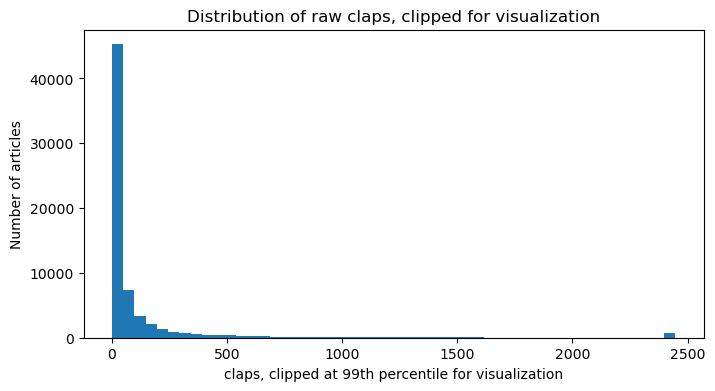

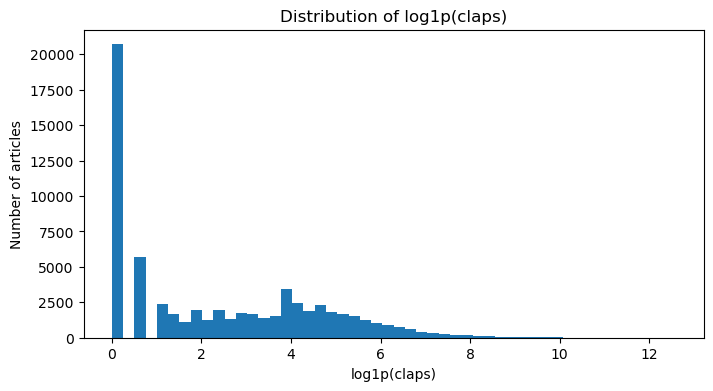

In [39]:
print("Raw claps summary:")
display(df["claps"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995]))

print("\nlog1p(claps) summary:")
display(df["log_claps"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995]))


# Exploratory clipped-target reference for target visualization
target_clip_value = df["log_claps"].quantile(0.995)
df["log_claps_clipped"] = df["log_claps"].clip(upper=target_clip_value)

print(f"\n99.5% log_claps clip value: {target_clip_value:.5f}")
print("Created exploratory column: log_claps_clipped")


# Extra target diagnostics
zero_rate = (df["claps"] == 0).mean()
one_or_less_rate = (df["claps"] <= 1).mean()
high_clap_rate = (df["claps"] >= 1000).mean()

print("\nTarget sparsity / tail diagnostics:")
print(f"Zero-clap articles:          {zero_rate:.2%}")
print(f"Articles with <= 1 clap:     {one_or_less_rate:.2%}")
print(f"Articles with >= 1000 claps: {high_clap_rate:.2%}")


# Raw claps are very skewed, so truncate only for visualization.
raw_clap_plot_limit = df["claps"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(df["claps"].clip(upper=raw_clap_plot_limit), bins=50)
plt.xlabel("claps, clipped at 99th percentile for visualization")
plt.ylabel("Number of articles")
plt.title("Distribution of raw claps, clipped for visualization")
plt.show()


plt.figure(figsize=(8, 4))
plt.hist(df["log_claps"], bins=50)
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Distribution of log1p(claps)")
plt.show()


The target exploration confirms that Medium claps are extremely skewed. 

For the raw `claps` target:

- Median article: **6 claps**
- 75th percentile: **65 claps**
- 90th percentile: **247 claps**
- 95th percentile: **540 claps**
- 99th percentile: **2,447 claps**
- Maximum: **291,706 claps**

This shows a very long-tailed popularity distribution: most articles receive very few claps, while a small number of viral articles receive extremely large numbers of claps.

> The raw clap distribution is highly skewed. Although the average article has about 173 claps, the median is only 6 claps, and the standard deviation is about 1,895 claps. This large standard deviation is driven by a small number of viral outliers, including articles with thousands or even hundreds of thousands of claps. As a result, the mean and standard deviation are less representative of a typical article than percentiles such as the median, 75th percentile, and 90th percentile.

The sparsity diagnostics show the same pattern:

- **31.33%** of articles have zero claps
- **39.94%** of articles have at most one clap
- Only **2.62%** of articles have at least 1,000 claps

Because the raw target is so skewed, modeling `log1p(claps)` is more appropriate than modeling raw clap counts directly. The log transformation compresses extreme values while keeping the target nonnegative.

The goal of `log1p` is not to make the target perfectly normal. The goal is to make the target easier to model by reducing the effect of extreme viral articles. In this dataset, the raw target ranges from:

```text
0 claps → 291,706 claps
```

After the log transformation, the target range becomes:

```text
0 → 12.58
```

The transformed target is much more manageable:

- Median `log1p(claps)`: **1.94591**
- 95th percentile: **6.29342**
- 99th percentile: **7.80319**
- Maximum: **12.58351**

For the main baseline, the notebook uses:

```python
TARGET_COL = "log_claps"
```

The 99.5th percentile value shown here is useful as an exploratory reference:

$$
\text{EDA reference clip value} = 8.39031
$$

To avoid target-distribution leakage, the clipped target used for modeling is recomputed **after the chronological split** using the training split only. That training-fitted clipped target is used later in the clipped-target Ridge and LightGBM experiments.


## Feature exploration

After exploring the target, the notebook inspects the raw feature columns that will be used for modeling.

The target distribution is inspected first because it determines the modeling objective and whether a transformation is needed. Since raw claps are highly skewed, the main target is `log1p(claps)`.

Feature exploration is also important before feature engineering. The final TF-IDF matrices will contain thousands of sparse columns and are not directly interpretable, so this section focuses on the raw columns that become features, such as:

- title text
- article body text
- metadata text
- author information
- publication information
- publication timestamp
- numeric metadata such as word count, reading time, image count, and link count

Simple text-length diagnostics are also created for the title and body. These checks confirm that the feature columns are populated, identify missing values, and show whether article length may be useful for predicting claps.


Preview of raw feature columns:


,title_text,body_text,metadata_text,author_clean,publication_clean,published_at,wordCount,readingTime,imageCount,linksCount,responsesCreatedCount,publicationfollowerCount,usersFollowedByCount
0,"Hey, white people! Wanna help the poor? Then s...","Hey, white people! Wanna help the poor? Then s...","Economics ECONOMICS,INNOVATION,SOCCER,RANDOM I...",Robert Martinez elrob,Immortal Puppy el-rob,2010-10-27 07:00:00+00:00,1034.0,3.901887,0.0,7.0,1.0,NaN,154.0
1,Machine Learning is Fun! The world’s easiest i...,Machine Learning is Fun! The world’s easiest i...,Machine Learning,Adam Geitgey ageitgey,,2014-05-05 17:47:05+00:00,3481.0,14.485849,12.0,41.0,198.0,NaN,40362.0
2,Mapbox Mars,Mapbox Mars By Matt Greene We’re launching two...,"Built With Mapbox MAPS,MOBILE,DATA VISUALIZATI...",Mapbox Mapbox,Points of interest mapbox,2015-03-10 04:00:00+00:00,359.0,1.354717,0.0,13.0,2.0,NaN,19037.0
3,The 7 Best Data Science and Machine Learning P...,The 7 Best Data Science and Machine Learning P...,"Podcast STARTUP,TECH,ENTREPRENEURSHIP,DESIGN,L...",Matt Fogel mattfogel,The Startup swlh,2015-04-20 15:02:47+00:00,530.0,3.350000,12.0,1.0,8.0,NaN,1472.0
4,Self-driving cars and the Trolley problem Goog...,Self-driving cars and the Trolley problem Goog...,Self Driving Cars,Tanay Jaipuria tanayj,,2015-05-23 22:38:15+00:00,1150.0,4.722956,2.0,2.0,70.0,NaN,2630.0


Missing-value rate by feature column:


publicationfollowerCount    1.0
title_text                  0.0
body_text                   0.0
metadata_text               0.0
author_clean                0.0
publication_clean           0.0
published_at                0.0
wordCount                   0.0
readingTime                 0.0
imageCount                  0.0
linksCount                  0.0
responsesCreatedCount       0.0
usersFollowedByCount        0.0
dtype: float64

Empty-string rate by text feature column:


...

,count,mean,std,min,50%,75%,90%,95%,99%,max
wordCount,66088.0,923.662102,871.760115,1.000000,721.000000,1159.000000,1789.000000,2356.000000,4073.260000,24964.000000
readingTime,66088.0,3.988673,3.509363,0.003774,3.184277,5.018868,7.590566,9.798066,16.525097,99.603774
imageCount,66088.0,3.553671,5.401063,0.000000,2.000000,4.000000,9.000000,12.000000,24.000000,263.000000
linksCount,66088.0,6.613561,11.764101,0.000000,4.000000,8.000000,15.000000,22.000000,45.000000,1180.000000
responsesCreatedCount,66088.0,0.906140,14.973456,0.000000,0.000000,0.000000,1.000000,3.000000,13.000000,3076.000000
publicationfollowerCount,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usersFollowedByCount,66088.0,1782.025920,13057.748510,0.000000,53.000000,325.250000,2010.300000,5690.000000,28669.000000,333655.000000


Text-length feature summary:


,count,mean,std,min,50%,75%,90%,95%,99%,max
title_length,66088.0,152.168578,53.048518,0.0,170.0,191.0,209.0,220.00,235.00,243.0
body_length,66088.0,5551.191366,5153.262256,1.0,4364.0,6952.0,10687.0,14085.00,24107.24,144508.0
metadata_length,66088.0,50.329757,41.688599,1.0,23.0,90.0,110.0,118.00,137.00,209.0
title_word_count_check,66088.0,24.773998,9.053427,0.0,27.0,32.0,35.0,37.00,40.00,50.0
body_word_count_check,66088.0,907.675705,850.258069,1.0,712.0,1139.0,1760.3,2304.65,3949.26,23788.0
metadata_word_count_check,66088.0,4.363273,3.306100,1.0,2.0,7.0,10.0,10.00,12.00,27.0


Publication-time feature summary:


,count,mean,std,min,25%,50%,75%,max
publication_year,66088.0,2017.751664,0.436580,2010.0,2018.0,2018.0,2018.0,2018.0
publication_month,66088.0,6.522621,3.205701,1.0,4.0,7.0,9.0,12.0
publication_dayofweek,66088.0,2.553913,1.869078,0.0,1.0,2.0,4.0,6.0
publication_hour,66088.0,12.518536,6.157981,0.0,8.0,13.0,17.0,23.0


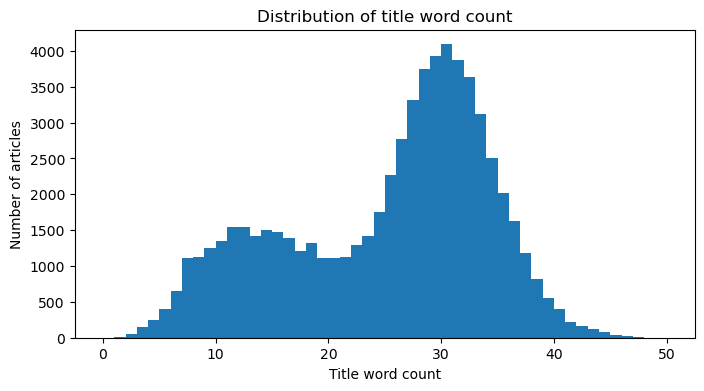

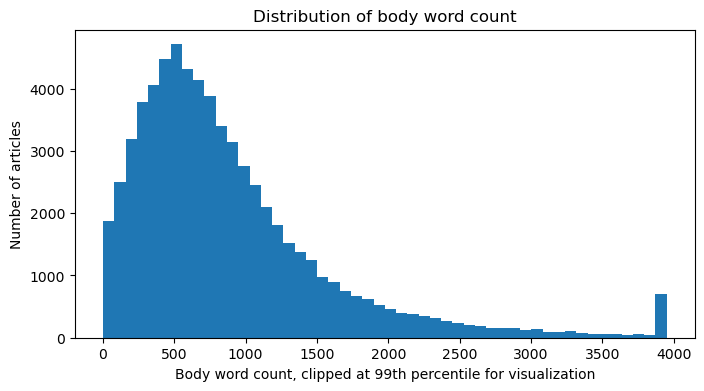

In [40]:
# Quick feature exploration

feature_check_cols = [
    "title_text",
    "body_text",
    "metadata_text",
    "author_clean",
    "publication_clean",
    "published_at",
    "wordCount",
    "readingTime",
    "imageCount",
    "linksCount",
    "responsesCreatedCount",
    "publicationfollowerCount",
    "usersFollowedByCount",
]

available_feature_check_cols = [
    col for col in feature_check_cols
    if col in df.columns
]

print("Preview of raw feature columns:")
display(df[available_feature_check_cols].head())


# Missing-value rates
missing_rates = (
    df[available_feature_check_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("Missing-value rate by feature column:")
display(missing_rates)


# Empty-string rates for text columns
text_feature_cols = [
    "title_text",
    "body_text",
    "metadata_text",
    "author_clean",
    "publication_clean",
]

available_text_feature_cols = [
    col for col in text_feature_cols
    if col in df.columns
]

empty_string_rates = {}

for col in available_text_feature_cols:
    empty_string_rates[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .mean()
    )

empty_string_rates = (
    pd.Series(empty_string_rates)
    .sort_values(ascending=False)
)

print("Empty-string rate by text feature column:")
display(empty_string_rates)


# Numeric metadata summaries
numeric_feature_cols = [
    "wordCount",
    "readingTime",
    "imageCount",
    "linksCount",
    "responsesCreatedCount",
    "publicationfollowerCount",
    "usersFollowedByCount",
]

available_numeric_feature_cols = [
    col for col in numeric_feature_cols
    if col in df.columns
]

if available_numeric_feature_cols:
    print("Numeric metadata feature summary:")
    display(
        df[available_numeric_feature_cols]
        .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
        .T
    )


# Text-length diagnostics
df["title_length"] = df["title_text"].fillna("").astype(str).str.len()
df["body_length"] = df["body_text"].fillna("").astype(str).str.len()
df["metadata_length"] = df["metadata_text"].fillna("").astype(str).str.len()

df["title_word_count_check"] = (
    df["title_text"]
    .fillna("")
    .astype(str)
    .str.count(r"\S+")
)

df["body_word_count_check"] = (
    df["body_text"]
    .fillna("")
    .astype(str)
    .str.count(r"\S+")
)

df["metadata_word_count_check"] = (
    df["metadata_text"]
    .fillna("")
    .astype(str)
    .str.count(r"\S+")
)

text_length_cols = [
    "title_length",
    "body_length",
    "metadata_length",
    "title_word_count_check",
    "body_word_count_check",
    "metadata_word_count_check",
]

print("Text-length feature summary:")
display(
    df[text_length_cols]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)


# Publication-time diagnostics
df["publication_year"] = df["published_at"].dt.year
df["publication_month"] = df["published_at"].dt.month
df["publication_dayofweek"] = df["published_at"].dt.dayofweek
df["publication_hour"] = df["published_at"].dt.hour

print("Publication-time feature summary:")
display(
    df[
        [
            "publication_year",
            "publication_month",
            "publication_dayofweek",
            "publication_hour",
        ]
    ]
    .describe()
    .T
)


# Simple visual checks for article/title length
plt.figure(figsize=(8, 4))
plt.hist(df["title_word_count_check"], bins=50)
plt.xlabel("Title word count")
plt.ylabel("Number of articles")
plt.title("Distribution of title word count")
plt.show()

body_word_plot_limit = df["body_word_count_check"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(
    df["body_word_count_check"].clip(upper=body_word_plot_limit),
    bins=50,
)
plt.xlabel("Body word count, clipped at 99th percentile for visualization")
plt.ylabel("Number of articles")
plt.title("Distribution of body word count")
plt.show()

The raw feature exploration shows that the main feature columns are usable for modeling.

The key text fields are mostly populated:

- `title_text`: almost fully populated, with only about **0.003%** empty values
- `body_text`: fully populated
- `metadata_text`: fully populated
- `author_clean`: fully populated

The main exception is `publication_clean`, which is empty for about **53.17%** of rows. This means publication information may still be useful when available, but the model should also include a missing-publication indicator.

The numeric metadata features also look useful, but many of them are highly skewed:

- Median `wordCount`: **721**
- 99th percentile `wordCount`: **4,073**
- Maximum `wordCount`: **24,964**
- Median `linksCount`: **4**
- 99th percentile `linksCount`: **45**
- Maximum `linksCount`: **1,180**
- Median `usersFollowedByCount`: **53**
- 99th percentile `usersFollowedByCount`: **28,669**
- Maximum `usersFollowedByCount`: **333,655**

These long-tailed numeric features should be log-transformed before modeling.

One column, `publicationfollowerCount`, is entirely missing in the final English dataset, so it should not be used as a modeling feature.

The text-length diagnostics also show useful variation:

- Median title word count: **27**
- Median body word count: **712**
- 99th percentile body word count: about **3,949**
- Maximum body word count: **23,788**

This suggests that article length and title length may contain useful signal for predicting claps.

The publication-time fields are also usable:

- No missing publication dates
- Articles are mostly from **2017–2018**
- Publication month, weekday, and hour can all be converted into model features

These checks guide the next step: transforming the raw columns into model-ready features. The feature engineering step creates text features, numeric metadata features, log-transformed count features, missing-value indicators, and publication-time features. The final TF-IDF matrices are built later after the chronological split, because vectorizers must be fitted only on the training split to avoid validation leakage.

>I did not use model-based feature selection before training. Instead, I first selected features based on data quality, prediction-time availability, interpretability, and leakage risk. After training, I used validation performance, feature importance, and ablation experiments to understand which feature groups were most useful.

In [41]:
print(df.shape)

(66088, 76)


In [42]:
len(df.columns) # 76

df.columns

Index(['audioVersionDurationSec', 'codeBlock', 'codeBlockCount',
       'collectionId', 'createdDate', 'createdDatetime', 'firstPublishedDate',
       'firstPublishedDatetime', 'imageCount', 'isSubscriptionLocked',
       'language', 'latestPublishedDate', 'latestPublishedDatetime',
       'linksCount', 'postId', 'readingTime', 'recommends',
       'responsesCreatedCount', 'socialRecommendsCount', 'subTitle',
       'tagsCount', 'text', 'title', 'totalClapCount', 'uniqueSlug',
       'updatedDate', 'updatedDatetime', 'url', 'vote', 'wordCount',
       'publicationdescription', 'publicationdomain',
       'publicationfacebookPageName', 'publicationfollowerCount',
       'publicationname', 'publicationpublicEmail', 'publicationslug',
       'publicationtags', 'publicationtwitterUsername', 'tag_name', 'slug',
       'name', 'postCount', 'author', 'bio', 'userId', 'userName',
       'usersFollowedByCount', 'usersFollowedCount', 'scrappedDate', 'claps',
       'reading_time', 'link', 'autho

## Feature engineering and row-level transformations

The raw, interpretable columns are converted into cleaner model-ready feature columns.

This step only creates row-level features that do not require fitting on the full dataset. That means it is safe to do before the chronological train/validation/test split.

The transformations include:

- cleaning and filling text fields
- creating title/body/metadata length features
- creating missing-value indicators for important text fields
- log-transforming skewed numeric metadata columns
- creating ratios such as links per 1,000 words and images per 1,000 words
- extracting publication-time features such as year, month, weekday, hour, and weekend
- adding cyclical encodings for month, weekday, and hour

Obvious engagement/leakage columns are avoided as features. Since the target is `claps`, columns such as `recommends`, `responsesCreatedCount`, `socialRecommendsCount`, and `vote` are post-publication engagement signals. They may be correlated with claps, but they would not be available if the goal is to predict engagement from article content and metadata before engagement happens.

A practical caveat: author-level follower columns such as `usersFollowedByCount` are dataset-provided metadata, but their exact timestamp may reflect scrape time rather than publication time. They are kept in this portfolio model because they provide useful author-context signal, but a stricter launch-time production system should replace them with timestamped author-history features or remove them.

After this step, we are ready to create a chronological validation split and build leakage-free TF-IDF, categorical, numeric, SVD, and target-encoding feature matrices.


In [43]:
# Feature engineering and row-level transformations

df_features = df.copy()

# ---------------------------------------------------------------------
# 1. Clean text fields
# ---------------------------------------------------------------------

text_columns = [
    "title_text",
    "body_text",
    "metadata_text",
    "author_clean",
    "publication_clean",
]

for col in text_columns:
    df_features[col] = (
        df_features[col]
        .fillna("")
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


# ---------------------------------------------------------------------
# 2. Text missing-value indicators
# ---------------------------------------------------------------------

df_features["title_is_empty"] = df_features["title_text"].eq("").astype(np.int8)
df_features["body_is_empty"] = df_features["body_text"].eq("").astype(np.int8)
df_features["metadata_is_empty"] = df_features["metadata_text"].eq("").astype(np.int8)
df_features["author_is_empty"] = df_features["author_clean"].eq("").astype(np.int8)
df_features["publication_is_empty"] = df_features["publication_clean"].eq("").astype(np.int8)


# ---------------------------------------------------------------------
# 3. Text length and structure features
# ---------------------------------------------------------------------

df_features["title_char_count"] = df_features["title_text"].str.len()
df_features["body_char_count"] = df_features["body_text"].str.len()
df_features["metadata_char_count"] = df_features["metadata_text"].str.len()

df_features["title_word_count"] = df_features["title_text"].str.count(r"\S+")
df_features["body_word_count"] = df_features["body_text"].str.count(r"\S+")
df_features["metadata_word_count"] = df_features["metadata_text"].str.count(r"\S+")

df_features["title_avg_word_length"] = (
    df_features["title_char_count"]
    / df_features["title_word_count"].clip(lower=1)
)

df_features["body_avg_word_length"] = (
    df_features["body_char_count"]
    / df_features["body_word_count"].clip(lower=1)
)

df_features["title_has_question"] = df_features["title_text"].str.contains(r"\?", regex=True).astype(np.int8)
df_features["title_has_exclamation"] = df_features["title_text"].str.contains(r"!", regex=True).astype(np.int8)
df_features["title_has_digit"] = df_features["title_text"].str.contains(r"\d", regex=True).astype(np.int8)

df_features["body_question_count"] = df_features["body_text"].str.count(r"\?")
df_features["body_exclamation_count"] = df_features["body_text"].str.count(r"!")
df_features["body_sentence_count"] = df_features["body_text"].str.count(r"[.!?]+")

df_features["body_avg_sentence_length"] = (
    df_features["body_word_count"]
    / df_features["body_sentence_count"].clip(lower=1)
)


# ---------------------------------------------------------------------
# 4. Numeric metadata features
# ---------------------------------------------------------------------

# These are content and dataset-provided author/article metadata columns.
# I intentionally avoid engagement-like columns such as recommends,
# responsesCreatedCount, socialRecommendsCount, and vote.
# For strict launch-time production use, scrape-time author-count columns
# should be replaced with timestamped author-history features or removed.

candidate_numeric_cols = [
    "wordCount",
    "readingTime",
    "imageCount",
    "linksCount",
    "tagsCount",
    "usersFollowedByCount",
    "usersFollowedCount",
    "codeBlockCount",
    "audioVersionDurationSec",
]

available_numeric_cols = [
    col for col in candidate_numeric_cols
    if col in df_features.columns
]

all_missing_numeric_cols = []

for col in available_numeric_cols:
    numeric_values = pd.to_numeric(df_features[col], errors="coerce")

    if numeric_values.notna().sum() == 0:
        all_missing_numeric_cols.append(col)
        continue

    df_features[f"{col}_missing"] = numeric_values.isna().astype(np.int8)

    # For count-like metadata, missing is treated as 0 after adding a missing indicator.
    numeric_values = numeric_values.fillna(0)

    # Avoid negative values before log1p.
    numeric_values_nonnegative = numeric_values.clip(lower=0)

    df_features[f"{col}_value"] = numeric_values.astype(np.float32)
    df_features[f"log1p_{col}"] = np.log1p(numeric_values_nonnegative).astype(np.float32)

print("Available numeric columns used:")
print(available_numeric_cols)

if all_missing_numeric_cols:
    print("\nNumeric columns skipped because they are entirely missing:")
    print(all_missing_numeric_cols)


# ---------------------------------------------------------------------
# 5. Ratio features
# ---------------------------------------------------------------------

# Use engineered word count as denominator to avoid division by zero.
body_words = df_features["body_word_count"].clip(lower=1)

if "linksCount_value" in df_features.columns:
    df_features["links_per_1000_words"] = (
        1000 * df_features["linksCount_value"] / body_words
    ).astype(np.float32)

if "imageCount_value" in df_features.columns:
    df_features["images_per_1000_words"] = (
        1000 * df_features["imageCount_value"] / body_words
    ).astype(np.float32)

if "wordCount_value" in df_features.columns:
    df_features["body_word_count_ratio_to_metadata_wordCount"] = (
        df_features["body_word_count"]
        / df_features["wordCount_value"].clip(lower=1)
    ).astype(np.float32)


# ---------------------------------------------------------------------
# 6. Publication-time features
# ---------------------------------------------------------------------

published = df_features["published_at"]

df_features["publication_year"] = published.dt.year.astype(np.float32)
df_features["publication_month"] = published.dt.month.astype(np.float32)
df_features["publication_dayofweek"] = published.dt.dayofweek.astype(np.float32)
df_features["publication_hour"] = published.dt.hour.astype(np.float32)

df_features["is_weekend"] = df_features["publication_dayofweek"].isin([5, 6]).astype(np.int8)
df_features["is_morning"] = df_features["publication_hour"].between(6, 11).astype(np.int8)
df_features["is_day"] = df_features["publication_hour"].between(12, 17).astype(np.int8)
df_features["is_night"] = (
    (df_features["publication_hour"] >= 18)
    | (df_features["publication_hour"] < 6)
).astype(np.int8)

# Use a fixed reference date to avoid learning a reference point from the full dataset.
reference_date = pd.Timestamp("2010-01-01", tz="UTC")
df_features["days_since_2010"] = (
    (df_features["published_at"] - reference_date)
    .dt.total_seconds()
    .div(24 * 60 * 60)
    .astype(np.float32)
)

# Cyclical time encodings
df_features["hour_sin"] = np.sin(2 * np.pi * df_features["publication_hour"] / 24)
df_features["hour_cos"] = np.cos(2 * np.pi * df_features["publication_hour"] / 24)

df_features["dayofweek_sin"] = np.sin(2 * np.pi * df_features["publication_dayofweek"] / 7)
df_features["dayofweek_cos"] = np.cos(2 * np.pi * df_features["publication_dayofweek"] / 7)

df_features["month_sin"] = np.sin(2 * np.pi * df_features["publication_month"] / 12)
df_features["month_cos"] = np.cos(2 * np.pi * df_features["publication_month"] / 12)


# ---------------------------------------------------------------------
# 7. Define feature groups for later modeling
# ---------------------------------------------------------------------

text_feature_cols_for_tfidf = [
    "title_text",
    "body_text",
    "metadata_text",
]

categorical_text_cols = [
    "author_clean",
    "publication_clean",
]

numeric_feature_cols = [
    # text missing indicators
    "title_is_empty",
    "body_is_empty",
    "metadata_is_empty",
    "author_is_empty",
    "publication_is_empty",

    # text length features
    "title_char_count",
    "body_char_count",
    "metadata_char_count",
    "title_word_count",
    "body_word_count",
    "metadata_word_count",
    "title_avg_word_length",
    "body_avg_word_length",
    "title_has_question",
    "title_has_exclamation",
    "title_has_digit",
    "body_question_count",
    "body_exclamation_count",
    "body_sentence_count",
    "body_avg_sentence_length",

    # publication-time features
    "publication_year",
    "publication_month",
    "publication_dayofweek",
    "publication_hour",
    "is_weekend",
    "is_morning",
    "is_day",
    "is_night",
    "days_since_2010",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "month_sin",
    "month_cos",
]

# Add transformed numeric metadata features
numeric_feature_cols += [
    col for col in df_features.columns
    if col.endswith("_missing")
    or col.endswith("_value")
    or col.startswith("log1p_")
    or col in [
        "links_per_1000_words",
        "images_per_1000_words",
        "body_word_count_ratio_to_metadata_wordCount",
    ]
]

# Remove duplicates while preserving order
numeric_feature_cols = list(dict.fromkeys(numeric_feature_cols))

print("\nFeature groups prepared:")
print(f"TF-IDF text columns:        {text_feature_cols_for_tfidf}")
print(f"Categorical text columns:   {categorical_text_cols}")
print(f"Numeric feature count:      {len(numeric_feature_cols)}")

print("\nFirst 20 numeric features:")
print(numeric_feature_cols[:20])

display(
    df_features[
        [
            "title_text",
            "body_text",
            "metadata_text",
            "author_clean",
            "publication_clean",
            "log_claps",
        ]
        + numeric_feature_cols[:10]
    ].head()
)


Available numeric columns used:
['wordCount', 'readingTime', 'imageCount', 'linksCount', 'tagsCount', 'usersFollowedByCount', 'usersFollowedCount', 'codeBlockCount', 'audioVersionDurationSec']

Feature groups prepared:
TF-IDF text columns:        ['title_text', 'body_text', 'metadata_text']
Categorical text columns:   ['author_clean', 'publication_clean']
Numeric feature count:      65

First 20 numeric features:
['title_is_empty', 'body_is_empty', 'metadata_is_empty', 'author_is_empty', 'publication_is_empty', 'title_char_count', 'body_char_count', 'metadata_char_count', 'title_word_count', 'body_word_count', 'metadata_word_count', 'title_avg_word_length', 'body_avg_word_length', 'title_has_question', 'title_has_exclamation', 'title_has_digit', 'body_question_count', 'body_exclamation_count', 'body_sentence_count', 'body_avg_sentence_length']


,title_text,body_text,metadata_text,author_clean,publication_clean,log_claps,title_is_empty,body_is_empty,metadata_is_empty,author_is_empty,publication_is_empty,title_char_count,body_char_count,metadata_char_count,title_word_count,body_word_count
0,"Hey, white people! Wanna help the poor? Then s...","Hey, white people! Wanna help the poor? Then s...","Economics ECONOMICS,INNOVATION,SOCCER,RANDOM I...",Robert Martinez elrob,Immortal Puppy el-rob,3.951244,0,0,0,0,0,189,6123,59,33,1018
1,Machine Learning is Fun! The world’s easiest i...,Machine Learning is Fun! The world’s easiest i...,Machine Learning,Adam Geitgey ageitgey,,10.979752,0,0,0,0,1,77,18909,16,11,3351
2,Mapbox Mars,Mapbox Mars By Matt Greene We’re launching two...,"Built With Mapbox MAPS,MOBILE,DATA VISUALIZATI...",Mapbox Mapbox,Points of interest mapbox,0.693147,0,0,0,0,0,11,2170,86,2,351
3,The 7 Best Data Science and Machine Learning P...,The 7 Best Data Science and Machine Learning P...,"Podcast STARTUP,TECH,ENTREPRENEURSHIP,DESIGN,L...",Matt Fogel mattfogel,The Startup swlh,6.874198,0,0,0,0,0,135,3263,61,24,528
4,Self-driving cars and the Trolley problem Goog...,Self-driving cars and the Trolley problem Goog...,Self Driving Cars,Tanay Jaipuria tanayj,,7.045777,0,0,0,0,1,181,6207,17,26,1148


<details>
<summary><span style="color:red">  

what changed between `df.columns` and `df_features.columns`:
</span></summary>  

A lot changed between `df.columns` and `df_features.columns`, but the change is exactly what should happen in the **Feature engineering and row-level transformations** section.

In simple terms:

`df` is our cleaned modeling dataframe.

`df_features` is `df` plus newly engineered row-level features.

So we did **not replace** the original columns. we mostly **added new columns** derived from text, metadata, numeric fields, and publication time.


## What stayed the same?

All original columns from `df` are still present in `df_features`.

For example, these were already in `df` and remain in `df_features`:

```text
title_text
body_text
metadata_text
author_clean
publication_clean
log_claps
sort_time
log_claps_clipped
publication_year
publication_month
publication_dayofweek
publication_hour
```

So `df_features` keeps the original cleaned dataset and adds extra modeling features.  

## What was added? 

The feature engineering step added several groups of new row-level features.

### 1. Empty-text indicators (+5)

These columns check whether important text/categorical fields are empty:

```text
title_is_empty
body_is_empty
metadata_is_empty
author_is_empty
publication_is_empty
```

These are useful because missing or empty text can itself carry predictive information.

For example, articles with no body text or missing publication information may behave differently.


### 2. Text length and word-count features (+8)

These columns measure the size of the title, body, and metadata text:

```text
title_char_count
body_char_count
metadata_char_count
title_word_count
body_word_count
metadata_word_count
title_avg_word_length
body_avg_word_length
```

These are row-level numeric summaries of the text.

They are different from TF-IDF. TF-IDF learns vocabulary patterns later, while these features simply describe the article’s length and structure.


### 3. Title/body punctuation and style features (+7)

These columns capture simple writing-style signals:

```text
title_has_question
title_has_exclamation
title_has_digit
body_question_count
body_exclamation_count
body_sentence_count
body_avg_sentence_length
```

These features help the model learn whether certain title/body styles are associated with engagement.

For example, question-style titles, exclamation marks, or longer sentence structures might correlate with different clap behavior.


### 4. Missing-value flags and cleaned numeric values (+27)
For several original numeric columns, the notebook created three versions:

Example for `wordCount`:

```text
wordCount_missing
wordCount_value
log1p_wordCount
```

This pattern is repeated for:

```text
wordCount
readingTime
imageCount
linksCount
tagsCount
usersFollowedByCount
usersFollowedCount
codeBlockCount
audioVersionDurationSec
```

So for each raw numeric variable, we now have:

| Feature type          | Example             | Meaning                                |
| --------------------- | ------------------- | -------------------------------------- |
| Missing flag          | `wordCount_missing` | Whether the original value was missing |
| Clean numeric value   | `wordCount_value`   | Filled/cleaned numeric version         |
| Log-transformed value | `log1p_wordCount`   | Compressed version for skewed counts   |

This is useful because count-based features are often skewed. For example, most articles may have a small number of links or images, while a few have many. `log1p(...)` makes those variables less extreme. 

### 5. Ratio features (+3)

These columns compare article elements relative to article length:

```text
links_per_1000_words
images_per_1000_words
body_word_count_ratio_to_metadata_wordCount
```

These are more informative than raw counts alone.

For example, 10 links in a 500-word article means something different from 10 links in a 5,000-word article.


### 6. Time-based features (+11)

These features describe when the article was published:

```text
is_weekend
is_morning
is_day
is_night
days_since_2010
hour_sin
hour_cos
dayofweek_sin
dayofweek_cos
month_sin
month_cos
```

Some of these are simple indicators:

```text
is_weekend
is_morning
is_day
is_night
```

Others are cyclical encodings:

```text
hour_sin
hour_cos
dayofweek_sin
dayofweek_cos
month_sin
month_cos
```

Cyclical encoding is useful because time variables wrap around. For example, hour `23` and hour `0` are close in real life, but numerically they look far apart. Sine/cosine encoding helps the model understand that circular structure.


## What does this mean for our notebook?

This transition is correct:

```text
df
```

contains the cleaned dataset and basic parsed fields (`len(df.columns) == 76`).

```text
df_features
```

contains the cleaned dataset plus engineered features that are ready for modeling (`len(df_features.columns) == 137`).

So:  

The feature engineering step keeps the cleaned dataset intact and adds row-level predictive features. These include missing-value indicators, text length statistics, punctuation/style features, log-transformed numeric metadata, ratio features, and time-based publication features.

At this stage, the notebook still has not fitted any data-dependent transformations such as TF-IDF, scaling, target encoding, or SVD. The added columns are computed independently for each row, so they can be safely created before the chronological train/validation/test split.


## Important clarification

These engineered columns are **not leakage by themselves** because they are calculated from each article’s own content or metadata.

For example:

```text
title_word_count
log1p_wordCount
is_weekend
hour_sin
```

do not require looking at validation or test targets.

But transformations that **learn from multiple rows**, such as TF-IDF, scalers, imputers, target encoders, and SVD, must still be fitted only after the chronological split using training data only.


</details>

In [44]:
df_features.shape

(66088, 137)

In [45]:
for i in df_features.columns:
    print(i)

audioVersionDurationSec
codeBlock
codeBlockCount
collectionId
createdDate
createdDatetime
firstPublishedDate
firstPublishedDatetime
imageCount
isSubscriptionLocked
language
latestPublishedDate
latestPublishedDatetime
linksCount
postId
readingTime
recommends
responsesCreatedCount
socialRecommendsCount
subTitle
tagsCount
text
title
totalClapCount
uniqueSlug
updatedDate
updatedDatetime
url
vote
wordCount
publicationdescription
publicationdomain
publicationfacebookPageName
publicationfollowerCount
publicationname
publicationpublicEmail
publicationslug
publicationtags
publicationtwitterUsername
tag_name
slug
name
postCount
author
bio
userId
userName
usersFollowedByCount
usersFollowedCount
scrappedDate
claps
reading_time
link
authors
timestamp
tags
post_id
published_at
title_text
body_text
metadata_text
author_clean
publication_clean
log_claps
sort_time
log_claps_clipped
title_length
body_length
metadata_length
title_word_count_check
body_word_count_check
metadata_word_count_check
publicatio

The row-level feature engineering step completed successfully.

The feature groups are now prepared for modeling:

- TF-IDF text columns: `title_text`, `body_text`, `metadata_text`
- Categorical text columns: `author_clean`, `publication_clean`
- Numeric feature count: **65**

The numeric feature set includes text-length features, missing-value indicators, publication-time features, cyclical time encodings, log-transformed metadata features, and ratio features.

The available numeric metadata columns used were:

- `wordCount`
- `readingTime`
- `imageCount`
- `linksCount`
- `tagsCount`
- `usersFollowedByCount`
- `usersFollowedCount`
- `codeBlockCount`
- `audioVersionDurationSec`

This is useful because many of these columns were highly skewed in the feature exploration step, so the engineered feature set includes both raw values and `log1p(...)` versions where appropriate.

The preview also confirms that the text fields and engineered indicators look reasonable. For example, rows with missing publication information are captured by `publication_is_empty`, while title/body/metadata lengths are now available as numeric features.

Importantly, this step only created row-level features. It did not fit any data-dependent transformations such as TF-IDF vectorizers, scalers, SVD dimensionality-reduction components, or encoders. Those transformations are fitted only after the chronological train/validation/test split, using the training data only, to avoid validation and test leakage.


The next step is to create a chronological validation split and prepare the raw train/validation pieces that will later be transformed into sparse model-ready feature matrices.


>The modeling feature groups are ready:
>
>- Text fields for TF-IDF: `title_text`, `body_text`, `metadata_text`
>- Categorical text fields: `author_clean`, `publication_clean`
>- Selected numeric modeling features: **65 columns**
>
>Together, these represent **70 selected model input fields/groups** from `df_features`.
>
>`df_features` contains more columns than this (137 columns) because it also keeps raw fields, identifiers, timestamps, target columns, and helper columns for cleaning, inspection, chronological splitting, evaluation, and traceability. Only the selected text, categorical, and numeric feature columns are passed into the modeling pipeline.

## Chronological train/validation/test split

Now that the row-level features are prepared, I create a chronological train/validation/test split.

Because the goal is to estimate how well the model can predict engagement for future articles, I split the data by publication time rather than using a random split. A random split or standard cross-validation could mix older and newer articles across folds, allowing future distribution patterns to influence model development indirectly. That would make the validation setup less realistic for this problem.

This split must happen before fitting any data-dependent transformations, including TF-IDF vectorizers, categorical vectorizers, imputers, scalers, target encoders, or SVD dimensionality-reduction components. Otherwise, information from later articles could influence learned vocabularies, IDF weights, category mappings, imputation values, scaling parameters, target-encoding statistics, or SVD components.

The split is based on publication time:

- earliest **70%** → training set
- next **15%** → validation set
- latest **15%** → held-out test set

The validation set is used for model selection, hyperparameter tuning, blend-weight tuning, and calibration decisions. The held-out test set is used for final benchmark reporting and error analysis; no model settings are selected from test metrics.

I chose this approach instead of standard random cross-validation because the dataset is temporal: article topics, platform behavior, publication patterns, and audience engagement can shift over time. A chronological split better simulates the real use case of training on past articles and evaluating on later articles.   

For the main baseline, I use `log_claps` as the target. The clipped target used in later experiments is recomputed after the split using the training split only, so the clipping threshold is not learned from validation or test targets.


>A more extensive alternative would be walk-forward or time-series cross-validation, where several chronological train/validation folds are evaluated. I use a single chronological validation split plus a final chronological test split here because it keeps the workflow clear, computationally manageable, and aligned with the goal of simulating future-article prediction.


In [46]:
# Create chronological train/validation/test split

TARGET_COL = "log_claps"

# Optional later experiment:
# TARGET_COL = "log_claps_clipped"

TRAIN_FRACTION = 0.70
VALID_FRACTION = 0.15
TEST_FRACTION = 0.15

if not np.isclose(TRAIN_FRACTION + VALID_FRACTION + TEST_FRACTION, 1.0):
    raise ValueError("Train/validation/test fractions must sum to 1.")

model_df = df_features.copy()

# Make sure rows are chronologically ordered.
model_df = model_df.sort_values("sort_time").reset_index(drop=True)

if TARGET_COL not in model_df.columns:
    raise ValueError(f"Target column not found: {TARGET_COL}")

if model_df["published_at"].isna().sum() > 0:
    raise ValueError("There are missing publication dates. Chronological split may be unreliable.")

n_rows = len(model_df)

train_end = int(TRAIN_FRACTION * n_rows)
valid_end = int((TRAIN_FRACTION + VALID_FRACTION) * n_rows)

train_df = model_df.iloc[:train_end].copy().reset_index(drop=True)
valid_df = model_df.iloc[train_end:valid_end].copy().reset_index(drop=True)
test_df = model_df.iloc[valid_end:].copy().reset_index(drop=True)

# Recompute the clipped target after the split using the training target only.
# This avoids using validation/test target distribution information to define
# the training target transformation. It intentionally overwrites the
# exploratory full-data clipped column created during target exploration.
TARGET_CLIP_QUANTILE = 0.995
target_clip_value_train = train_df["log_claps"].quantile(TARGET_CLIP_QUANTILE)

for split_frame in [train_df, valid_df, test_df]:
    split_frame["log_claps_clipped"] = split_frame["log_claps"].clip(
        upper=target_clip_value_train
    )

y_train = train_df[TARGET_COL].values
y_valid = valid_df[TARGET_COL].values
y_test = test_df[TARGET_COL].values

print(f"Target column:       {TARGET_COL}")
print(f"Total rows:          {n_rows:,}")
print(f"Training rows:       {len(train_df):,}")
print(f"Validation rows:     {len(valid_df):,}")
print(f"Test rows:           {len(test_df):,}")
print()
print(f"Training fraction:   {len(train_df) / n_rows:.2%}")
print(f"Validation fraction: {len(valid_df) / n_rows:.2%}")
print(f"Test fraction:       {len(test_df) / n_rows:.2%}")

print("\nDate ranges:")
print(f"Train:      {train_df['published_at'].min()} -> {train_df['published_at'].max()}")
print(f"Validation: {valid_df['published_at'].min()} -> {valid_df['published_at'].max()}")
print(f"Test:       {test_df['published_at'].min()} -> {test_df['published_at'].max()}")

print("\nTarget summaries:")
print(f"Train target mean:      {y_train.mean():.5f}")
print(f"Validation target mean: {y_valid.mean():.5f}")
print(f"Test target mean:       {y_test.mean():.5f}")
print()
print(f"Train target median:      {np.median(y_train):.5f}")
print(f"Validation target median: {np.median(y_valid):.5f}")
print(f"Test target median:       {np.median(y_test):.5f}")

print("\nFeature groups:")
print(f"TF-IDF text columns:      {text_feature_cols_for_tfidf}")
print(f"Categorical text columns: {categorical_text_cols}")
print(f"Numeric feature count:    {len(numeric_feature_cols)}")

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(valid_df), len(test_df)],
    "start_date": [
        train_df["published_at"].min(),
        valid_df["published_at"].min(),
        test_df["published_at"].min(),
    ],
    "end_date": [
        train_df["published_at"].max(),
        valid_df["published_at"].max(),
        test_df["published_at"].max(),
    ],
    "target_mean": [
        y_train.mean(),
        y_valid.mean(),
        y_test.mean(),
    ],
    "target_median": [
        np.median(y_train),
        np.median(y_valid),
        np.median(y_test),
    ],
})

display(split_summary)


Target column:       log_claps
Total rows:          66,088
Training rows:       46,261
Validation rows:     9,913
Test rows:           9,914

Training fraction:   70.00%
Validation fraction: 15.00%
Test fraction:       15.00%

Date ranges:
Train:      2010-10-27 07:00:00+00:00 -> 2018-06-21 20:45:32+00:00
Validation: 2018-06-21 21:03:12+00:00 -> 2018-08-13 21:55:57+00:00
Test:       2018-08-13 21:59:32+00:00 -> 2018-09-30 23:52:12+00:00

Target summaries:
Train target mean:      2.45630
Validation target mean: 2.30318
Test target mean:       2.08826

Train target median:      2.07944
Validation target median: 1.79176
Test target median:       1.38629

Feature groups:
TF-IDF text columns:      ['title_text', 'body_text', 'metadata_text']
Categorical text columns: ['author_clean', 'publication_clean']
Numeric feature count:    65


,split,rows,start_date,end_date,target_mean,target_median
0,train,46261,2010-10-27 07:00:00+00:00,2018-06-21 20:45:32+00:00,2.456296,2.079442
1,validation,9913,2018-06-21 21:03:12+00:00,2018-08-13 21:55:57+00:00,2.303179,1.791759
2,test,9914,2018-08-13 21:59:32+00:00,2018-09-30 23:52:12+00:00,2.088255,1.386294


The chronological train/validation/test split was created successfully.

The final dataset contains **66,088** English Medium articles and was split by publication time into:

- Training set: **46,261 rows** (**70%**)
- Validation set: **9,913 rows** (**15%**)
- Test set: **9,914 rows** (**15%**)

The date ranges are clean and non-overlapping:

- Train: **2010-10-27 → 2018-06-21**
- Validation: **2018-06-21 → 2018-08-13**
- Test: **2018-08-13 → 2018-09-30**

This setup better simulates future prediction: the model learns from earlier articles and is evaluated on later articles.

The target summaries show some temporal drift:

- Train mean `log_claps`: **2.45630**
- Validation mean `log_claps`: **2.30318**
- Test mean `log_claps`: **2.08826**

The medians also decrease over time:

- Train median: **2.07944**
- Validation median: **1.79176**
- Test median: **1.38629**

This means later articles in the dataset tend to have fewer claps on average. That makes the chronological split more realistic, but also more challenging than a random split.

The feature groups are ready for modeling:

- TF-IDF text columns: `title_text`, `body_text`, `metadata_text`
- Categorical text columns: `author_clean`, `publication_clean`
- Numeric feature count: **65**

The clipped target used in later experiments is also defined **after the split**, using only the training target distribution. The next step is to build leakage-free sparse feature matrices: vectorizers, encoders, imputers, scalers, and SVD dimensionality-reduction components are fitted only on the appropriate training data, then applied to the validation and test rows.


## Building leakage-free sparse feature matrices

The split dataframes are converted into model-ready sparse matrices.

This step must be handled carefully to avoid validation and test leakage. Any object that learns from data is fitted only on the training split:

- TF-IDF vectorizers are fitted only on training text.
- Categorical vectorizers are fitted only on training author/publication fields.
- Numeric imputers and scalers are fitted only on training numeric features.
- Validation and test rows are transformed using the fitted training objects.

The final sparse feature matrix combines:

1. Body TF-IDF features from `body_text`
2. Title TF-IDF features from `title_text`
3. Metadata/tag TF-IDF features from `metadata_text`
4. Sparse categorical features from `author_clean`
5. Sparse categorical features from `publication_clean`
6. Scaled numeric features from the engineered row-level feature set

This is stronger than using only publication-time features as numeric inputs because the numeric block now includes text lengths, missing-value indicators, log-transformed metadata counts, ratio features, and cyclical time features.

The resulting matrices are:

- `X_train_sparse`
- `X_valid_sparse`
- `X_test_sparse`

These matrices are used for Ridge regression and as the source matrix for later SVD-compressed sparse features in LightGBM.


In [47]:
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


def fit_sparse_feature_builders(train_frame, numeric_cols):
    """
    Fit all sparse feature builders on the training split only.

    This avoids validation/test leakage because the vocabulary,
    category mappings, imputation values, and scaling parameters
    are learned only from the training data.
    """
    builders = {}

    # Text TF-IDF vectorizers 
    # I configured the TfidfVectorizer with the following parameters:
    builders["body_vectorizer"] = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=150_000,
        sublinear_tf=True,
        dtype=np.float32,
    )

    builders["title_vectorizer"] = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=60_000,
        sublinear_tf=True,
        dtype=np.float32,
    )

    builders["metadata_vectorizer"] = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=30_000,
        sublinear_tf=True,
        dtype=np.float32,
    )

    # Sparse categorical vectorizers
    builders["author_vectorizer"] = CountVectorizer(
        binary=True,
        min_df=3,
        token_pattern=r"(?u)\b\w[\w\-\.]+\b",
        dtype=np.float32,
    )

    builders["publication_vectorizer"] = CountVectorizer(
        binary=True,
        min_df=3,
        token_pattern=r"(?u)\b\w[\w\-\.]+\b",
        dtype=np.float32,
    )

    # Numeric preprocessing
    builders["numeric_imputer"] = SimpleImputer(strategy="median")
    builders["numeric_scaler"] = StandardScaler(with_mean=False)
    builders["numeric_cols"] = numeric_cols

    # Fit text/categorical vectorizers
    builders["body_vectorizer"].fit(train_frame["body_text"].fillna(""))
    builders["title_vectorizer"].fit(train_frame["title_text"].fillna(""))
    builders["metadata_vectorizer"].fit(train_frame["metadata_text"].fillna(""))
    builders["author_vectorizer"].fit(train_frame["author_clean"].fillna(""))
    builders["publication_vectorizer"].fit(train_frame["publication_clean"].fillna(""))

    # Fit numeric imputer/scaler
    X_train_numeric_raw = (
        train_frame[numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
    )

    X_train_numeric = builders["numeric_imputer"].fit_transform(X_train_numeric_raw)
    builders["numeric_scaler"].fit(X_train_numeric)

    return builders


def transform_sparse_features(frame, builders):
    """
    Transform a dataframe into a sparse feature matrix using fitted builders.
    """
    numeric_cols = builders["numeric_cols"]

    X_body = builders["body_vectorizer"].transform(frame["body_text"].fillna(""))
    X_title = builders["title_vectorizer"].transform(frame["title_text"].fillna(""))
    X_metadata = builders["metadata_vectorizer"].transform(frame["metadata_text"].fillna(""))
    X_author = builders["author_vectorizer"].transform(frame["author_clean"].fillna(""))
    X_publication = builders["publication_vectorizer"].transform(frame["publication_clean"].fillna(""))

    X_numeric_raw = (
        frame[numeric_cols]
        .replace([np.inf, -np.inf], np.nan)
    )

    X_numeric = builders["numeric_imputer"].transform(X_numeric_raw)
    X_numeric = builders["numeric_scaler"].transform(X_numeric)
    X_numeric = csr_matrix(X_numeric.astype(np.float32))

    X_sparse = hstack(
        [
            X_body,
            X_title,
            X_metadata,
            X_author,
            X_publication,
            X_numeric,
        ],
        format="csr",
    )

    return X_sparse

<details>
<summary><span style="color:red"> 

about `builders["body_vectorizer"]`:
</span></summary>  

In casual speech, people often say **parameters**, but technically:

* In the function/class definition, they are called **parameters**.
* When you pass values into the function/class, they are called **arguments**.

So in this line:

```python
builders["body_vectorizer"] = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=150_000,
    sublinear_tf=True,
    dtype=np.float32,
)
```

`ngram_range`, `min_df`, `max_df`, etc. are **parameters of `TfidfVectorizer`**, and `(1, 2)`, `3`, `0.95`, etc. are the **arguments/values you pass** to those parameters.

In notebook writing, it is totally fine to say:

> I configured the `TfidfVectorizer` with the following parameters.

That sounds natural and correct.

## What this code does

This creates a TF-IDF vectorizer for the article body text. It converts raw text into numeric features based on how important words or word pairs are within each article compared with the full training corpus.

### `ngram_range=(1, 2)`

This tells the vectorizer to use:

* **unigrams**: single words, such as `"machine"`, `"learning"`
* **bigrams**: two-word phrases, such as `"machine learning"`

So the model can learn from both individual words and short phrases.

### `min_df=3`

This means a token must appear in at least **3 documents/articles** to be included.

Very rare words are ignored.

This helps remove noisy features such as typos, unique names, random strings, or words that appear only once or twice.

### `max_df=0.95`

This means a token is ignored if it appears in more than **95% of documents**.

Extremely common words are usually not useful because they do not help distinguish one article from another.

For example, words that appear almost everywhere may carry little predictive value.

### `max_features=150_000`

This limits the vectorizer to at most **150,000 TF-IDF features**.

Because body text can create a very large vocabulary, this prevents the feature matrix from becoming too large or memory-heavy.

The vectorizer keeps the most important features according to term frequency.

### `sublinear_tf=True`

Normally, term frequency increases linearly. For example, if a word appears 20 times, it gets much more weight than if it appears 2 times.

With `sublinear_tf=True`, the vectorizer uses a logarithmic version of term frequency.

That means repeated words still matter, but their effect grows more slowly.

This helps prevent very frequent words inside one article from dominating the feature representation too much.

### `dtype=np.float32`

This stores the TF-IDF values as 32-bit floating-point numbers instead of the default 64-bit floats.

That reduces memory usage, which is helpful when the matrix has many rows and up to 150,000 features.

For this kind of ML workflow, `float32` is usually precise enough.

So:  
For the article body text, I use a TF-IDF vectorizer with unigrams and bigrams. Rare terms appearing in fewer than three articles are removed, and extremely common terms appearing in more than 95% of articles are also ignored. I cap the body-text vocabulary at 150,000 features to control memory usage, use sublinear term frequency to reduce the impact of repeated words, and store the matrix as `float32` for efficiency.

</details>

<details>
<summary><span style="color:red">  

about `builders["author_vectorizer"]`:
</span></summary>  


The following creates a **sparse categorical vectorizer** for the author field.

```python
builders["author_vectorizer"] = CountVectorizer(
    binary=True,
    min_df=3,
    token_pattern=r"(?u)\b\w[\w\-\.]+\b",
    dtype=np.float32,
)
```

Unlike TF-IDF for article text, this vectorizer is being used more like a **one-hot / multi-hot encoder** for author names.

## What each parameter means

### `CountVectorizer(...)`

`CountVectorizer` converts text into a sparse numeric matrix based on token counts.

For normal text, it counts how many times each word appears.
For our `author_clean` column, it is used to encode author identifiers/names into sparse features.

For example, if the author field contains:

```text
john-smith
```

the vectorizer can create a column for `john-smith` and mark whether that author appears in the row.


### `binary=True`

This means the vectorizer stores only **presence/absence**, not raw counts.

So instead of:

```text
author_john-smith = 3
```

it becomes:

```text
author_john-smith = 1
```

For an author field, this makes sense because an author usually appears once per article. You only care whether the article is associated with that author, not how many times the author name appears.


### `min_df=3`

This means the author token must appear in at least **3 articles** to become a feature.

Authors who appear only once or twice are ignored as individual sparse features.

This helps reduce noise and prevents the feature matrix from becoming too large because there may be many rare authors.

Rare authors can still be partly represented through other features, such as numeric metadata or target/frequency encodings, depending on the rest of the pipeline.


### `token_pattern=r"(?u)\b\w[\w\-\.]+\b"`

This controls what counts as a token.

The default `CountVectorizer` token pattern may split or ignore some useful author strings. This custom pattern allows tokens that include:

* letters and numbers
* underscores
* hyphens `-`
* periods `.`

That is useful for names or usernames such as:

```text
john-doe
jane.smith
data_scientist42
```

A rough breakdown:

```text
(?u)              use Unicode-aware matching
\b               start at a word boundary
\w               first character must be a word character
[\w\-\.]+        then allow word characters, hyphens, or periods
\b               end at a word boundary
```

So the vectorizer can preserve more realistic author/user tokens instead of breaking them apart too aggressively.  

With this token_pattern, usernames like these are kept as one token, not split:

```text
john-doe        → john-doe
jane.smith      → jane.smith
data_scientist42 → data_scientist42
``` 

So the vectorizer would create features like:
```text 
author_john-doe   
author_jane.smith  
author_data_scientist42  
```

Why? Because this part allows hyphens and periods inside the token:  

```text
[\w\-\.]+
```

### `dtype=np.float32`

This stores the resulting sparse matrix values as **32-bit floating-point numbers**.

That reduces memory usage compared with `float64`, which is helpful when there are many possible authors/publications.

Since the values are just `0` or `1` here, `float32` is more than enough.

So:  

For author names, I use a sparse `CountVectorizer` as a lightweight categorical encoder. With `binary=True`, each author token is represented as present or absent rather than counted repeatedly. I keep only author tokens that appear in at least three articles to reduce noise from extremely rare authors. The custom token pattern preserves useful username-like tokens containing hyphens or periods, and `float32` keeps the sparse matrix memory-efficient.

</details>


In [48]:
%%time

# Make sure all selected numeric features exist.
missing_numeric_cols = [
    col for col in numeric_feature_cols
    if col not in train_df.columns
]

if missing_numeric_cols:
    raise ValueError(f"Missing numeric feature columns: {missing_numeric_cols}")


# Fit builders only on training data
sparse_builders = fit_sparse_feature_builders(
    train_frame=train_df,
    numeric_cols=numeric_feature_cols,
)


# Transform train, validation, and test
X_train_sparse = transform_sparse_features(train_df, sparse_builders)
X_valid_sparse = transform_sparse_features(valid_df, sparse_builders)
X_test_sparse = transform_sparse_features(test_df, sparse_builders)


print("Sparse feature matrix shapes:")
print(f"X_train_sparse shape: {X_train_sparse.shape}")
print(f"X_valid_sparse shape: {X_valid_sparse.shape}")
print(f"X_test_sparse shape:  {X_test_sparse.shape}")
print()
print(f"y_train shape:        {y_train.shape}")
print(f"y_valid shape:        {y_valid.shape}")
print(f"y_test shape:         {y_test.shape}")


print("\nFeature block sizes:")
print(f"Body TF-IDF features:        {len(sparse_builders['body_vectorizer'].vocabulary_):,}")
print(f"Title TF-IDF features:       {len(sparse_builders['title_vectorizer'].vocabulary_):,}")
print(f"Metadata TF-IDF features:    {len(sparse_builders['metadata_vectorizer'].vocabulary_):,}")
print(f"Author features:             {len(sparse_builders['author_vectorizer'].vocabulary_):,}")
print(f"Publication features:        {len(sparse_builders['publication_vectorizer'].vocabulary_):,}")
print(f"Numeric features:            {len(numeric_feature_cols):,}")


# Sanity checks
if X_train_sparse.shape[0] != len(y_train):
    raise ValueError("Training feature rows do not match y_train length.")

if X_valid_sparse.shape[0] != len(y_valid):
    raise ValueError("Validation feature rows do not match y_valid length.")

if X_test_sparse.shape[0] != len(y_test):
    raise ValueError("Test feature rows do not match y_test length.")

if not (
    X_train_sparse.shape[1]
    == X_valid_sparse.shape[1]
    == X_test_sparse.shape[1]
):
    raise ValueError("Train, validation, and test feature matrices have different numbers of columns.")

print("\nAll sparse feature matrices are aligned and ready for modeling.")

Sparse feature matrix shapes:
X_train_sparse shape: (46261, 238671)
X_valid_sparse shape: (9913, 238671)
X_test_sparse shape:  (9914, 238671)

y_train shape:        (46261,)
y_valid shape:        (9913,)
y_test shape:         (9914,)

Feature block sizes:
Body TF-IDF features:        150,000
Title TF-IDF features:       60,000
Metadata TF-IDF features:    15,815
Author features:             9,906
Publication features:        2,885
Numeric features:            65

All sparse feature matrices are aligned and ready for modeling.
CPU times: user 2min 7s, sys: 3.91 s, total: 2min 11s
Wall time: 2min 14s


The leakage-free sparse feature construction step worked successfully.

The final sparse matrices are aligned across all three splits:

- `X_train_sparse`: `(46261, 238671)`
- `X_valid_sparse`: `(9913, 238671)`
- `X_test_sparse`: `(9914, 238671)`

The target arrays also match the corresponding feature matrices:

- `y_train`: `(46261,)`
- `y_valid`: `(9913,)`
- `y_test`: `(9914,)`

This confirms that the feature rows and target values are correctly aligned for training, validation, and held-out testing.

The final feature space contains **238,671 columns**, built from:

- Body TF-IDF features: **150,000**
- Title TF-IDF features: **60,000**
- Metadata TF-IDF features: **15,815**
- Author features: **9,906**
- Publication features: **2,885**
- Numeric engineered features: **65**

The largest feature blocks come from article body and title TF-IDF features, which makes sense because article text is likely the strongest signal for predicting claps. The metadata, author, publication, and numeric feature blocks add extra context.

Most importantly, this step was leakage-free: all vectorizers, categorical encoders, imputers, and scalers were fitted only on the training split, then used to transform the validation and test splits.

The sparse matrices are now ready for the first modeling step: training a Ridge regression baseline and selecting the best regularization strength using validation MAE.

## Training and validating a Ridge regression baseline

The first model is Ridge regression.

Ridge is a strong baseline for this problem because it works well with high-dimensional sparse TF-IDF features. The L2 regularization helps control overfitting when the feature space has hundreds of thousands of columns.

>I use Ridge instead of Lasso as the first linear baseline because this is a high-dimensional sparse text problem. With TF-IDF features, many words and phrases may each contribute a small amount of signal. Ridge regression is well suited to this setting because it shrinks coefficients through an L2 penalty while still allowing many correlated features to remain in the model.
>
>Lasso uses an L1 penalty and can set many coefficients exactly to zero, which is useful for feature selection. However, in large sparse NLP feature spaces, Lasso can be more aggressive and may discard many weak but collectively useful text signals. Ridge is also typically faster and more stable for this kind of baseline, so it is a practical first choice before moving to more complex models.

I tune the Ridge regularization parameter, `alpha`, using the validation set. For each alpha value, I train the model on the training split and evaluate it on the validation split using MAE.

>I use MAE as the main evaluation metric because it is easy to interpret and more robust to rare extreme errors than MSE. Medium clap counts are highly long-tailed, so even after applying `log1p(claps)`, a small number of viral articles can produce large residuals. MSE would square those errors and make the metric more dominated by rare viral cases. MAE gives a clearer view of the model’s typical absolute error on the log-transformed target.
>
>MAE, or mean absolute error, measures the average absolute prediction error:   MAE = average(|actual - predicted|)
>
> So if the validation MAE is 1.09, it means the model is off by about 1.09 log-clap units on average.  
> A validation MAE of 1.09 means the model is off by about 1.09 units on the `log1p(claps)` scale. Since the target is logarithmic, this does not correspond to a fixed number of claps. Roughly, it means the prediction is often within about 3 times the actual `claps + 1` value, with larger raw-clap differences for already popular articles.


Because the target is `log1p(claps)`, valid target values cannot be negative. For that reason, I also test whether clipping negative predictions to zero improves validation MAE.

The held-out test set is not used in this step. It will be used later only after the model configuration is selected.

Mathematically, Ridge regression minimizes the sum of squared prediction errors plus an L2 penalty on the model coefficients:

$$
\hat{\beta}=\arg\min_{\beta}\left(\sum_{i=1}^{n}(y_i-x_i^T\beta)^2+\alpha\sum_{j=1}^{p}\beta_j^2\right)
$$

The first term measures prediction error, while the second term penalizes large coefficients. In this project, that penalty is useful because the TF-IDF feature matrix is very high-dimensional. The regularization strength is controlled by `alpha`, which I tune on the validation set.


,alpha,use_clipping,valid_mae,prediction_min,prediction_max,prediction_mean
11,10.0,True,1.158811,0.000000,9.100586,2.329579
9,5.0,True,1.159660,0.000000,9.150391,2.348858
13,20.0,True,1.166832,0.000000,9.017578,2.300867
7,2.0,True,1.176592,0.000000,9.325684,2.381875
10,10.0,False,1.180843,-1.751465,9.100586,2.307547
8,5.0,False,1.185445,-1.875000,9.150391,2.323073
12,20.0,False,1.187286,-1.723145,9.017578,2.280413
15,50.0,True,1.191199,0.000000,8.825195,2.269071
5,1.0,True,1.197512,0.000000,9.510254,2.396511
6,2.0,False,1.209101,-2.161621,9.325684,2.349366


Best Ridge alpha:        10.0
Use clipping:            True
Best Ridge valid MAE:    1.15881

Best validation prediction summary:
Min:   0.00000
Max:   9.10059
Mean:  2.32958


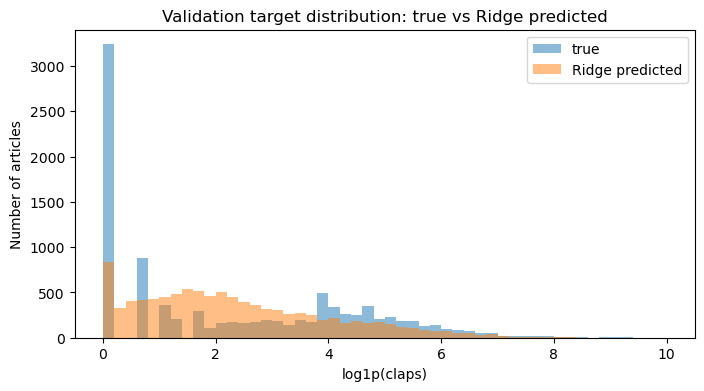

CPU times: user 4min 40s, sys: 3.43 s, total: 4min 43s
Wall time: 4min 45s


In [49]:
%%time

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

ridge_results = []

best_ridge_valid_mae = np.inf
best_ridge_alpha = None
best_ridge_use_clipping = None
best_ridge_valid_pred = None
best_ridge_model = None

alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

for alpha in alphas:
    ridge_model = Ridge(
        alpha=alpha,
        solver="lsqr", # I chose solver="lsqr" because my Ridge model is trained on a large high-dimensional sparse matrix, mainly from TF-IDF and categorical vectorization. "lsqr" is an iterative solver designed for large linear least-squares problems. It works well when the feature matrix is sparse and has many columns, which is exactly the case in our notebook.
        tol=1e-4,
        max_iter=5000,
    )

    ridge_model.fit(X_train_sparse, y_train)

    valid_pred_raw = ridge_model.predict(X_valid_sparse)
    valid_pred_clipped = np.clip(valid_pred_raw, 0, None)

    for use_clipping, valid_pred in [
        (False, valid_pred_raw),
        (True, valid_pred_clipped),
    ]:
        valid_mae = mean_absolute_error(y_valid, valid_pred)

        ridge_results.append({
            "alpha": alpha,
            "use_clipping": use_clipping,
            "valid_mae": valid_mae,
            "prediction_min": valid_pred.min(),
            "prediction_max": valid_pred.max(),
            "prediction_mean": valid_pred.mean(),
        })

        if valid_mae < best_ridge_valid_mae:
            best_ridge_valid_mae = valid_mae
            best_ridge_alpha = alpha
            best_ridge_use_clipping = use_clipping
            best_ridge_valid_pred = valid_pred
            best_ridge_model = ridge_model


ridge_results = pd.DataFrame(ridge_results).sort_values("valid_mae")

display(ridge_results)

print(f"Best Ridge alpha:        {best_ridge_alpha}")
print(f"Use clipping:            {best_ridge_use_clipping}")
print(f"Best Ridge valid MAE:    {best_ridge_valid_mae:.5f}")

print("\nBest validation prediction summary:")
print(f"Min:   {best_ridge_valid_pred.min():.5f}")
print(f"Max:   {best_ridge_valid_pred.max():.5f}")
print(f"Mean:  {best_ridge_valid_pred.mean():.5f}")

plt.figure(figsize=(8, 4))
plt.hist(y_valid, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(best_ridge_valid_pred, bins=50, alpha=0.5, label="Ridge predicted", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Validation target distribution: true vs Ridge predicted")
plt.legend()
plt.show()

The Ridge baseline was tuned successfully on the validation set.

The best configuration was:

- `alpha = 10.0`
- clipping enabled
- validation MAE: **1.15881**

Clipping negative predictions helped because the target is `log1p(claps)`, which cannot be negative. Without clipping, the best comparable Ridge model with `alpha = 10.0` had validation MAE **1.18084**, while clipping improved it to **1.15881**.

The best validation prediction summary was:

- Minimum prediction: **0.00000**
- Maximum prediction: **9.10059**
- Mean prediction: **2.32958**

The prediction mean is close to the validation target mean from the chronological split, which was about **2.30318**. This suggests that the Ridge model is reasonably calibrated on average.

The histogram shows a typical regression pattern: the Ridge predictions are smoother than the true target distribution. The model captures the general range of `log1p(claps)`, but it does not fully reproduce the sharp spike at zero or the long tail of very popular articles. This is expected because Ridge regression tends to shrink extreme predictions toward the center.

Overall, Ridge is a strong first baseline for this high-dimensional sparse feature space. The next step is to evaluate this selected Ridge configuration on the held-out test set. Since the validation set has already been used for model selection, Ridge is retrained on the combined training + validation data, then evaluated once on the untouched test set.

## Validation-based mean calibration for Ridge

The Ridge validation results show whether the model is well calibrated on average.

Because the target is `log1p(claps)`, predictions should be nonnegative, and the prediction mean should ideally be close to the validation target mean. A simple calibration check is to compare:

$$
\operatorname{mean}(y_{valid})
$$

with:

$$
\operatorname{mean}(\hat{y}_{valid})
$$

If the model consistently overpredicts or underpredicts the validation set, we can test a constant mean shift:

$$
\text{shift} = \operatorname{mean}(y_{valid}) - \operatorname{mean}(\hat{y}_{valid})
$$

This is a simple validation-based calibration step. The shift is estimated only from the validation set, and it is kept only if it improves validation MAE.

>Calibration is useful because a model can capture relative patterns while still being systematically biased upward or downward on a later validation period. Since this project uses a chronological split, the validation articles may have a different average engagement level from the training articles. The mean-shift formula above estimates this average validation bias. If the prediction mean is lower than the validation target mean, the shift is positive and raises all predictions. If the prediction mean is higher, the shift is negative and lowers all predictions. I keep the shift only if it improves validation MAE, so this step is treated as a validation-selected calibration adjustment rather than an automatic correction.

In [50]:
# Validation-based mean calibration for Ridge

ridge_valid_shift = y_valid.mean() - best_ridge_valid_pred.mean()

ridge_valid_pred_shifted = np.clip(
    best_ridge_valid_pred + ridge_valid_shift,
    0,
    None,
) # it means clip the result of `best_ridge_valid_pred + ridge_valid_shift` so no prediction is below 0.

ridge_valid_mae_shifted = mean_absolute_error(
    y_valid,
    ridge_valid_pred_shifted,
)

use_ridge_mean_shift = ridge_valid_mae_shifted < best_ridge_valid_mae

print(f"Validation target mean:       {y_valid.mean():.5f}")
print(f"Ridge prediction mean:        {best_ridge_valid_pred.mean():.5f}")
print(f"Validation mean shift:        {ridge_valid_shift:.5f}")
print()
print(f"Ridge valid MAE before shift: {best_ridge_valid_mae:.5f}")
print(f"Ridge valid MAE after shift:  {ridge_valid_mae_shifted:.5f}")
print(f"Use validation mean shift:    {use_ridge_mean_shift}")

Validation target mean:       2.30318
Ridge prediction mean:        2.32958
Validation mean shift:        -0.02640

Ridge valid MAE before shift: 1.15881
Ridge valid MAE after shift:  1.15528
Use validation mean shift:    True


The validation-based mean calibration slightly improved the Ridge validation score.

The validation target mean was:

$$
2.30318
$$

while the Ridge prediction mean was:

$$
2.32958
$$

So the Ridge model was slightly overpredicting the validation set on average. The estimated calibration shift was therefore negative:

$$
\text{shift} = 2.30318 - 2.32958 = -0.02640
$$

After applying this small downward shift and clipping predictions at zero, the validation MAE improved:

- Ridge validation MAE before shift: **1.15881**
- Ridge validation MAE after shift: **1.15528**

Since the shifted validation score is better, this mean-shift calibration is kept for the final Ridge test evaluation.

This calibration is validation-based: the shift is estimated only from the validation set, not from the held-out test set. **The test set is not used for calibration or model selection.**


## Original-target Ridge benchmark on the held-out test set

After selecting the best original-target Ridge configuration and testing the validation-based mean shift, the Ridge baseline is evaluated on the held-out test target as a benchmark.  

Here, “original target” means the standard `log1p(claps)` target used throughout the main workflow, before applying the clipped-target experiment introduced later. It does not refer to raw clap counts.

To make this benchmark stronger, Ridge is retrained on the combined training and validation data:

- training split
- validation split

Because the feature builders learn vocabularies, category mappings, imputation values, and scaling parameters, the sparse feature builders are refitted on the combined training + validation data. The held-out test set is then transformed using those fitted objects.

The validation-selected mean shift is applied because it improved validation MAE. The test result reported here is a benchmark for this original-target Ridge model family; it is not used to choose hyperparameters, calibration settings, LightGBM parameters, or blend weights.


<details>
<summary><span style="color:red">  

Why do we refit the selected Ridge model on the combined training and validation sets before evaluating it on the held-out test set, instead of evaluating the version trained only on the training set?
</span></summary>  

We refit the selected Ridge model on **train + validation** because, after we have already used the validation set to choose the best Ridge configuration, the validation set no longer needs to stay separate for that specific Ridge benchmark.

At that point, we know the selected setup:

```text
best alpha
whether to clip negative predictions
whether to apply the validation-selected mean shift
```

So before evaluating on the held-out test set, we can train the selected Ridge model on more data:

```text
train only        → used for model selection
train + valid     → used for stronger final benchmark training
test              → used only for evaluation
```

This helps because more training data usually gives the model:

* a larger TF-IDF vocabulary learned from past/available data
* better IDF estimates
* more observed author/publication categories
* better imputation and scaling estimates
* more examples for learning coefficients

The important rule is that we **still do not use the test set** to fit anything.

That is why this part is okay:

```text
fit builders on train + valid
transform test
evaluate on test
```

But this would not be okay:

```text
fit builders on train + valid + test
```

because that would leak information from the held-out test period.

So:  

After selecting the Ridge configuration using the validation set, I refit the selected model on the combined training and validation data before evaluating on the held-out test set. This gives the final Ridge benchmark access to all non-test examples, which can improve vocabulary coverage, category coverage, imputation/scaling estimates, and coefficient estimation.

The test set is still kept completely separate: it is only transformed using objects fitted on the combined training + validation data and is used only for benchmark evaluation. This follows a common workflow: use validation data for model selection, then retrain the selected configuration on all available non-test data before final testing.

</details>

Target column:            log_claps
Train + validation rows:  56,174
Test rows:                9,914

Selected Ridge alpha:     10.0
Use clipping:             True
Use mean shift:           True
Validation mean shift:    -0.02640

Final Ridge feature matrices:
X_train_valid_sparse shape: (56174, 243520)
X_test_sparse_final shape:  (9914, 243520)
y_train_valid shape:        (56174,)
y_test shape:               (9914,)

Held-out test results:
Ridge test MAE before shift: 1.17766
Ridge test MAE after shift:  1.17107

Test target mean:            2.08826
Ridge prediction mean:       2.30955
Shifted prediction mean:     2.28507

Ridge prediction min:        0.00000
Ridge prediction max:        8.47266
Shifted prediction min:      0.00000
Shifted prediction max:      8.44626


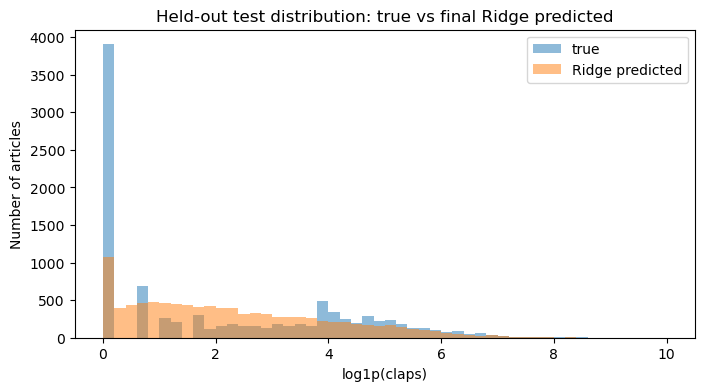

CPU times: user 2min 55s, sys: 5.13 s, total: 3min
Wall time: 3min 2s


In [51]:
%%time

# Final Ridge evaluation on the held-out test set

train_valid_df = (
    pd.concat([train_df, valid_df], axis=0)
    .sort_values("sort_time")
    .reset_index(drop=True)
)

y_train_valid = train_valid_df[TARGET_COL].values

print(f"Target column:            {TARGET_COL}")
print(f"Train + validation rows:  {len(train_valid_df):,}")
print(f"Test rows:                {len(test_df):,}")
print()
print(f"Selected Ridge alpha:     {best_ridge_alpha}")
print(f"Use clipping:             {best_ridge_use_clipping}")
print(f"Use mean shift:           {use_ridge_mean_shift}")
print(f"Validation mean shift:    {ridge_valid_shift:.5f}")


# Refit all feature builders on train + validation only.
ridge_final_builders = fit_sparse_feature_builders(
    train_frame=train_valid_df,
    numeric_cols=numeric_feature_cols,
)

X_train_valid_sparse = transform_sparse_features(
    train_valid_df,
    ridge_final_builders,
)

X_test_sparse_final = transform_sparse_features(
    test_df,
    ridge_final_builders,
)

print("\nFinal Ridge feature matrices:")
print(f"X_train_valid_sparse shape: {X_train_valid_sparse.shape}")
print(f"X_test_sparse_final shape:  {X_test_sparse_final.shape}")
print(f"y_train_valid shape:        {y_train_valid.shape}")
print(f"y_test shape:               {y_test.shape}")


# Train final Ridge model
final_ridge_model = Ridge(
    alpha=best_ridge_alpha,
    solver="lsqr",
    tol=1e-4,
    max_iter=5000,
)

final_ridge_model.fit(X_train_valid_sparse, y_train_valid)

ridge_test_pred_raw = final_ridge_model.predict(X_test_sparse_final)

if best_ridge_use_clipping:
    ridge_test_pred = np.clip(ridge_test_pred_raw, 0, None)
else:
    ridge_test_pred = ridge_test_pred_raw


# Apply validation-selected mean shift only if it improved validation MAE.
if use_ridge_mean_shift:
    ridge_test_pred_shifted = np.clip(
        ridge_test_pred + ridge_valid_shift,
        0,
        None,
    )
else:
    ridge_test_pred_shifted = ridge_test_pred.copy()


ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_test_mae_shifted = mean_absolute_error(y_test, ridge_test_pred_shifted)

# Keep final Ridge prediction variables for later comparison/blending.
ridge_test_pred_final = ridge_test_pred_shifted.copy()
ridge_test_mae_final = ridge_test_mae_shifted

print("\nHeld-out test results:")
print(f"Ridge test MAE before shift: {ridge_test_mae:.5f}")
print(f"Ridge test MAE after shift:  {ridge_test_mae_shifted:.5f}")
print()
print(f"Test target mean:            {y_test.mean():.5f}")
print(f"Ridge prediction mean:       {ridge_test_pred.mean():.5f}")
print(f"Shifted prediction mean:     {ridge_test_pred_shifted.mean():.5f}")
print()
print(f"Ridge prediction min:        {ridge_test_pred.min():.5f}")
print(f"Ridge prediction max:        {ridge_test_pred.max():.5f}")
print(f"Shifted prediction min:      {ridge_test_pred_shifted.min():.5f}")
print(f"Shifted prediction max:      {ridge_test_pred_shifted.max():.5f}")


plt.figure(figsize=(8, 4))
plt.hist(y_test, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(ridge_test_pred_final, bins=50, alpha=0.5, label="Ridge predicted", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Held-out test distribution: true vs final Ridge predicted")
plt.legend()
plt.show()

The original-target Ridge benchmark was evaluated successfully on the held-out test set.

The selected validation configuration was:

- Ridge `alpha`: **10.0**
- clipping enabled: **True**
- validation-based mean shift enabled: **True**
- validation mean shift: **-0.02640**

After selecting this configuration, Ridge was retrained on the combined training + validation set:

- Train + validation rows: **56,174**
- Test rows: **9,914**

The final Ridge feature matrices were:

- `X_train_valid_sparse`: `(56174, 243520)`
- `X_test_sparse_final`: `(9914, 243520)`

The held-out test performance was:

- Ridge test MAE before shift: **1.17766**
- Ridge test MAE after shift: **1.17107**

The validation-selected mean shift also helped on the test set.

The prediction mean is still higher than the true test target mean:

- True test target mean: **2.08826**
- Ridge prediction mean before shift: **2.30955**
- Ridge prediction mean after shift: **2.28507**

This shows that the model still overpredicts the latest articles on average, probably because the chronological split has temporal drift: the train and validation periods have higher average `log_claps` than the test period.

The histogram also shows the usual popularity-prediction pattern. Ridge produces a smoother prediction distribution than the true test distribution. It does not fully reproduce the large spike at zero claps, and it shrinks extreme popularity values toward the center.

This is a strong original-target Ridge benchmark for the high-dimensional sparse feature space. The next experiment tests whether training on the clipped target, `log_claps_clipped`, improves performance by reducing the influence of rare viral outliers.


## Testing a clipped-target Ridge experiment

The main Ridge baseline was trained on the original target:

```python
TARGET_COL = "log_claps"
```

The clipped-target experiment trains Ridge on:

```python
log_claps_clipped
```

This target clips the most extreme `log_claps` values at the 99.5th percentile. To avoid target-distribution leakage, the clipping threshold is computed from the **training split only** after the chronological split. Validation and test targets are not used to choose the clipping threshold.

The idea is to reduce the influence of rare viral outliers that may be difficult for a linear model to predict accurately.

In this experiment, Ridge is trained on `log_claps_clipped`, but predictions are still evaluated against the original `log_claps` target. This keeps the comparison fair because the real modeling goal is still to predict the original log-transformed clap count.

The experiment follows the same structure as the main Ridge baseline:

1. Train Ridge models on the training split using the clipped target.
2. Tune `alpha` on the validation split.
3. Compare validation MAE against the original `log_claps` target.
4. Test whether a validation-based mean shift helps.
5. Retrain the best clipped-target Ridge model on train + validation.
6. Report its held-out test performance as a benchmark.

This tells us whether clipping rare viral articles improves the Ridge model family.


Original target column: log_claps
Clipped target column:  log_claps_clipped
Clipped target upper value from training split only: 8.59287


,alpha,postprocess,valid_mae_original_target,valid_mae_clipped_target,prediction_min,prediction_max,prediction_mean
17,10.0,lower_upper_clip,1.154359,1.153270,0.000000,8.592874,2.309095
16,10.0,lower_clip,1.154418,1.153329,0.000000,9.070740,2.309154
14,5.0,lower_upper_clip,1.154861,1.153772,0.000000,8.592874,2.327783
13,5.0,lower_clip,1.154946,1.153857,0.000000,9.115723,2.327867
20,20.0,lower_upper_clip,1.164018,1.162929,0.000000,8.592874,2.286629
19,20.0,lower_clip,1.164058,1.162969,0.000000,8.987801,2.286669
11,2.0,lower_upper_clip,1.170471,1.169382,0.000000,8.592874,2.357715
10,2.0,lower_clip,1.170594,1.169505,0.000000,9.151001,2.357838
15,10.0,raw,1.177375,1.176286,-1.746765,9.070740,2.286197
12,5.0,raw,1.181510,1.180421,-1.984619,9.115723,2.301303


Best clipped-target Ridge validation result:
Best alpha:              10.0
Best postprocess mode:   lower_upper_clip
Best validation MAE:     1.15436
Main Ridge valid MAE:    1.15881

Validation-based calibration:
Validation target mean:                2.30318
Clipped Ridge prediction mean:         2.30910
Clipped Ridge validation mean shift:   -0.00592
MAE before shift:                      1.15436
MAE after shift:                       1.15361
Use clipped Ridge mean shift:          True

Held-out test comparison:
Main Ridge final test MAE:                 1.17107
Clipped-target Ridge test MAE before shift: 1.10829
Clipped-target Ridge test MAE after shift: 1.10715

True test target mean:                     2.08826
Main Ridge prediction mean:                2.28507
Clipped Ridge prediction mean:             2.17590


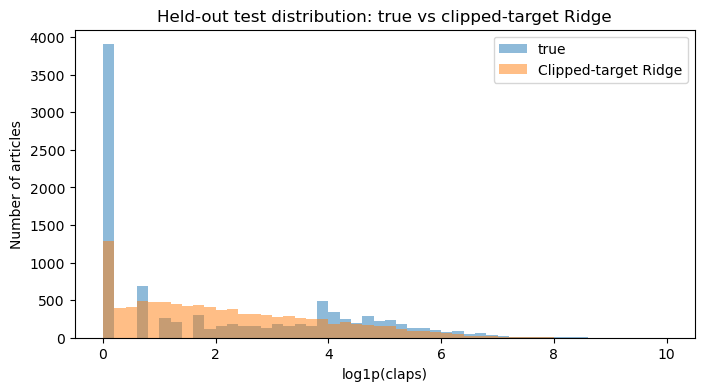

CPU times: user 5min 25s, sys: 4.64 s, total: 5min 29s
Wall time: 5min 33s
Parser   : 532 ms


In [52]:
%%time

# Clipped-target Ridge experiment

CLIPPED_TARGET_COL = "log_claps_clipped"

if CLIPPED_TARGET_COL not in train_df.columns:
    raise ValueError(f"Missing clipped target column: {CLIPPED_TARGET_COL}")

y_train_clipped = train_df[CLIPPED_TARGET_COL].values
y_valid_clipped = valid_df[CLIPPED_TARGET_COL].values
y_test_clipped = test_df[CLIPPED_TARGET_COL].values

clipped_target_upper = train_df[CLIPPED_TARGET_COL].max()

print(f"Original target column: {TARGET_COL}")
print(f"Clipped target column:  {CLIPPED_TARGET_COL}")
print(f"Clipped target upper value from training split only: {clipped_target_upper:.5f}")


def postprocess_clipped_ridge_predictions(predictions, mode, upper_value):
    """
    Apply prediction post-processing for the clipped-target Ridge experiment.
    """
    predictions = predictions.copy()

    if mode == "raw":
        return predictions

    if mode == "lower_clip":
        return np.clip(predictions, 0, None)

    if mode == "lower_upper_clip":
        return np.clip(predictions, 0, upper_value)

    raise ValueError(f"Unknown post-processing mode: {mode}")


clipped_ridge_results = []

best_clipped_ridge_valid_mae = np.inf
best_clipped_ridge_alpha = None
best_clipped_ridge_postprocess = None
best_clipped_ridge_valid_pred = None
best_clipped_ridge_model = None

alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
postprocess_modes = ["raw", "lower_clip", "lower_upper_clip"]

for alpha in alphas:
    clipped_ridge_model = Ridge(
        alpha=alpha,
        solver="lsqr",
        tol=1e-4,
        max_iter=5000,
    )

    clipped_ridge_model.fit(X_train_sparse, y_train_clipped)

    valid_pred_raw = clipped_ridge_model.predict(X_valid_sparse)

    for postprocess_mode in postprocess_modes:
        valid_pred = postprocess_clipped_ridge_predictions(
            predictions=valid_pred_raw,
            mode=postprocess_mode,
            upper_value=clipped_target_upper,
        )

        valid_mae_original_target = mean_absolute_error(y_valid, valid_pred)
        valid_mae_clipped_target = mean_absolute_error(y_valid_clipped, valid_pred)

        clipped_ridge_results.append({
            "alpha": alpha,
            "postprocess": postprocess_mode,
            "valid_mae_original_target": valid_mae_original_target,
            "valid_mae_clipped_target": valid_mae_clipped_target,
            "prediction_min": valid_pred.min(),
            "prediction_max": valid_pred.max(),
            "prediction_mean": valid_pred.mean(),
        })

        # Select using original log_claps validation MAE for fair comparison.
        if valid_mae_original_target < best_clipped_ridge_valid_mae:
            best_clipped_ridge_valid_mae = valid_mae_original_target
            best_clipped_ridge_alpha = alpha
            best_clipped_ridge_postprocess = postprocess_mode
            best_clipped_ridge_valid_pred = valid_pred
            best_clipped_ridge_model = clipped_ridge_model


clipped_ridge_results = (
    pd.DataFrame(clipped_ridge_results)
    .sort_values("valid_mae_original_target")
)

display(clipped_ridge_results)

print("Best clipped-target Ridge validation result:")
print(f"Best alpha:              {best_clipped_ridge_alpha}")
print(f"Best postprocess mode:   {best_clipped_ridge_postprocess}")
print(f"Best validation MAE:     {best_clipped_ridge_valid_mae:.5f}")
print(f"Main Ridge valid MAE:    {best_ridge_valid_mae:.5f}")


# Validation-based mean calibration for clipped-target Ridge
clipped_ridge_valid_shift = y_valid.mean() - best_clipped_ridge_valid_pred.mean()

clipped_ridge_valid_pred_shifted = np.clip(
    best_clipped_ridge_valid_pred + clipped_ridge_valid_shift,
    0,
    None,
)

clipped_ridge_valid_mae_shifted = mean_absolute_error(
    y_valid,
    clipped_ridge_valid_pred_shifted,
)

use_clipped_ridge_mean_shift = (
    clipped_ridge_valid_mae_shifted < best_clipped_ridge_valid_mae
)

print("\nValidation-based calibration:")
print(f"Validation target mean:                {y_valid.mean():.5f}")
print(f"Clipped Ridge prediction mean:         {best_clipped_ridge_valid_pred.mean():.5f}")
print(f"Clipped Ridge validation mean shift:   {clipped_ridge_valid_shift:.5f}")
print(f"MAE before shift:                      {best_clipped_ridge_valid_mae:.5f}")
print(f"MAE after shift:                       {clipped_ridge_valid_mae_shifted:.5f}")
print(f"Use clipped Ridge mean shift:          {use_clipped_ridge_mean_shift}")


# Final clipped-target Ridge test evaluation
y_train_valid_clipped = train_valid_df[CLIPPED_TARGET_COL].values

final_clipped_ridge_model = Ridge(
    alpha=best_clipped_ridge_alpha,
    solver="lsqr",
    tol=1e-4,
    max_iter=5000,
)

final_clipped_ridge_model.fit(
    X_train_valid_sparse,
    y_train_valid_clipped,
)

clipped_ridge_test_pred_raw = final_clipped_ridge_model.predict(
    X_test_sparse_final,
)

clipped_ridge_test_pred = postprocess_clipped_ridge_predictions(
    predictions=clipped_ridge_test_pred_raw,
    mode=best_clipped_ridge_postprocess,
    upper_value=clipped_target_upper,
)

if use_clipped_ridge_mean_shift:
    clipped_ridge_test_pred_shifted = np.clip(
        clipped_ridge_test_pred + clipped_ridge_valid_shift,
        0,
        None,
    )
else:
    clipped_ridge_test_pred_shifted = clipped_ridge_test_pred.copy()


clipped_ridge_test_mae = mean_absolute_error(
    y_test,
    clipped_ridge_test_pred,
)

clipped_ridge_test_mae_shifted = mean_absolute_error(
    y_test,
    clipped_ridge_test_pred_shifted,
)

print("\nHeld-out test comparison:")
print(f"Main Ridge final test MAE:                 {ridge_test_mae_final:.5f}")
print(f"Clipped-target Ridge test MAE before shift: {clipped_ridge_test_mae:.5f}")
print(f"Clipped-target Ridge test MAE after shift: {clipped_ridge_test_mae_shifted:.5f}")
print()
print(f"True test target mean:                     {y_test.mean():.5f}")
print(f"Main Ridge prediction mean:                {ridge_test_pred_final.mean():.5f}")
print(f"Clipped Ridge prediction mean:             {clipped_ridge_test_pred_shifted.mean():.5f}")


plt.figure(figsize=(8, 4))
plt.hist(y_test, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(clipped_ridge_test_pred_shifted, bins=50, alpha=0.5, label="Clipped-target Ridge", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Held-out test distribution: true vs clipped-target Ridge")
plt.legend()
plt.show()


The clipped-target Ridge experiment improved the Ridge baseline.

In this experiment, Ridge was trained on `log_claps_clipped`, where the most extreme `log_claps` values are capped using a training-split-fitted 99.5th percentile threshold. In this executed run, the clipped target upper value printed as:

$$
8.59287
$$

The best clipped-target Ridge validation configuration was:

- `alpha = 10.0`
- post-processing: `lower_upper_clip` (It means predictions are clipped to the valid target range `[0, 8.59287]` after prediction)
- validation MAE against original `log_claps` before mean shift: **1.15436** 

>In the clipped-target Ridge experiment, I train Ridge on `log_claps_clipped`, where extreme training targets are capped at the training-split 99.5th percentile. The model’s predictions are still evaluated against the original `log_claps` target, so the experiment tests whether reducing the influence of extreme viral articles during training improves generalization.
>
>The selected post-processing option, `lower_upper_clip`, clips predictions to the range `[0, 8.59287]`, where `0` is the minimum possible value of `log1p(claps)` and `8.59287` is the clipped-target upper bound learned from the training split.

This is better than the original-target Ridge validation score before mean shift:

- Original-target Ridge validation MAE before mean shift: **1.15881**
- Original-target Ridge validation MAE after mean shift: **1.15528**
- Clipped-target Ridge validation MAE before mean shift: **1.15436**

The validation-based mean shift also helped the clipped-target model slightly:

- Clipped Ridge prediction mean: **2.30910**
- Validation target mean: **2.30318**
- Mean shift: **-0.00592**
- MAE before shift: **1.15436**
- MAE after shift: **1.15361**

Because the shifted validation score was better, the shifted clipped-target Ridge prediction is used as the selected Ridge baseline.

The held-out test benchmark also improved over the original-target Ridge model:

- Main Ridge final test MAE: **1.17107**
- Clipped-target Ridge test MAE before shift: **1.10829**
- Clipped-target Ridge test MAE after shift: **1.10715**

The clipped-target model also reduced the prediction-mean gap on the test set:

- True test target mean: **2.08826**
- Main Ridge prediction mean: **2.28507**
- Clipped Ridge prediction mean after shift: **2.17590**

This suggests that the original-target Ridge model was too influenced by rare high-clap articles and overpredicted the later test period. Training on the clipped target made the Ridge predictions more robust and better calibrated for the held-out test split.

For the next step, the Ridge experiments are summarized and the shifted clipped-target Ridge model is selected as the current best Ridge baseline based on validation MAE.


## Comparing Ridge experiments and selecting the current best baseline

This section compares the two Ridge baselines:

1. Ridge trained on the original `log_claps` target
2. Ridge trained on the clipped `log_claps_clipped` target

The model should be selected based on validation performance, not test performance. In this case, the clipped-target Ridge model has the better validation MAE, and the held-out test result also confirms that it generalizes better.

This step creates a compact comparison table and stores the selected Ridge predictions in clear final variables. These final variables are used later for comparison with LightGBM and for blending experiments.


In [53]:
# Compare Ridge experiments and select the current best Ridge baseline

ridge_original_valid_pred_for_selection = (
    ridge_valid_pred_shifted.copy()
    if use_ridge_mean_shift
    else best_ridge_valid_pred.copy()
)

ridge_original_valid_mae_for_selection = (
    ridge_valid_mae_shifted
    if use_ridge_mean_shift
    else best_ridge_valid_mae
)

clipped_ridge_valid_pred_for_selection = (
    clipped_ridge_valid_pred_shifted.copy()
    if use_clipped_ridge_mean_shift
    else best_clipped_ridge_valid_pred.copy()
)

clipped_ridge_valid_mae_for_selection = (
    clipped_ridge_valid_mae_shifted
    if use_clipped_ridge_mean_shift
    else best_clipped_ridge_valid_mae
)

ridge_experiment_results = pd.DataFrame([
    {
        "model": "Ridge_original_target",
        "training_target": "log_claps",
        "best_alpha": best_ridge_alpha,
        "postprocess": "lower_clip" if best_ridge_use_clipping else "raw",
        "use_mean_shift": use_ridge_mean_shift,
        "valid_mae": ridge_original_valid_mae_for_selection,
        "test_mae": ridge_test_mae_final,
        "test_prediction_mean": ridge_test_pred_final.mean(),
    },
    {
        "model": "Ridge_clipped_target",
        "training_target": "log_claps_clipped",
        "best_alpha": best_clipped_ridge_alpha,
        "postprocess": best_clipped_ridge_postprocess,
        "use_mean_shift": use_clipped_ridge_mean_shift,
        "valid_mae": clipped_ridge_valid_mae_for_selection,
        "test_mae": clipped_ridge_test_mae_shifted,
        "test_prediction_mean": clipped_ridge_test_pred_shifted.mean(),
    },
]).sort_values("valid_mae")

display(ridge_experiment_results)

best_ridge_experiment = ridge_experiment_results.iloc[0]

print("Selected Ridge baseline:")
print(f"Model:              {best_ridge_experiment['model']}")
print(f"Training target:    {best_ridge_experiment['training_target']}")
print(f"Validation MAE:     {best_ridge_experiment['valid_mae']:.5f}")
print(f"Held-out test MAE:  {best_ridge_experiment['test_mae']:.5f}")

if best_ridge_experiment["model"] == "Ridge_clipped_target":
    selected_ridge_model_name = "Ridge_clipped_target"
    selected_ridge_valid_pred = clipped_ridge_valid_pred_for_selection.copy()
    selected_ridge_test_pred = clipped_ridge_test_pred_shifted.copy()
    selected_ridge_valid_mae = clipped_ridge_valid_mae_for_selection
    selected_ridge_test_mae = clipped_ridge_test_mae_shifted
else:
    selected_ridge_model_name = "Ridge_original_target"
    selected_ridge_valid_pred = ridge_original_valid_pred_for_selection.copy()
    selected_ridge_test_pred = ridge_test_pred_final.copy()
    selected_ridge_valid_mae = ridge_original_valid_mae_for_selection
    selected_ridge_test_mae = ridge_test_mae_final

print("\nStored selected Ridge variables:")
print(f"selected_ridge_model_name: {selected_ridge_model_name}")
print(f"selected_ridge_valid_mae:  {selected_ridge_valid_mae:.5f}")
print(f"selected_ridge_test_mae:   {selected_ridge_test_mae:.5f}")
print(f"Validation prediction shape: {selected_ridge_valid_pred.shape}")
print(f"Test prediction shape:       {selected_ridge_test_pred.shape}")


,model,training_target,best_alpha,postprocess,use_mean_shift,valid_mae,test_mae,test_prediction_mean
1,Ridge_clipped_target,log_claps_clipped,10.0,lower_upper_clip,True,1.153614,1.107153,2.175902
0,Ridge_original_target,log_claps,10.0,lower_clip,True,1.155284,1.171069,2.285066


Selected Ridge baseline:
Model:              Ridge_clipped_target
Training target:    log_claps_clipped
Validation MAE:     1.15361
Held-out test MAE:  1.10715

Stored selected Ridge variables:
selected_ridge_model_name: Ridge_clipped_target
selected_ridge_valid_mae:  1.15361
selected_ridge_test_mae:   1.10715
Validation prediction shape: (9913,)
Test prediction shape:       (9914,)


The Ridge experiment comparison selects the shifted clipped-target Ridge model as the current best baseline.


**The selected model is the clipped-target Ridge model with validation-selected mean-shift calibration.**

Two Ridge variants were compared:

1. Ridge trained on the original `log_claps` target
2. Ridge trained on the clipped `log_claps_clipped` target

The model is selected based on validation performance, not test performance. The clipped-target Ridge model has the better validation MAE, and the held-out test benchmark also shows better generalization.

| Model | Training target | Validation MAE | Test MAE | Test prediction mean |
|---|---|---:|---:|---:|
| Ridge clipped target | `log_claps_clipped` | **1.15361** | **1.10715** | **2.17590** |
| Ridge original target | `log_claps` | 1.15528 | 1.17107 | 2.28507 |

The selected Ridge baseline is therefore:

- Model: `Ridge_clipped_target`
- Training target: `log_claps_clipped`
- Best alpha: **10.0**
- Post-processing: `lower_upper_clip`
- Validation mean shift: **-0.00592**
- Validation MAE: **1.15361**
- Held-out test MAE: **1.10715**

The clipped-target model also produces a test prediction mean closer to the true test target mean. This suggests that clipping rare viral outliers made Ridge less biased toward high-clap articles and improved generalization to later articles.

The selected Ridge predictions are stored in:

- `selected_ridge_valid_pred`
- `selected_ridge_test_pred`

These are used as the Ridge benchmark for model comparison and blending.


## Training a LightGBM validation model

This section tests whether a tree-based model can add useful signal beyond Ridge.

Ridge is very strong for high-dimensional sparse TF-IDF features, but it is still a linear model, so it mostly learns additive linear relationships. LightGBM is different: it can learn nonlinear patterns and feature interactions. It may capture relationships between article length, metadata, author/publication information, time features, and compressed representations of the sparse text features.  

For example, LightGBM can learn patterns like:

```text
If author follower count is high
AND article body is long
AND publication is known
AND publication time is recent
THEN predicted engagement may be higher
```

A linear Ridge model does not naturally capture that kind of “if this and this together” relationship as easily.  

Instead of feeding the original high-dimensional sparse TF-IDF matrix directly into LightGBM, I use `TruncatedSVD` to compress the sparse matrix into a smaller set of dense components. This is useful because the original sparse matrix can contain hundreds of thousands of columns, which would make tree-based training slower, more memory-intensive, and harder to interpret. The SVD components provide a compact summary of the main patterns in the sparse text and categorical features.

In other words, Ridge uses the full sparse representation directly, while LightGBM receives a lower-dimensional SVD-compressed version of that representation along with engineered numeric, frequency, and target-encoding features. This gives LightGBM access to information from the text/categorical feature space without forcing it to split over the entire original sparse matrix.  

>LightGBM is tree-based, so it usually works better with a compact dense feature table than with an extremely large sparse TF-IDF matrix.

LightGBM is not trained directly on the full sparse matrix with more than 200,000 columns. Instead, we create a compact LightGBM feature matrix using:

1. engineered numeric features
2. author and publication frequency features
3. smoothed author/publication target encodings
4. SVD-compressed components from the sparse Ridge feature matrix

The workflow remains leakage-free:

- numeric imputers are fitted only on the training split
- frequency maps are learned only from the training split
- target encodings are learned only from the training split
- SVD is fitted only on `X_train_sparse`
- LightGBM is trained only on the training split
- validation predictions are evaluated against the original `log_claps` target

Since the selected Ridge baseline was trained on `log_claps_clipped`, LightGBM is also trained on `log_claps_clipped`. However, validation MAE is reported against the original `log_claps` target so it can be compared fairly with the selected Ridge baseline.

>LightGBM is a gradient boosted decision tree algorithm. Instead of fitting one large tree, it builds many trees sequentially, where each new tree focuses on correcting the errors of the previous trees.
>
>I use LightGBM because it can capture nonlinear relationships and interactions among engineered features, target encodings, frequency encodings, and SVD-compressed sparse features. This makes it a useful complement to Ridge regression, which is strong for high-dimensional sparse TF-IDF features but mostly linear.


<details>
<summary><span style="color:red">
Gradient boosted decision trees:
</span></summary>   

**Gradient boosted decision trees** means:

> A model made of many decision trees, where each new tree is trained to fix the errors made by the trees before it.

Break it into three parts.

## 1. Decision tree

A **decision tree** makes predictions by asking a sequence of yes/no questions.

For example, for our Medium project, a simple tree might ask:

```text
Is author follower count > 10,000?
├── Yes: Is body word count > 1,500?
│   ├── Yes: predict higher log_claps
│   └── No: predict medium log_claps
└── No: Is publication known?
    ├── Yes: predict medium log_claps
    └── No: predict lower log_claps
```

A single tree is easy to understand, but it can be unstable or too simple.

## 2. Boosted trees

**Boosting** means building trees one after another.

Instead of training one tree independently, the model does this:

```text
Tree 1: makes an initial prediction
Tree 2: focuses on the mistakes from Tree 1
Tree 3: focuses on the remaining mistakes from Trees 1 and 2
Tree 4: focuses on the remaining mistakes again
...
Final prediction = combined output of all trees
```

So each tree improves the ensemble step by step.

## 3. Gradient boosting

The word **gradient** means the model uses the direction of the error to decide how the next tree should improve the predictions.

For squared error, this is similar to learning from residuals:

```text
residual = actual value - current prediction
```

For our project:

```text
actual log_claps = 3.0
current prediction = 2.4
residual = +0.6
```

The next tree learns that this article should be pushed upward.

Another example:

```text
actual log_claps = 1.0
current prediction = 1.8
residual = -0.8
```

The next tree learns that this article should be pushed downward.

So:  

LightGBM is a gradient boosted decision tree model. It builds many small decision trees sequentially, where each new tree focuses on correcting the remaining prediction errors from the previous trees. This allows the model to capture nonlinear relationships and feature interactions that a linear model such as Ridge may miss.

In simple words:

> Ridge learns one linear formula. LightGBM learns many small decision rules and combines them.

<details>
<summary><span style="color:red">

In boosting, if each new tree is trained to correct the errors of the previous trees, why isn’t the final prediction just the prediction from the last tree? Why do we combine all trees instead?
</span></summary>  

In boosting, the **last tree is not the final model**.

The last tree only learns the **remaining error correction**, not the full prediction by itself.

Think of boosting like this:

```text
Final prediction = initial prediction
                 + correction from Tree 1
                 + correction from Tree 2
                 + correction from Tree 3
                 + ...
                 + correction from Tree N
```

So the final prediction comes from the **combined contribution of all trees**, not only the last one.

A simplified formula is:

$$
\hat{y}=F_0(x)+\eta f_1(x)+\eta f_2(x)+\cdots+\eta f_M(x)
$$  

Where:

* `F₀(x)` is the initial prediction
* `f₁(x), f₂(x), ..., f_M(x)` are the trees
* `η` is the learning rate
* `M` is the number of trees

The reason the last tree is not enough is that each tree usually learns only a **small adjustment**. For example:

```text
Initial prediction: 2.00
Tree 1 correction: +0.40
Tree 2 correction: -0.10
Tree 3 correction: +0.05

Final prediction = 2.00 + 0.40 - 0.10 + 0.05 = 2.35
```

If you used only the last tree, the prediction would be just `+0.05`, which is not the target prediction. It is only the final small correction.

So: 

Boosting builds trees sequentially, where each new tree learns a correction to the current ensemble’s remaining errors. The final prediction is not made by the last tree alone; it is the sum of the initial prediction plus the corrections from all trees, usually scaled by a learning rate. This allows the model to improve gradually while reducing the risk that any single tree dominates the prediction.

</details>

</details>

Here, **“validation model”** means:

> a model trained on the training split and evaluated on the validation split, mainly for model selection and tuning.

So when we say **“LightGBM validation model”**, we mean the LightGBM model used during the validation stage, not the final model trained for the final test evaluation.

In our workflow:

```text
Train split      → fit the candidate model
Validation split → compare models, choose config, tune blend/calibration
Test split       → final held-out evaluation
```

So a **validation model** is a candidate model used to answer questions like:

* Which LightGBM configuration works best?
* Which Ridge alpha should I choose?
* Should I use mean-shift calibration?
* What Ridge/LightGBM blend weight should I use?

LightGBM training target: log_claps_clipped
LightGBM target upper value from training split: 8.59287

LightGBM validation feature matrices:
X_lgb_train shape: (46261, 223)
X_lgb_valid shape: (9913, 223)
y_train_lgb shape: (46261,)
y_valid shape:     (9913,)
SVD explained variance ratio sum: 0.98963

Training LightGBM config: l1_medium
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 1.13708
[200]	valid_0's l1: 1.12189
[300]	valid_0's l1: 1.12129
Early stopping, best iteration is:
[242]	valid_0's l1: 1.12072

Training LightGBM config: l2_medium
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 1.20621	valid_0's l2: 2.26345
[200]	valid_0's l1: 1.16242	valid_0's l2: 2.21498
[300]	valid_0's l1: 1.15393	valid_0's l2: 2.20734
[400]	valid_0's l1: 1.14911	valid_0's l2: 2.20076
Early stopping, best iteration is:
[394]	valid_0's l1: 1.14928	valid_0's l2: 2.20012

Training LightGBM config: l2_deeper
Training until validation scores 

,config,valid_mae_original_target,best_iteration,prediction_min,prediction_max,prediction_mean
0,l1_medium,1.120900,242,0.0,7.332200,2.391933
1,l2_medium,1.148415,394,0.0,7.638781,2.462415
2,l2_deeper,1.154820,299,0.0,7.728633,2.482180



Best LightGBM validation model:
Config:                        l1_medium
LightGBM validation MAE:        1.12090
Selected Ridge validation MAE:  1.15361
Best LightGBM iteration:        242

Prediction min:                0.00000
Prediction max:                7.33220
Prediction mean:               2.39193
Validation target mean:        2.30318


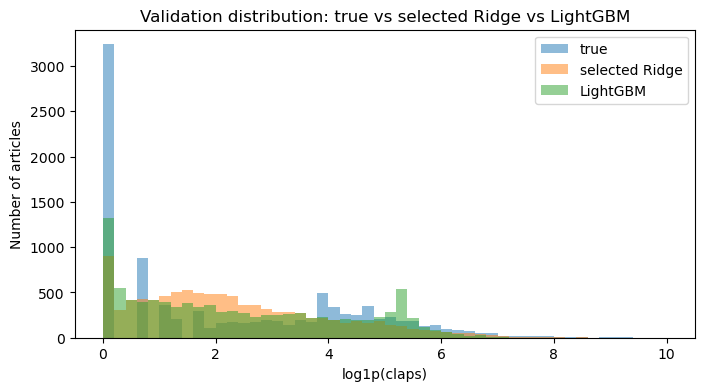

CPU times: user 2min 40s, sys: 1min 30s, total: 4min 11s
Wall time: 1min 39s


In [54]:
%%time

try:
    from lightgbm import LGBMRegressor, early_stopping, log_evaluation
except ImportError as e:
    raise ImportError(
        "LightGBM is not installed. Install it first with: pip install lightgbm"
    ) from e

from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer


# ---------------------------------------------------------------------
# 1. Helper functions for leakage-free frequency and target encoding
# ---------------------------------------------------------------------

def make_frequency_map(values):
    """
    Build a frequency map from the training split only.
    """
    series = (
        pd.Series(values)
        .fillna("")
        .astype(str)
        .str.strip()
    )

    series = series[series != ""]
    return series.value_counts()


def make_smoothed_target_encoding(train_keys, train_targets, apply_keys=None, smoothing=50):
    """
    Smoothed target encoding.

    If apply_keys is None:
        return leave-one-out encodings for the training rows.

    If apply_keys is provided:
        return encodings for new rows using statistics from the supplied
        training frame only. Validation/test encodings are therefore
        leakage-free with respect to their targets. A stricter production
        setup could replace this with rolling chronological encodings.
    """
    train_keys = (
        pd.Series(train_keys)
        .fillna("")
        .astype(str)
        .str.strip()
    )

    train_targets = pd.Series(train_targets).astype(float)
    global_mean = train_targets.mean()

    train_te_df = pd.DataFrame({
        "key": train_keys,
        "target": train_targets,
    }) # This creates a temporary dataframe with one categorical key column and one target column. For example, if I am encoding `author_clean`, then `key` contains the author value for each row and `target` contains that row’s actual `log_claps` value from the training set. The leave-one-out target encoding is calculated later by grouping rows with the same key, subtracting the current row’s own target, and computing a smoothed average from the remaining rows with that same key.

    stats = (
        train_te_df[train_te_df["key"] != ""]
        .groupby("key")["target"]
        .agg(["sum", "count"])
    )

    if apply_keys is None:
        key_sum = train_keys.map(stats["sum"]).fillna(0)
        key_count = train_keys.map(stats["count"]).fillna(0)

        loo_sum = key_sum - train_targets
        loo_count = key_count - 1

        encoded = (
            (loo_sum + global_mean * smoothing)
            / (loo_count + smoothing)
        )

        encoded = encoded.where(
            (train_keys != "") & (key_count > 1),
            global_mean,
        )

        return encoded.astype(np.float32), global_mean

    apply_keys = (
        pd.Series(apply_keys)
        .fillna("")
        .astype(str)
        .str.strip()
    )

    smoothed = (
        (stats["sum"] + global_mean * smoothing)
        / (stats["count"] + smoothing)
    )

    encoded = apply_keys.map(smoothed).fillna(global_mean)
    encoded = encoded.where(apply_keys != "", global_mean)

    return encoded.astype(np.float32), global_mean


# This function builds a small set of extra numeric features for LightGBM using the cleaned author and publication fields.
# It does not train a model. It simply creates a compact feature table that LightGBM can use.
def build_lgbm_extra_features(
    frame, # The dataframe we want to transform, such as training, validation, or test data.
    author_freq_map, # A mapping from author name to how often that author appeared in the training data.
    publication_freq_map, # A mapping from publication name to how often that publication appeared in the training data.
    author_te_values, # The target-encoding values for the author column. In our project, this represents the smoothed average log_claps associated with each author, computed leakage-free.
    publication_te_values, # The target-encoding values for the publication column.
):
    """
    Build compact author/publication features for LightGBM.
    """

    # Clean author and publication values:
    '''
    This makes sure author and publication values are clean strings.
    It:
    - replaces missing values with empty strings
    - converts values to strings
    - removes extra spaces
    So values like: " john-doe "
    become: "john-doe"
    '''
    author = (
        frame["author_clean"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    publication = (
        frame["publication_clean"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    # Create frequency features (This looks up how often each author/publication appeared in the training data. If an author was not seen in training, the value becomes 0).
    # This is useful because frequent authors or publications may have more stable historical engagement patterns than rare or unseen ones.
    author_freq = author.map(author_freq_map).fillna(0).astype(np.float32)
    publication_freq = publication.map(publication_freq_map).fillna(0).astype(np.float32)

    # Build the LightGBM feature dataframe (This creates 8 extra LightGBM features):
    features = pd.DataFrame({
        "has_author_lgb": (author != "").astype(np.float32), # This is 1 if the article has an author value and 0 if it is missing.
        "author_frequency_lgb": author_freq, # How many times the author appeared in the training data.
        "log_author_frequency_lgb": np.log1p(author_freq), # A log-transformed version of author frequency. This reduces the impact of extremely frequent authors.
        "author_target_encoding_lgb": np.asarray(author_te_values, dtype=np.float32), # The leakage-free smoothed target encoding for the author. It represents the author’s historical average engagement signal on the log_claps scale, smoothed toward the global mean.

        "has_publication_lgb": (publication != "").astype(np.float32), # This is 1 if the article has a publication value and 0 if it is missing.
        "publication_frequency_lgb": publication_freq, # How many times the publication appeared in the training data.
        "log_publication_frequency_lgb": np.log1p(publication_freq), # A log-transformed version of publication frequency.
        "publication_target_encoding_lgb": np.asarray(publication_te_values, dtype=np.float32), # The leakage-free smoothed target encoding for the publication.
    }, index=frame.index)

    # Clean invalid values
    '''
    This final line makes the feature table safe for LightGBM.
    It:
    replaces positive or negative infinity with 0
    fills missing values with 0
    converts all values to float32
    This prevents LightGBM from receiving invalid numeric values.
    '''
    return features.replace([np.inf, -np.inf], 0).fillna(0).astype(np.float32)


# ---------------------------------------------------------------------
# 2. Choose LightGBM target
# ---------------------------------------------------------------------

LGB_TARGET_COL = "log_claps_clipped"

if LGB_TARGET_COL not in train_df.columns:
    raise ValueError(f"Missing LightGBM target column: {LGB_TARGET_COL}")

y_train_lgb = train_df[LGB_TARGET_COL].values
y_valid_lgb = valid_df[LGB_TARGET_COL].values

lgb_target_upper = train_df[LGB_TARGET_COL].max() # 8.59287

print(f"LightGBM training target: {LGB_TARGET_COL}")
print(f"LightGBM target upper value from training split: {lgb_target_upper:.5f}")


# ---------------------------------------------------------------------
# 3. Numeric feature block for LightGBM
# ---------------------------------------------------------------------
'''
This block prepares the numeric feature matrix for LightGBM in a leakage-safe way.
The main goal is:
    Replace invalid values, fill missing values using training-set medians, and return clean numeric dataframes for training and validation.
'''
lgb_numeric_imputer = SimpleImputer(strategy="median") # It means each missing value is replaced with the median value of that column.
# Median is a good choice because many numeric features are skewed. Counts like word count, image count, link count, follower count, and clap-related metadata can have extreme values, and the median is less sensitive to outliers than the mean.

# Select numeric features and replace infinities
'''
Some engineered features may accidentally produce infinity, especially ratio or log-style features if something unusual happens. 
Machine learning models and imputers usually handle NaN better than infinite values, so the code converts infinities into missing values first.
'''
X_lgb_train_numeric_raw = (
    train_df[numeric_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

X_lgb_valid_numeric_raw = (
    valid_df[numeric_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

# Fit the imputer on training data only:
X_lgb_train_numeric = lgb_numeric_imputer.fit_transform(X_lgb_train_numeric_raw)

# Apply the same imputer to validation data:
X_lgb_valid_numeric = lgb_numeric_imputer.transform(X_lgb_valid_numeric_raw)
# That matters because if we computed medians from validation data, the validation distribution would influence preprocessing. 
# To simulate real future prediction, preprocessing decisions should be learned from training data and then applied to later data.

# Convert the imputed arrays back to dataframes:
X_lgb_train_numeric = pd.DataFrame(
    X_lgb_train_numeric,
    columns=numeric_feature_cols,
    index=train_df.index,
).astype(np.float32)

X_lgb_valid_numeric = pd.DataFrame(
    X_lgb_valid_numeric,
    columns=numeric_feature_cols,
    index=valid_df.index,
).astype(np.float32)


# ---------------------------------------------------------------------
# 4. Author/publication frequency and target encoding
# ---------------------------------------------------------------------
'''
This block creates the author/publication feature block for LightGBM in a leakage-aware way.
It creates two types of features:

1- Frequency features: How often an author or publication appeared in the training data.
2- Target-encoding features: The smoothed historical average log_claps for each author or publication, computed without using validation targets.
'''


# Create frequency maps from training data
'''These lines count how often each author and publication appears in the training split.'''
author_freq_train = make_frequency_map(train_df["author_clean"])
publication_freq_train = make_frequency_map(train_df["publication_clean"])
# The important point is that these maps are created from train_df only.
# So when they are later applied to validation rows, the validation rows are being encoded using information available from the training period only.



# Create author target encoding for training rows
'''
This creates target encodings for authors in the training set.
Because apply_keys=None, the function uses leave-one-out target encoding for training rows.
That means for each training article, the author encoding is based on other training articles by the same author, not the article’s own target value.
This helps prevent target leakage inside the training set.
author_te_global stores the global training target mean, which is used as a fallback for missing or unseen authors.
'''
author_te_train, author_te_global = make_smoothed_target_encoding(
    train_keys=train_df["author_clean"],
    train_targets=y_train_lgb,
    apply_keys=None,
    smoothing=50,
)

# Create author target encoding for validation rows
'''
This creates author target encodings for the validation set.
Here, the function uses:    training authors + training targets
to encode:  validation authors
It does not use validation targets.
That is what makes this leakage-free for validation.
If a validation author appeared in training, the validation row gets that author’s smoothed training target average. 
If the validation author did not appear in training, it falls back to the global training mean.
'''
author_te_valid, _ = make_smoothed_target_encoding(
    train_keys=train_df["author_clean"],
    train_targets=y_train_lgb,
    apply_keys=valid_df["author_clean"],
    smoothing=50,
)

# Repeat the same process for publication
# This creates leave-one-out publication target encodings for training rows.
publication_te_train, publication_te_global = make_smoothed_target_encoding(
    train_keys=train_df["publication_clean"],
    train_targets=y_train_lgb,
    apply_keys=None,
    smoothing=50,
)


# This creates validation publication target encodings using training statistics only.
publication_te_valid, _ = make_smoothed_target_encoding(
    train_keys=train_df["publication_clean"],
    train_targets=y_train_lgb,
    apply_keys=valid_df["publication_clean"],
    smoothing=50,
)

# Build the final extra LightGBM features for training
'''
This combines the author and publication signals into a compact numeric feature table for training.
It creates features such as:
has_author_lgb
author_frequency_lgb
log_author_frequency_lgb
author_target_encoding_lgb
has_publication_lgb
publication_frequency_lgb
log_publication_frequency_lgb
publication_target_encoding_lgb
For training rows, the target encodings are leave-one-out values.
'''
X_lgb_train_extra = build_lgbm_extra_features(
    frame=train_df,
    author_freq_map=author_freq_train,
    publication_freq_map=publication_freq_train,
    author_te_values=author_te_train,
    publication_te_values=publication_te_train,
)


# Build the final extra LightGBM features for validation
'''
This creates the same feature columns for validation rows.
The key point is that the frequency maps and target encodings are still based only on training data.
So validation rows get author/publication features derived from the training period, not from validation targets.
'''
X_lgb_valid_extra = build_lgbm_extra_features(
    frame=valid_df,
    author_freq_map=author_freq_train,
    publication_freq_map=publication_freq_train,
    author_te_values=author_te_valid,
    publication_te_values=publication_te_valid,
)


# ---------------------------------------------------------------------
# 5. SVD-compressed sparse feature block
# ---------------------------------------------------------------------
# This block creates SVD-compressed sparse features for LightGBM.
'''
We already built a very large sparse feature matrix for Ridge. 
This block compresses that large sparse matrix into 150 dense numeric features so LightGBM can use the main signal from the sparse text/categorical features more efficiently.
'''
n_svd_components = 150

svd_for_lgbm = TruncatedSVD(
    n_components=n_svd_components,
    n_iter=7,
    random_state=RANDOM_STATE,
)

X_lgb_train_svd = svd_for_lgbm.fit_transform(X_train_sparse)
X_lgb_valid_svd = svd_for_lgbm.transform(X_valid_sparse)

svd_columns = [
    f"svd_sparse_{i:03d}"
    for i in range(n_svd_components)
]

X_lgb_train_svd = pd.DataFrame(
    X_lgb_train_svd,
    columns=svd_columns,
    index=train_df.index,
).astype(np.float32)

X_lgb_valid_svd = pd.DataFrame(
    X_lgb_valid_svd,
    columns=svd_columns,
    index=valid_df.index,
).astype(np.float32)


# ---------------------------------------------------------------------
# 6. Combine LightGBM features
# ---------------------------------------------------------------------

# This horizontally joins three groups of features for the training set:
'''
Feature block	        What it contains
X_lgb_train_numeric	    engineered numeric features, missing flags, log-transformed counts, ratio features, time features
X_lgb_train_extra	    author/publication frequency features and target-encoding features
X_lgb_train_svd	        150 SVD-compressed features from the sparse TF-IDF/categorical matrix

So if the blocks had:
65 numeric features
+ 8 extra author/publication features
+ 150 SVD features
then the final LightGBM training matrix would have: 223 columns
'''
X_lgb_train = pd.concat(
    [
        X_lgb_train_numeric,
        X_lgb_train_extra,
        X_lgb_train_svd,
    ],
    axis=1,
)


# Combine validation features
'''
This does the same thing for the validation set.
The important point is that the validation feature blocks were created using transformations fitted on the training data only:
numeric imputer fitted on training only
frequency maps built from training only
target encodings built from training targets only
SVD fitted on training sparse matrix only
So this final validation matrix is still leakage-free.
'''
X_lgb_valid = pd.concat(
    [
        X_lgb_valid_numeric,
        X_lgb_valid_extra,
        X_lgb_valid_svd,
    ],
    axis=1,
)

print("\nLightGBM validation feature matrices:")
print(f"X_lgb_train shape: {X_lgb_train.shape}")
print(f"X_lgb_valid shape: {X_lgb_valid.shape}")
print(f"y_train_lgb shape: {y_train_lgb.shape}")
print(f"y_valid shape:     {y_valid.shape}")

# Print SVD explained variance:
print(f"SVD explained variance ratio sum: {svd_for_lgbm.explained_variance_ratio_.sum():.5f}")
'''
This prints how much of the variation in the original sparse matrix is captured by the 150 dense SVD components.
For example, if the output is:
SVD explained variance ratio sum: 0.98963
that means the 150 SVD components capture about 98.96% of the variance in the sparse matrix.
'''
# ---------------------------------------------------------------------
# 7. Train several LightGBM configurations
# ---------------------------------------------------------------------

lgbm_configs = [
    {
        "name": "l1_medium",
        "objective": "regression_l1",
        "n_estimators": 2000,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 50,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
    },
    {
        "name": "l2_medium",
        "objective": "regression",
        "n_estimators": 2000,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_child_samples": 50,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
    },
    {
        "name": "l2_deeper",
        "objective": "regression",
        "n_estimators": 2500,
        "learning_rate": 0.025,
        "num_leaves": 127,
        "min_child_samples": 40,
        "subsample": 0.85,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
    },
]

lgbm_results = []

best_lgbm_valid_mae = np.inf
best_lgbm_model = None
best_lgbm_config_name = None
best_lgbm_valid_pred = None

for config in lgbm_configs:
    config_name = config["name"]
    print(f"\nTraining LightGBM config: {config_name}")

    params = config.copy()
    params.pop("name")

    candidate_model = LGBMRegressor(
        **params,
        max_depth=-1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    candidate_model.fit(
        X_lgb_train,
        y_train_lgb,
        eval_set=[(X_lgb_valid, y_valid_lgb)],
        eval_metric="l1",
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(period=100),
        ],
    )

    candidate_pred_raw = candidate_model.predict(
        X_lgb_valid,
        num_iteration=candidate_model.best_iteration_,
    )

    candidate_pred = np.clip(
        candidate_pred_raw,
        0,
        lgb_target_upper,
    )

    # Evaluate against original log_claps target for fair comparison.
    candidate_mae = mean_absolute_error(y_valid, candidate_pred)

    lgbm_results.append({
        "config": config_name,
        "valid_mae_original_target": candidate_mae,
        "best_iteration": candidate_model.best_iteration_,
        "prediction_min": candidate_pred.min(),
        "prediction_max": candidate_pred.max(),
        "prediction_mean": candidate_pred.mean(),
    })

    if candidate_mae < best_lgbm_valid_mae:
        best_lgbm_valid_mae = candidate_mae
        best_lgbm_model = candidate_model
        best_lgbm_config_name = config_name
        best_lgbm_valid_pred = candidate_pred


lgbm_results = (
    pd.DataFrame(lgbm_results)
    .sort_values("valid_mae_original_target")
)

display(lgbm_results)

# Keep short names for later comparison and blending.
lgb_valid_pred = best_lgbm_valid_pred.copy()
lgb_valid_mae = best_lgbm_valid_mae
lgbm_valid_model = best_lgbm_model

print("\nBest LightGBM validation model:")
print(f"Config:                        {best_lgbm_config_name}")
print(f"LightGBM validation MAE:        {lgb_valid_mae:.5f}")
print(f"Selected Ridge validation MAE:  {selected_ridge_valid_mae:.5f}")
print(f"Best LightGBM iteration:        {lgbm_valid_model.best_iteration_}")
print()
print(f"Prediction min:                {lgb_valid_pred.min():.5f}")
print(f"Prediction max:                {lgb_valid_pred.max():.5f}")
print(f"Prediction mean:               {lgb_valid_pred.mean():.5f}")
print(f"Validation target mean:        {y_valid.mean():.5f}")


plt.figure(figsize=(8, 4))
plt.hist(y_valid, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(selected_ridge_valid_pred, bins=50, alpha=0.5, label="selected Ridge", range=(0, 10))
plt.hist(lgb_valid_pred, bins=50, alpha=0.5, label="LightGBM", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Validation distribution: true vs selected Ridge vs LightGBM")
plt.legend()
plt.show()


The LightGBM validation model improved over the selected Ridge baseline.

The LightGBM feature matrix was much smaller than the sparse Ridge matrix:

- `X_lgb_train`: `(46261, 223)`
- `X_lgb_valid`: `(9913, 223)`

These **223 features** came from engineered numeric features, author/publication frequency and target-encoding features, and **150 SVD components** from the sparse Ridge feature matrix.

The SVD diagnostic printed:

$$
\text{SVD explained variance ratio sum} = 0.98963
$$

This should be interpreted as a diagnostic for the uncentered sparse feature matrix, not as proof that 150 components fully capture all semantic text signal.

Among the tested LightGBM configurations, the best model was:

- Config: `l1_medium`
- Objective: `regression_l1`
- Best iteration: **242**
- Validation MAE: **1.12090**

This is better than the selected Ridge validation MAE:

- Selected Ridge validation MAE: **1.15361**
- Best LightGBM validation MAE: **1.12090**

So LightGBM added useful signal beyond the Ridge baseline. The `regression_l1` objective worked best among the tested configurations, which makes sense because the evaluation metric is MAE.

The LightGBM validation predictions had:

- Minimum prediction: **0.00000**
- Maximum prediction: **7.33220**
- Mean prediction: **2.39193**

The validation target mean was **2.30318**, so LightGBM slightly overpredicts on average. The histogram also shows that LightGBM captures some of the low-clap mass better than Ridge, but it still smooths the target distribution and does not fully reproduce the true long tail.

Since LightGBM performs better than Ridge on validation, the next step is to test whether blending Ridge and LightGBM validation predictions can improve MAE even further.


<details>
<summary><span style="color:red">

about `make_smoothed_target_encoding`:

</span></summary>  

This function creates a **smoothed target encoding** for a categorical column such as author, publication, tag, or another key.

Target encoding means replacing each category with the **average target value for that category**.

For example, instead of representing an author as text:

```text
author_clean = "john-doe"
```

we create a numeric feature like:

```text
author_target_encoding = average log_claps for articles by john-doe
```

In your project, the target is:

```text
log_claps = log1p(claps)
```

So the encoding means:

> For each category, what is the average `log_claps` value associated with that category?

But the function does this carefully to reduce overfitting and leakage.

## Function purpose

```python
def make_smoothed_target_encoding(train_keys, train_targets, apply_keys=None, smoothing=50):
```

The function has two modes:

### 1. Training mode

When:

```python
apply_keys is None
```

the function returns **leave-one-out target encodings for the training rows**.

That means each training row’s encoding is computed using other training rows with the same key, but **not that row’s own target**.

This helps prevent direct target leakage inside the training data.

### 2. Validation/test mode

When:

```python
apply_keys is provided
```

the function uses statistics from the training data only and applies them to validation or test rows.

So validation/test target values are never used to create their encodings.

That makes the validation/test encodings leakage-free.

## Step-by-step explanation

### 1. Clean the training keys

```python
train_keys = (
    pd.Series(train_keys)
    .fillna("")
    .astype(str)
    .str.strip()
)
```

This converts the category column into a clean pandas Series.

It:

* replaces missing values with empty strings
* converts everything to string
* removes extra spaces

So values like this:

```text
" author_name "
```

become:

```text
"author_name"
```

### 2. Convert targets and calculate global mean

```python
train_targets = pd.Series(train_targets).astype(float)
global_mean = train_targets.mean()
```

This makes sure the target is numeric.

Then it calculates the overall average target in the training data.

The `global_mean` is important because it is used as a fallback for:

* missing categories
* unseen validation/test categories
* very rare categories
* empty keys

For example:

```text
global_mean = average log_claps across all training articles
```

### 3. Create a temporary dataframe

```python
train_te_df = pd.DataFrame({
    "key": train_keys,
    "target": train_targets,
})
```

This creates a small dataframe with two columns:

```text
key     target
author  log_claps
```

This makes it easy to calculate category-level statistics.


### 4. Calculate sum and count for each key

```python
stats = (
    train_te_df[train_te_df["key"] != ""]
    .groupby("key")["target"]
    .agg(["sum", "count"])
)
```

For each category, this calculates:

* total target sum
* number of rows

For example:

| key      |   sum | count |
| -------- | ----: | ----: |
| author_a |  20.0 |     5 |
| author_b |   3.5 |     1 |
| author_c | 100.0 |    40 |

Empty keys are excluded here:

```python
train_te_df["key"] != ""
```

because empty strings should not become a meaningful category.


## Training mode: leave-one-out encoding

This part runs when:

```python
if apply_keys is None:
```

### 5. Map each training row to its category sum and count

```python
key_sum = train_keys.map(stats["sum"]).fillna(0)
key_count = train_keys.map(stats["count"]).fillna(0)
```

For every training row, this finds the total target sum and count for that row’s category.

Example:

| row | key      | target | key_sum | key_count |
| --: | -------- | -----: | ------: | --------: |
|   1 | author_a |    4.0 |    20.0 |         5 |
|   2 | author_a |    3.0 |    20.0 |         5 |


### 6. Remove the current row’s own target

```python
loo_sum = key_sum - train_targets
loo_count = key_count - 1
```

This is the **leave-one-out** part.

For a row with:

```text
key_sum = 20
key_count = 5
current target = 4
```

the leave-one-out values are:

```text
loo_sum = 20 - 4 = 16
loo_count = 5 - 1 = 4
```

So the row’s encoding is based on the other rows in the same category, not itself.

This is important because otherwise the model could indirectly see the target value of the row it is trying to predict.

### 7. Apply smoothing

```python
encoded = (
    (loo_sum + global_mean * smoothing)
    / (loo_count + smoothing)
)
```

This is the smoothed target encoding formula.

The idea is:

```text
smoothed encoding =
(category information + global average information)
/
(category count + smoothing strength)
```

More clearly:

```text
encoding = weighted average of:
- category mean
- global mean
```

If a category has many examples, the encoding is closer to the category’s own average.

If a category has very few examples, the encoding is closer to the global mean.

The `smoothing=50` means the global mean has the weight of roughly 50 additional observations.

### Example

Suppose:

```text
global_mean = 2.0
loo_sum = 12
loo_count = 4
smoothing = 50
```

Then:

```text
encoded = (12 + 2.0 * 50) / (4 + 50)
        = (12 + 100) / 54
        = 2.074
```

Even if the category’s leave-one-out mean is:

```text
12 / 4 = 3.0
```

the smoothed value becomes closer to the global mean because the category has only 4 examples.

That prevents rare categories from getting extreme encodings.

### 8. Handle empty or single-row categories

```python
encoded = encoded.where(
    (train_keys != "") & (key_count > 1),
    global_mean,
)
```

This says:

Use the encoded value only when:

```text
key is not empty
and category appears more than once
```

Otherwise, use the global mean.

This is important for single-row categories.

If an author appears only once, leave-one-out would leave no other examples for that author. So the function uses the global mean instead.


### 9. Return training encodings

```python
return encoded.astype(np.float32), global_mean
```

The function returns:

1. The encoded training column
2. The global training mean

The encoding is stored as `float32` to save memory.


## Validation/test mode

This part runs when:

```python
apply_keys is provided
```

For example, if you call the function like:

```python
valid_author_te, _ = make_smoothed_target_encoding(
    train_keys=train_df["author_clean"],
    train_targets=train_df["log_claps"],
    apply_keys=valid_df["author_clean"],
)
```

then the function creates encodings for validation rows using **training statistics only**.


### 10. Clean the validation/test keys

```python
apply_keys = (
    pd.Series(apply_keys)
    .fillna("")
    .astype(str)
    .str.strip()
)
```

Same cleaning as training keys.


### 11. Calculate smoothed category encodings from training data

```python
smoothed = (
    (stats["sum"] + global_mean * smoothing)
    / (stats["count"] + smoothing)
)
```

This creates one smoothed value per category using the full training statistics.

Unlike training mode, there is no leave-one-out here because validation/test rows are not part of the training statistics.

That is exactly what we want.

### 12. Map validation/test keys to training encodings

```python
encoded = apply_keys.map(smoothed).fillna(global_mean)
```

For each validation/test row:

* if the category appeared in training, use its smoothed training encoding
* if the category was unseen, use the global training mean

This prevents leakage and handles new authors/publications safely.


### 13. Handle empty keys

```python
encoded = encoded.where(apply_keys != "", global_mean)
```

If the key is empty, use the global mean.


### 14. Return validation/test encodings

```python
return encoded.astype(np.float32), global_mean
```

Again, the function returns the encoded feature and the global mean.

## Why this is leakage-free

The important part is this:

```text
Validation/test encodings are created only from training targets.
```

So if a validation article is by `author_a`, its encoding is based on how `author_a` performed in the training set, not in the validation set.

That avoids this bad situation:

```text
validation target → validation encoding → model prediction
```

The function avoids that by using:

```text
training targets → validation/test encoding
```

For training rows, leave-one-out also helps avoid the row’s own target leaking into its own encoding.



## Why smoothing is important

Without smoothing, a rare category could get an extreme value.

Example:

```text
author_x appears once
that article has log_claps = 8.0
```

Without smoothing, the author encoding would be `8.0`.

That is risky because the model may think this author is always viral, even though there is only one example.

With smoothing, the encoding is pulled toward the global mean.

So smoothing helps reduce overfitting to rare authors, publications, or categories.


## Simple summary

This function creates a numeric feature from a categorical feature by answering:

> Based on the training data, what is the typical target value for this category?

But it does this safely by:

* using leave-one-out encoding for training rows
* using only training statistics for validation/test rows
* replacing unseen or empty categories with the global training mean
* smoothing rare categories toward the global mean
* avoiding direct target leakage

So:  
I use smoothed target encoding to convert high-cardinality categorical variables into numeric features. For each category, the encoding represents the average training target associated with that category, smoothed toward the global training mean. This prevents rare categories from receiving overly extreme values.

For training rows, the function uses leave-one-out encoding so a row’s own target does not directly appear in its encoded feature. For validation and test rows, encodings are computed only from training statistics, so validation/test targets are never used. Unseen or empty categories fall back to the global training mean. 

</details>

<details>
<summary><span style="color:red">  

about `build_lgbm_extra_features`:
</span></summary>  

## Why this function is useful

LightGBM cannot directly use raw strings like:

```text
author_clean = "john-doe"
publication_clean = "towards-data-science"
```

So this function turns author/publication information into compact numeric signals.

It gives LightGBM information such as:

* whether author information exists
* whether publication information exists
* how common the author is
* how common the publication is
* the author’s historical engagement level
* the publication’s historical engagement level

## Why this is leakage-aware

The important part is that `author_freq_map`, `publication_freq_map`, `author_te_values`, and `publication_te_values` should be created using only the appropriate training data.

For validation/test rows:

* author frequencies come from training only
* publication frequencies come from training only
* author target encodings come from training targets only
* publication target encodings come from training targets only

So the validation/test target values are not used to create these features.

So:  

This helper function creates compact author and publication features for LightGBM. It converts the cleaned author and publication strings into numeric signals: missingness indicators, training-frequency counts, log-frequency features, and leakage-free smoothed target encodings.

These features are useful for LightGBM because they summarize high-cardinality author/publication information in a compact numeric form. For validation and test rows, the frequency maps and target encodings are built from training data only, so the features do not use validation or test targets.

</details>

<details>
<summary><span style="color:red">

About `5. SVD-compressed sparse feature block`:
</span></summary>  

This block creates **SVD-compressed sparse features** for LightGBM.

In simple terms:

> We already built a very large sparse feature matrix for Ridge. This block compresses that large sparse matrix into 150 dense numeric features so LightGBM can use the main signal from the sparse text/categorical features more efficiently.


## What the code does

```python
n_svd_components = 150
```

This sets the number of SVD components to keep.

So instead of passing LightGBM the full sparse matrix, which may contain hundreds of thousands of TF-IDF and categorical columns, we keep **150 compressed components**.


```python
svd_for_lgbm = TruncatedSVD(
    n_components=n_svd_components,
    n_iter=7,
    random_state=RANDOM_STATE,
)
```

This creates the `TruncatedSVD` transformer.

### `n_components=n_svd_components`

This means:

```text
keep 150 components
```

Each component is a compressed numeric representation of patterns in the original sparse matrix.

### `n_iter=7`

`TruncatedSVD` often uses a randomized algorithm internally. `n_iter` controls how many power iterations are used to improve the approximation.

Higher values can make the SVD approximation more accurate, but slower.

So:

```python
n_iter=7
```

means the algorithm spends a bit more effort finding stable components.

### `random_state=RANDOM_STATE`

This makes the SVD result reproducible.

Because the randomized SVD algorithm can involve randomness, setting a fixed random seed helps make repeated notebook runs produce the same components.


## Fit SVD on training sparse features only

```python
X_lgb_train_svd = svd_for_lgbm.fit_transform(X_train_sparse)
```

This does two things:

1. `fit`: learns the 150 SVD components from the training sparse matrix.
2. `transform`: converts the training sparse matrix into 150 dense features.

This is leakage-safe because SVD learns the compression from the training data only.

## Apply the same SVD transformation to validation data

```python
X_lgb_valid_svd = svd_for_lgbm.transform(X_valid_sparse)
```

This applies the already-fitted SVD transformation to the validation sparse matrix.

The validation set is **not used to learn the SVD components**.

That matters because if SVD were fitted on training + validation, then information from validation feature distributions would influence the representation used during validation. Our current approach avoids that.

Correct workflow:

```text
fit SVD on train sparse matrix
transform train sparse matrix
transform validation sparse matrix
```

Not:

```text
fit SVD on train + validation sparse matrix
```

## Create column names

```python
svd_columns = [
    f"svd_sparse_{i:03d}"
    for i in range(n_svd_components)
]
```

This creates names for the 150 SVD features:

```text
svd_sparse_000
svd_sparse_001
svd_sparse_002
...
svd_sparse_149
```

The `:03d` means the number is padded with zeros to three digits.

So instead of:

```text
svd_sparse_1
```

you get:

```text
svd_sparse_001
```

This keeps the column names clean and consistently ordered.

## Convert SVD arrays into DataFrames

```python
X_lgb_train_svd = pd.DataFrame(
    X_lgb_train_svd,
    columns=svd_columns,
    index=train_df.index,
).astype(np.float32)
```

This converts the training SVD result into a pandas DataFrame.

It restores:

* column names
* row indexes

Then it stores the values as `float32` to save memory.

Same for validation:

```python
X_lgb_valid_svd = pd.DataFrame(
    X_lgb_valid_svd,
    columns=svd_columns,
    index=valid_df.index,
).astype(np.float32)
```

This makes the SVD features easy to concatenate with other LightGBM features, such as:

* numeric engineered features
* author/publication frequency features
* target encodings

## Why do we need this?

We need this because Ridge and LightGBM handle sparse text features differently.

### Ridge can handle the original sparse matrix well

<span style="font-size:24px; color:hotpink;">
Ridge regression is a linear model, and linear models are very good at working with high-dimensional sparse features such as TF-IDF.
</span>

So Ridge can directly use:

```text
large sparse TF-IDF/categorical matrix
```

even if it has hundreds of thousands of columns.

### LightGBM is better with compact numeric features  

<span style="font-size:24px; color:hotpink;">

LightGBM is a tree-based model. Feeding it the full sparse TF-IDF matrix can be:

* slower
* more memory-intensive
* harder to train effectively
* less interpretable
* less practical because there are too many sparse columns to split on

So instead, we compress the sparse matrix into 150 dense SVD components.

That gives LightGBM access to the main information from the text and sparse categorical features without forcing it to train directly on the full high-dimensional sparse matrix. 

</span>

## Simple intuition

Imagine the original sparse matrix contains many detailed signals:

```text
word_machine
word_learning
phrase_data_science
author_john-doe
publication_tds
...
```

SVD compresses those into broader patterns like:

```text
svd_sparse_000
svd_sparse_001
svd_sparse_002
...
```

The components are not as directly interpretable as original words, but they summarize major variation in the sparse feature space.

For example, one component might roughly capture a pattern related to technical articles, another might capture publication/author structure, and another might capture short-form versus long-form text patterns. We usually do not interpret each component directly, but they can still be useful predictive features.

So: 

To give LightGBM access to information from the sparse TF-IDF and categorical feature matrix, I compress the sparse matrix with `TruncatedSVD`.

Ridge can use the original high-dimensional sparse matrix directly, but LightGBM is a tree-based model and is more practical to train on a compact dense feature table. The original sparse matrix may contain hundreds of thousands of columns, so fitting trees directly on it would be slower, more memory-intensive, and harder to interpret.

I fit `TruncatedSVD` only on the training sparse matrix and then apply the learned transformation to the validation matrix. This keeps the validation workflow leakage-free. The resulting 150 dense SVD components summarize major patterns in the sparse text/categorical representation and are later combined with engineered numeric, frequency, and target-encoding features for LightGBM.

</details>

<details>
<summary><span style="color:red">  

about ` 7. Train several LightGBM configurations`:
</span></summary>  

This section trains and compares several **LightGBM validation models**, then keeps the best one based on validation MAE.

At a high level, this code does this:

```text
1. Define several LightGBM configurations.
2. Train each one on the LightGBM training matrix.
3. Evaluate each one on the validation set.
4. Clip predictions to the valid target range.
5. Compare validation MAE against the original `log_claps` target.
6. Store the best LightGBM model and predictions for later blending with Ridge.
```

## 1. Defining several LightGBM configurations

```python
lgbm_configs = [
    {
        "name": "l1_medium",
        "objective": "regression_l1",
        ...
    },
    {
        "name": "l2_medium",
        "objective": "regression",
        ...
    },
    {
        "name": "l2_deeper",
        "objective": "regression",
        ...
    },
]
```

This creates a list of candidate LightGBM settings.

Instead of training only one LightGBM model, we test three versions:

| Config      | Main idea                                                          |
| ----------- | ------------------------------------------------------------------ |
| `l1_medium` | Medium-complexity model optimized with L1/MAE-style loss           |
| `l2_medium` | Medium-complexity model optimized with L2/MSE-style loss           |
| `l2_deeper` | More complex/deeper model with more leaves and lower learning rate |

The goal is to see which LightGBM setup performs best on the validation set.

>The learning rate controls how strongly each new LightGBM tree updates the current ensemble prediction. I use a small learning rate so the model learns gradually, while early stopping determines how many trees are actually needed based on validation performance.  


<details>
<summary><span style="color:red">
about learning rate:
</span></summary>  

In **gradient boosted trees** like LightGBM, the **learning rate** controls how much each new tree is allowed to change the current prediction.

A smaller learning rate means each tree makes a smaller correction.

For example, in our notebook:

```python
"learning_rate": 0.03
```

means each tree’s contribution is scaled down to **3%** of its full effect.

A simplified formula is:

```text
new prediction = old prediction + learning_rate × new tree correction
```

So if the current prediction is:

```text
2.00
```

and the next tree suggests a correction of:

```text
+0.50
```

with `learning_rate = 0.03`, the update is:

```text
2.00 + 0.03 × 0.50 = 2.015
```

So the model improves gradually instead of making large jumps.

Why this is useful:


<span style="font-size:24px; color:hotpink;">

* Lower learning rate usually reduces overfitting.
* It often gives better generalization.
* It usually requires more trees.
* Higher learning rate trains faster, but can overfit or miss a smoother solution.

</span>  

</details>


## 2. `objective`

```python
"objective": "regression_l1"
```

This tells LightGBM what loss function to optimize during training.

### `regression_l1`

This uses an L1 loss, which is related to absolute error.

It is more aligned with our evaluation metric, MAE.

```text
L1 loss ≈ absolute error
```

This can be useful for long-tailed targets because it is less dominated by extreme errors than squared error.


```python
"objective": "regression"
```

This is LightGBM’s standard regression objective, usually L2/squared-error regression.

```text
L2 loss ≈ squared error
```

This penalizes large errors more strongly.

In our notebook, we test both because the target is long-tailed and it is not obvious in advance which training loss will produce the best validation MAE.


## 3. `n_estimators`

```python
"n_estimators": 2000
```

This is the maximum number of boosting trees.

LightGBM builds trees sequentially. `n_estimators=2000` means the model is allowed to build up to 2000 trees.

However, because we use early stopping later, the model usually stops before reaching the maximum if validation performance stops improving.

For example, if the best iteration is 242, that means the model found its best validation performance around tree 242, not tree 2000.


## 4. `learning_rate`

```python
"learning_rate": 0.03
```

The learning rate controls how much each new tree contributes to the final prediction.

A smaller learning rate means each tree makes a smaller correction.

```text
Lower learning rate → slower learning, often better generalization
Higher learning rate → faster learning, but higher overfitting risk
```

In our configs:

```python
learning_rate = 0.03
```

and:

```python
learning_rate = 0.025
```

These are conservative learning rates. They allow the model to improve gradually.


## 5. `num_leaves`

```python
"num_leaves": 63
```

This controls the maximum number of leaves in each tree.

A leaf is an endpoint of a decision tree where predictions are made.

More leaves allow the tree to learn more complex patterns.

```text
More leaves → more complex model
Fewer leaves → simpler model
```

In our configs:

```python
num_leaves = 63
```

for the medium models, and:

```python
num_leaves = 127
```

for the deeper model.

So `l2_deeper` can learn more complex interactions than the medium models.


## 6. `min_child_samples`

```python
"min_child_samples": 50
```

This is the minimum number of rows required in a leaf.

It prevents the model from creating very tiny leaves that fit only a few examples.

```text
Higher min_child_samples → more conservative tree
Lower min_child_samples → more flexible tree
```

For example:

```python
min_child_samples = 50
```

means each leaf must contain at least 50 training rows.

The deeper config uses:

```python
min_child_samples = 40
```

which allows slightly smaller leaves, making the model more flexible.


## 7. `subsample`

```python
"subsample": 0.85
```

This means each tree is trained on a random 85% sample of the training rows.

This helps reduce overfitting because not every tree sees exactly the same data.

```text
subsample = 0.85
```

means:

```text
Use 85% of rows for each tree
```

This is similar in spirit to bagging/randomness.


## 8. `colsample_bytree`

```python
"colsample_bytree": 0.85
```

This means each tree uses only a random subset of features.

```text
colsample_bytree = 0.85
```

means:

```text
Use 85% of columns/features for each tree
```

This also helps reduce overfitting, especially when you have many features.

Our deeper model uses:

```python
"colsample_bytree": 0.80
```

which makes it slightly more regularized by giving each tree fewer features.


## 9. `reg_alpha` and `reg_lambda`

```python
"reg_alpha": 0.05
"reg_lambda": 1.0
```

These are regularization terms.

### `reg_alpha`

This is L1 regularization.

It can encourage the model to rely less on weak or noisy splits. In other words, it can shrink weak leaf contributions, sometimes effectively removing very small corrections.

### `reg_lambda`

This is L2 regularization.

It helps smooth the model and reduce overfitting.

In simple words:

```text
reg_alpha and reg_lambda make the model more conservative.
```

`reg_alpha` and `reg_lambda` regularize the leaf values learned by LightGBM.

- `reg_alpha` is L1 regularization. It can shrink weak leaf contributions strongly and may push very small leaf values toward zero.
- `reg_lambda` is L2 regularization. It smoothly shrinks leaf values and helps prevent overly large corrections.

Together, they make the boosted trees more conservative and reduce the risk of fitting noisy patterns in the training data.

Simple intuition:

```text
reg_alpha → can suppress tiny/weak corrections
reg_lambda → smooths/shrinks large corrections
```

<details>
<summary><span style="color:red">
More on this:
</span></summary>  

The wording was a bit simplified.

In LightGBM, `reg_alpha` and `reg_lambda` both regularize the **leaf values** of the trees, not the splits directly in the same way Ridge/Lasso regularize linear coefficients.

> In LightGBM, a leaf value is the numeric prediction or correction stored at the end of a tree path. Regularization parameters such as `reg_alpha` and `reg_lambda` penalize large leaf values, making each tree’s corrections more conservative and reducing overfitting.

A better explanation is:

## `reg_alpha`: L1 regularization

`reg_alpha` adds an **L1 penalty** to the leaf values.

L1 regularization tends to encourage some weak leaf outputs to become exactly zero or closer to zero. In practice, this can make the model less sensitive to small, noisy patterns.

So instead of saying:

> it relies less on weak or noisy splits

better say:

> it can shrink weak leaf contributions, sometimes effectively removing very small corrections.

## `reg_lambda`: L2 regularization

`reg_lambda` adds an **L2 penalty** to the leaf values.

L2 regularization shrinks large leaf values more smoothly. It usually does not force values exactly to zero, but it reduces the size of aggressive corrections.

So it helps make the model less extreme and less likely to overfit.

Both reduce overfitting, but they do it in slightly different ways.

</details>

## 10. Preparing to store the best model

```python
lgbm_results = []

best_lgbm_valid_mae = np.inf
best_lgbm_model = None
best_lgbm_config_name = None
best_lgbm_valid_pred = None
```

This initializes storage.

`lgbm_results` stores the validation results for all configurations.

The `best_*` variables keep track of the best LightGBM model found so far.

```python
best_lgbm_valid_mae = np.inf
```

starts at infinity so that the first trained model will automatically be better.

## 11. Looping through each LightGBM config

```python
for config in lgbm_configs:
    config_name = config["name"]
    print(f"\nTraining LightGBM config: {config_name}")
```

This trains each configuration one by one.

For example:

```text
Training LightGBM config: l1_medium
Training LightGBM config: l2_medium
Training LightGBM config: l2_deeper
```


## 12. Removing the config name before passing parameters to LightGBM

```python
params = config.copy()
params.pop("name")
```

The dictionary contains `"name"`, but `LGBMRegressor` does not need a `name` parameter.

So this creates a copy of the config and removes `"name"` before passing the remaining settings into the model.


## 13. Creating the LightGBM model

```python
candidate_model = LGBMRegressor(
    **params,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
```

This creates a LightGBM regressor using the selected configuration.

### `**params`

This unpacks the dictionary into keyword arguments.

For example, if:

```python
params = {
    "objective": "regression",
    "n_estimators": 2000,
    "learning_rate": 0.03,
}
```

then:

```python
LGBMRegressor(**params)
```

is equivalent to:

```python
LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
)
```

### `max_depth=-1`

This means there is no explicit maximum depth limit.

Tree complexity is mainly controlled by:

```python
num_leaves
min_child_samples
reg_alpha
reg_lambda
subsample
colsample_bytree
```

### `random_state=RANDOM_STATE`

This makes the results reproducible.

### `n_jobs=-1`

This uses all available CPU cores.

### `verbosity=-1`

This suppresses extra LightGBM logs.


## 14. Training the candidate model

```python
candidate_model.fit(
    X_lgb_train,
    y_train_lgb,
    eval_set=[(X_lgb_valid, y_valid_lgb)],
    eval_metric="l1",
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(period=100),
    ],
)
```

This trains the model on:

```python
X_lgb_train
y_train_lgb
```

and monitors performance on:

```python
X_lgb_valid
y_valid_lgb
```

### `eval_set`

```python
eval_set=[(X_lgb_valid, y_valid_lgb)]
```

This tells LightGBM to evaluate the model on the validation set during training.

This is needed for early stopping.

### `eval_metric="l1"`

This tells LightGBM to report L1 error on the validation set.

L1 error is aligned with MAE, our main evaluation metric.

Even when the objective is L2 regression, we still monitor validation L1/MAE.

### `early_stopping(stopping_rounds=100)`

This means:

> Stop training if validation performance does not improve for 100 rounds.

This helps prevent overfitting.

Even though `n_estimators` may be 2000 or 2500, early stopping chooses the best number of trees based on validation performance.

### `log_evaluation(period=100)`

This prints training progress every 100 rounds.


## 15. Predicting on validation data

```python
candidate_pred_raw = candidate_model.predict(
    X_lgb_valid,
    num_iteration=candidate_model.best_iteration_,
)
```

This generates validation predictions using the best iteration found by early stopping.

The important part is:

```python
num_iteration=candidate_model.best_iteration_
```

This means:

> Use the number of trees that gave the best validation performance, not necessarily all trees.


## 16. Clipping predictions

```python
candidate_pred = np.clip(
    candidate_pred_raw,
    0,
    lgb_target_upper,
)
```

This clips predictions into a valid range.

Because the target is:

```python
log1p(claps)
```

predictions should not be negative. The lowest possible value is:

```text
log1p(0) = 0
```

The upper bound:

```python
lgb_target_upper
```

comes from the clipped-target setup. It prevents the model from predicting values above the selected upper target cap.

>Because LightGBM is trained on `log_claps_clipped`, I clip predictions to the same training-fitted range. This is not because predictions above the cap are impossible, but because the clipped-target experiment is designed to reduce the influence of rare viral outliers. Clipping keeps the predictions consistent with the target range used during training and prevents unstable high-end extrapolations from hurting MAE.

So this line means:

```text
If prediction < 0 → set to 0
If prediction > lgb_target_upper → set to lgb_target_upper
Otherwise → leave unchanged
```


## 17. Evaluating against the original target

```python
candidate_mae = mean_absolute_error(y_valid, candidate_pred)
```

This is very important.

Even if LightGBM may be trained on a clipped target, the model is evaluated against:

```python
y_valid
```

which is the original validation target:

```python
log_claps
```

So the validation MAE is comparable to Ridge and other models.

That is why the comment says:

```python
# Evaluate against original log_claps target for fair comparison.
```

The model selection metric is:

```text
MAE against original log_claps
```

not MAE against clipped `log_claps_clipped`.


## 18. Storing the result for this config

```python
lgbm_results.append({
    "config": config_name,
    "valid_mae_original_target": candidate_mae,
    "best_iteration": candidate_model.best_iteration_,
    "prediction_min": candidate_pred.min(),
    "prediction_max": candidate_pred.max(),
    "prediction_mean": candidate_pred.mean(),
})
```

This saves a summary of each candidate model.

For each LightGBM config, we store:

| Field                       | Meaning                                                   |
| --------------------------- | --------------------------------------------------------- |
| `config`                    | Name of the model configuration                           |
| `valid_mae_original_target` | Validation MAE against original `log_claps`               |
| `best_iteration`            | Best number of boosting rounds selected by early stopping |
| `prediction_min`            | Smallest validation prediction                            |
| `prediction_max`            | Largest validation prediction                             |
| `prediction_mean`           | Average validation prediction                             |

These values help compare model performance and calibration.


## 19. Keeping the best LightGBM model

```python
if candidate_mae < best_lgbm_valid_mae:
    best_lgbm_valid_mae = candidate_mae
    best_lgbm_model = candidate_model
    best_lgbm_config_name = config_name
    best_lgbm_valid_pred = candidate_pred
```

This updates the best model if the current candidate has lower validation MAE than the previous best.

The best model is selected only by validation MAE.


## 20. Displaying all LightGBM results

```python
lgbm_results = (
    pd.DataFrame(lgbm_results)
    .sort_values("valid_mae_original_target")
)

display(lgbm_results)
```

This converts the results list into a dataframe and sorts it from best to worst validation MAE.

So the first row is the best LightGBM configuration.


## 21. Saving short variable names for later

```python
lgb_valid_pred = best_lgbm_valid_pred.copy()
lgb_valid_mae = best_lgbm_valid_mae
lgbm_valid_model = best_lgbm_model
```

These variables are used later for comparison and blending.

For example, later we blend:

```text
selected Ridge predictions + LightGBM predictions
```

So we need to keep the best LightGBM validation predictions.

## 22. Printing the best LightGBM summary

```python
print("\nBest LightGBM validation model:")
print(f"Config:                        {best_lgbm_config_name}")
print(f"LightGBM validation MAE:        {lgb_valid_mae:.5f}")
print(f"Selected Ridge validation MAE:  {selected_ridge_valid_mae:.5f}")
print(f"Best LightGBM iteration:        {lgbm_valid_model.best_iteration_}")
```

This prints:

* which LightGBM config won
* its validation MAE
* the selected Ridge validation MAE
* the best boosting iteration

This allows us to compare LightGBM against the current Ridge baseline.


## 23. Checking prediction distribution

```python
print(f"Prediction min:                {lgb_valid_pred.min():.5f}")
print(f"Prediction max:                {lgb_valid_pred.max():.5f}")
print(f"Prediction mean:               {lgb_valid_pred.mean():.5f}")
print(f"Validation target mean:        {y_valid.mean():.5f}")
```

These lines check whether LightGBM predictions are reasonable.

We compare:

```text
prediction mean
```

with:

```text
validation target mean
```

This helps see whether the model is underpredicting or overpredicting on average.

The min and max also check whether predictions are staying inside the expected range.


## 24. Plotting true vs Ridge vs LightGBM distributions

```python
plt.figure(figsize=(8, 4))
plt.hist(y_valid, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(selected_ridge_valid_pred, bins=50, alpha=0.5, label="selected Ridge", range=(0, 10))
plt.hist(lgb_valid_pred, bins=50, alpha=0.5, label="LightGBM", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Validation distribution: true vs selected Ridge vs LightGBM")
plt.legend()
plt.show()
```

This plot compares the distribution of:

* true validation target values
* selected Ridge predictions
* LightGBM predictions

The goal is not only to check MAE, but also to see whether the models produce realistic prediction distributions.

For example, the plot can show whether:

* predictions are too concentrated around the mean
* the model underpredicts high-engagement articles
* the model predicts too many low values
* Ridge and LightGBM have different prediction patterns

This is useful because models can have similar MAE but different behavior.


## Why this section matters

This section answers the question:

> Can a tree-based model add useful predictive signal beyond the Ridge baseline?

Ridge is strong for sparse TF-IDF features, but it is linear. LightGBM can use engineered features, target encodings, frequency features, and SVD components to learn nonlinear interactions.

For example, LightGBM can learn patterns like:

```text
If publication target encoding is high
AND author frequency is high
AND body length is large
AND SVD component suggests technical content
THEN predicted engagement may be higher.
```

Ridge is less naturally suited to this kind of interaction.


So: 

In this section, I train several LightGBM validation models and select the best one using validation MAE against the original `log_claps` target.

The candidate configurations test different objectives and model complexities. The `l1_medium` model optimizes an L1-style regression loss, while the `l2_medium` and `l2_deeper` models optimize standard L2 regression. The deeper configuration allows more leaves and a slightly lower learning rate, which gives the model more flexibility while still using regularization and early stopping.

Each model is trained on the LightGBM feature matrix, which combines engineered numeric features, author/publication frequency and target-encoding features, and SVD-compressed sparse features. Early stopping monitors validation L1 error and keeps the best boosting iteration.

After prediction, I clip LightGBM outputs to the valid target range because `log1p(claps)` cannot be negative and the model is trained with a clipped-target upper bound. All candidate models are evaluated against the original validation `log_claps` target for fair comparison with Ridge.

The best LightGBM model is stored for later comparison and blending with the selected Ridge baseline.


</details>

<details>
<summary><span style="color:red">
about Objective / loss in tree-based models:
</span></summary>  

Here is the clean summary.

## Objective / loss in tree-based models

| Model                                 | How it learns                 | What guides each split?                                             | What is the final prediction?  |
| ------------------------------------- | ----------------------------- | ------------------------------------------------------------------- | ------------------------------ |
| **Single decision tree**              | Builds one tree greedily      | Impurity reduction, such as variance reduction, Gini, or entropy    | Prediction from the final leaf |
| **Random Forest**                     | Builds many independent trees | Each tree uses impurity reduction                                   | Average/vote across all trees  |
| **Gradient Boosted Trees / LightGBM** | Builds trees sequentially     | Split gains based on gradients/Hessians from a chosen loss function | Sum of all tree contributions  |


## 1. Single decision tree

A single decision tree is trained by choosing splits that make the child nodes more “pure.”

For regression, this usually means reducing variance or squared error inside the nodes.

For classification, this usually means reducing Gini impurity or entropy.

So a single tree does have an objective, but it is usually optimized **greedily split by split**, not by gradient descent over one global loss function.

Example:

```text
Regression tree:
choose the split that most reduces within-node squared error / variance

Classification tree:
choose the split that most reduces Gini impurity or entropy
```

## 2. Random Forest

A Random Forest is an ensemble of many decision trees.

Each tree is trained independently on a random sample of rows and usually a random subset of features.

Each individual tree still uses the same kind of split criterion as a normal decision tree:

```text
Regression Random Forest:
each tree reduces squared error / variance

Classification Random Forest:
each tree reduces Gini impurity or entropy
```

The forest itself does not train trees to correct each other. It reduces overfitting by averaging many different trees.

Final prediction:

```text
Regression:
average of all tree predictions

Classification:
majority vote or average predicted probability
```

## 3. Gradient Boosted Decision Trees / LightGBM

Gradient boosting is different.

A boosted tree model has an explicit loss function/objective, such as:

```text
L1 / MAE-style loss
L2 / squared-error loss
log loss for classification
```

Trees are built sequentially. Each new tree learns how to improve the current ensemble by reducing the chosen loss.

So LightGBM has two related ideas:

```text
Overall objective:
the loss function the full boosted ensemble tries to minimize

Tree split criterion:
split gain calculated from gradients/Hessians of that loss
```

For example:

```python
objective="regression"
```

means LightGBM optimizes an L2/squared-error-style regression objective.

```python
objective="regression_l1"
```

means LightGBM optimizes an L1/MAE-style regression objective.

Final prediction:

```text
initial prediction
+ contribution from Tree 1
+ contribution from Tree 2
+ ...
+ contribution from Tree N
```

The final prediction is **not** just the last tree. It is the combined output of all trees.

## Simple takeaway

A good way to remember it:

```text
Single decision tree:
one tree greedily reduces impurity

Random Forest:
many independent trees greedily reduce impurity, then average/vote

Gradient Boosted Trees:
many sequential trees reduce a specified loss function step by step
```

So:
Standalone decision trees and Random Forest trees choose splits using impurity-reduction criteria such as variance reduction, Gini impurity, or entropy. Gradient boosted tree models such as LightGBM are different because the full ensemble is trained to minimize a specified objective function, such as L1 or L2 regression loss. Each LightGBM tree is built using split gains derived from the gradients of that objective, and the final prediction is the combined contribution of all trees.

</details>

## Selecting a Ridge/LightGBM blend weight

This section tests whether blending Ridge and LightGBM improves validation performance.

The selected Ridge model and the LightGBM model capture different kinds of signal:

- **Ridge** uses high-dimensional sparse TF-IDF features and is strong for linear text patterns.
- **LightGBM** uses compact numeric, target-encoded, and SVD-compressed sparse features and can capture nonlinear relationships.

LightGBM performs better than Ridge by itself on validation, but Ridge may still contain complementary information. To test this, the validation predictions are blended using:

$$
\text{blend} = w \cdot \text{Ridge} + (1 - w) \cdot \text{LightGBM}
$$

where $w$ is the Ridge weight.

A Ridge weight of `0.00` means LightGBM only, while a Ridge weight of `1.00` means Ridge only.

Ridge weights from `0.00` to `1.00` are tested, and the blend with the lowest validation MAE is selected. A validation-based mean shift is also tested for the blended predictions.


Base validation scores:
Selected Ridge valid MAE: 1.15361
LightGBM valid MAE:       1.12090
MAE gap, LightGBM - Ridge:-0.03271


,ridge_weight,lgbm_weight,valid_mae,blend_shift,valid_mae_shifted,prediction_mean,shifted_prediction_mean,best_mae_for_weight
32,0.32,0.68,1.099906,-0.060467,1.090603,2.363646,2.305526,1.090603
33,0.33,0.67,1.099775,-0.059583,1.090607,2.362762,2.305479,1.090607
31,0.31,0.69,1.100060,-0.061351,1.090638,2.364530,2.305574,1.090638
34,0.34,0.66,1.099663,-0.058699,1.090650,2.361878,2.305434,1.090650
30,0.30,0.70,1.100247,-0.062235,1.090706,2.365414,2.305624,1.090706
35,0.35,0.65,1.099590,-0.057815,1.090738,2.360995,2.305389,1.090738
29,0.29,0.71,1.100459,-0.063119,1.090805,2.366298,2.305676,1.090805
36,0.36,0.64,1.099554,-0.056932,1.090864,2.360111,2.305346,1.090864
28,0.28,0.72,1.100690,-0.064003,1.090940,2.367182,2.305729,1.090940
37,0.37,0.63,1.099559,-0.056048,1.091017,2.359227,2.305304,1.091017


Best blend configuration:
Ridge weight:         0.32
LightGBM weight:      0.68
Use mean shift:       True
Blend mean shift:     -0.06047
Best blend valid MAE: 1.09060

Selected Ridge valid MAE: 1.15361
LightGBM valid MAE:       1.12090


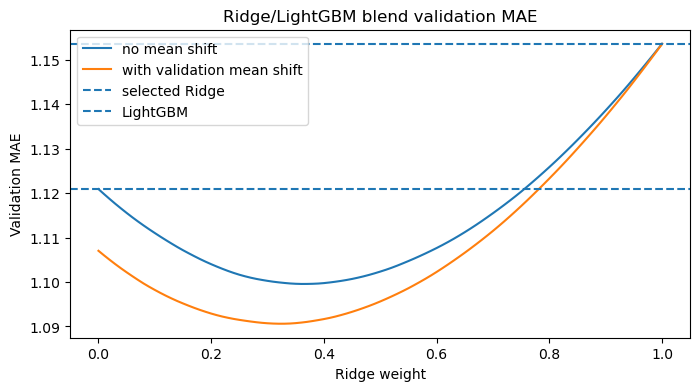

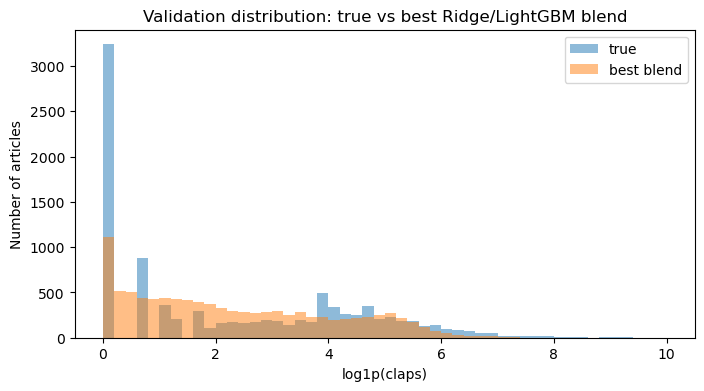

In [55]:
# Tune Ridge/LightGBM blend weight on validation

print("Base validation scores:")
print(f"Selected Ridge valid MAE: {selected_ridge_valid_mae:.5f}")
print(f"LightGBM valid MAE:       {lgb_valid_mae:.5f}")
print(f"MAE gap, LightGBM - Ridge:{lgb_valid_mae - selected_ridge_valid_mae:.5f}")

blend_results = []

for ridge_weight in np.linspace(0, 1, 101):
    lgbm_weight = 1 - ridge_weight

    blend_valid_pred = (
        ridge_weight * selected_ridge_valid_pred
        + lgbm_weight * lgb_valid_pred
    )

    # Both component models were trained with nonnegative/clipped targets.
    blend_valid_pred = np.clip(blend_valid_pred, 0, lgb_target_upper)

    blend_valid_mae = mean_absolute_error(y_valid, blend_valid_pred)

    # Optional validation-based mean calibration for the blend
    blend_shift = y_valid.mean() - blend_valid_pred.mean()

    blend_valid_pred_shifted = np.clip(
        blend_valid_pred + blend_shift,
        0,
        lgb_target_upper,
    )

    blend_valid_mae_shifted = mean_absolute_error(
        y_valid,
        blend_valid_pred_shifted,
    )

    blend_results.append({
        "ridge_weight": ridge_weight,
        "lgbm_weight": lgbm_weight,
        "valid_mae": blend_valid_mae,
        "blend_shift": blend_shift,
        "valid_mae_shifted": blend_valid_mae_shifted,
        "prediction_mean": blend_valid_pred.mean(),
        "shifted_prediction_mean": blend_valid_pred_shifted.mean(),
    })


blend_results = pd.DataFrame(blend_results)

# Select the best unshifted/shifted option based on validation MAE
best_unshifted_row = blend_results.sort_values("valid_mae").iloc[0]
best_shifted_row = blend_results.sort_values("valid_mae_shifted").iloc[0]

if best_shifted_row["valid_mae_shifted"] < best_unshifted_row["valid_mae"]:
    best_blend_uses_shift = True
    best_blend_ridge_weight = best_shifted_row["ridge_weight"]
    best_blend_lgbm_weight = best_shifted_row["lgbm_weight"]
    best_blend_shift = best_shifted_row["blend_shift"]
    best_blend_valid_mae = best_shifted_row["valid_mae_shifted"]
else:
    best_blend_uses_shift = False
    best_blend_ridge_weight = best_unshifted_row["ridge_weight"]
    best_blend_lgbm_weight = best_unshifted_row["lgbm_weight"]
    best_blend_shift = 0.0
    best_blend_valid_mae = best_unshifted_row["valid_mae"]


blend_results_display = blend_results.copy()
blend_results_display["best_mae_for_weight"] = blend_results_display[
    ["valid_mae", "valid_mae_shifted"]
].min(axis=1)

display(
    blend_results_display
    .sort_values("best_mae_for_weight")
    .head(20)
)

print("Best blend configuration:")
print(f"Ridge weight:         {best_blend_ridge_weight:.2f}")
print(f"LightGBM weight:      {best_blend_lgbm_weight:.2f}")
print(f"Use mean shift:       {best_blend_uses_shift}")
print(f"Blend mean shift:     {best_blend_shift:.5f}")
print(f"Best blend valid MAE: {best_blend_valid_mae:.5f}")
print()
print(f"Selected Ridge valid MAE: {selected_ridge_valid_mae:.5f}")
print(f"LightGBM valid MAE:       {lgb_valid_mae:.5f}")


# Build the selected validation blend for later diagnostics
best_blend_valid_pred = (
    best_blend_ridge_weight * selected_ridge_valid_pred
    + best_blend_lgbm_weight * lgb_valid_pred
)

best_blend_valid_pred = np.clip(
    best_blend_valid_pred,
    0,
    lgb_target_upper,
)

if best_blend_uses_shift:
    best_blend_valid_pred = np.clip(
        best_blend_valid_pred + best_blend_shift,
        0,
        lgb_target_upper,
    )


plt.figure(figsize=(8, 4))
plt.plot(
    blend_results["ridge_weight"],
    blend_results["valid_mae"],
    label="no mean shift",
)
plt.plot(
    blend_results["ridge_weight"],
    blend_results["valid_mae_shifted"],
    label="with validation mean shift",
)
plt.axhline(selected_ridge_valid_mae, linestyle="--", label="selected Ridge")
plt.axhline(lgb_valid_mae, linestyle="--", label="LightGBM")
plt.xlabel("Ridge weight")
plt.ylabel("Validation MAE")
plt.title("Ridge/LightGBM blend validation MAE")
plt.legend()
plt.show()


plt.figure(figsize=(8, 4))
plt.hist(y_valid, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(best_blend_valid_pred, bins=50, alpha=0.5, label="best blend", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Validation distribution: true vs best Ridge/LightGBM blend")
plt.legend()
plt.show()

The Ridge/LightGBM blend improved validation performance beyond both individual models.

The individual validation scores were:

- Selected Ridge validation MAE: **1.15361**
- LightGBM validation MAE: **1.12090**

LightGBM already reduced validation MAE by about **0.03271** compared with Ridge:

$$
1.15361 - 1.12090 = 0.03271
$$

However, the blend performed even better. The best validation blend used:

- Ridge weight: **0.32**
- LightGBM weight: **0.68**
- validation mean shift: **True**
- blend mean shift: **-0.06047**
- best blend validation MAE: **1.09060**

This improves over both individual models:

- Improvement over selected Ridge: **1.15361 → 1.09060**
- Improvement over LightGBM: **1.12090 → 1.09060**

The best blend is mostly LightGBM, but it still keeps about **32%** Ridge contribution. This suggests that Ridge and LightGBM capture complementary information: LightGBM is stronger overall, but Ridge still adds useful signal from the high-dimensional sparse text representation.

The validation mean shift also helped. The best unshifted blend in this region had MAE around **1.0996**, while the shifted blend improved to **1.09060**. This means the blend was still slightly overpredicting on average, and a small downward calibration improved validation MAE.

The next step is to train the final LightGBM model on the combined training + validation data, predict the held-out test set, blend it with the selected Ridge test predictions using the validation-selected weights, apply the validation-selected blend shift, and evaluate the final blended model on the held-out test set.


## Final LightGBM training and Ridge/LightGBM test evaluation

After selecting the best blend weight on the validation set, I now evaluate the final blended model on the held-out test set.

The final workflow is:

1. Rebuild LightGBM features using the combined training + validation data.
2. Fit the numeric imputer, frequency maps, target encodings, and SVD model only on train + validation.
3. Transform the held-out test set using those fitted objects.
4. Train the final LightGBM model on train + validation using the best validation LightGBM configuration.
5. Predict the test set with LightGBM.
6. Blend the LightGBM test predictions with the selected Ridge test predictions.
7. Apply the validation-selected blend mean shift.
8. Evaluate Ridge, LightGBM, and the final blend on the held-out test target.

The test target is used here for reporting the final benchmark results. The blend weights and calibration shift were already selected using the validation set, not the test set.


LightGBM final training target: log_claps_clipped
LightGBM final target upper value: 8.59287
Train + validation rows: 56,174
Test rows:               9,914

Final LightGBM feature matrices:
X_lgb_train_valid shape: (56174, 223)
X_lgb_test shape:        (9914, 223)
y_train_valid_lgb shape: (56174,)
y_test shape:            (9914,)
SVD explained variance ratio sum: 0.94946

Training final LightGBM model with:
Config:       l1_medium
n_estimators: 242

LightGBM held-out test results:
LightGBM test MAE:     1.04809
Prediction min:        0.00000
Prediction max:        7.21681
Prediction mean:       2.17611
Test target mean:      2.08826

Final Ridge/LightGBM blend held-out test results:
Ridge weight:                    0.32
LightGBM weight:                 0.68
Use blend mean shift:            True
Blend mean shift:                -0.06047

Selected Ridge test MAE:         1.10715
LightGBM test MAE:               1.04809
Blend test MAE before shift:     1.04069
Blend test MAE after shift: 

,model,validation_mae,test_mae,test_prediction_mean
2,Ridge/LightGBM blend,1.090603,1.028670,2.120454
1,LightGBM,1.120900,1.048089,2.176106
0,Selected Ridge,1.153614,1.107153,2.175902


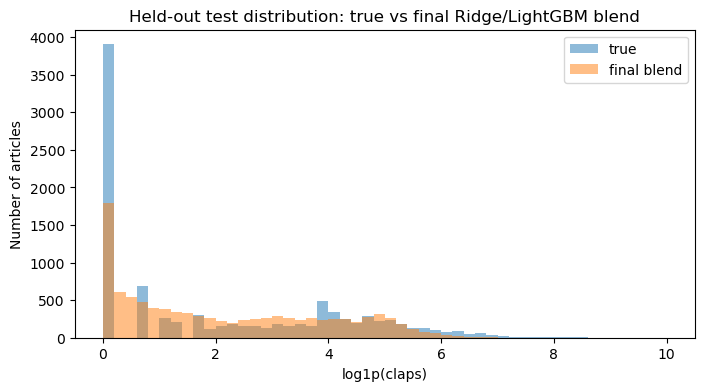

CPU times: user 1min 33s, sys: 17.3 s, total: 1min 50s
Wall time: 1min 11s


In [56]:
%%time

# Final LightGBM training and Ridge/LightGBM held-out test evaluation

# ---------------------------------------------------------------------
# 1. Prepare final train+validation target
# ---------------------------------------------------------------------

LGB_TARGET_COL = "log_claps_clipped"

if LGB_TARGET_COL not in train_valid_df.columns:
    raise ValueError(f"Missing LightGBM target column: {LGB_TARGET_COL}")

y_train_valid_lgb = train_valid_df[LGB_TARGET_COL].values
lgb_target_upper_final = train_valid_df[LGB_TARGET_COL].max()

print(f"LightGBM final training target: {LGB_TARGET_COL}")
print(f"LightGBM final target upper value: {lgb_target_upper_final:.5f}")
print(f"Train + validation rows: {len(train_valid_df):,}")
print(f"Test rows:               {len(test_df):,}")


# ---------------------------------------------------------------------
# 2. Numeric feature block for final LightGBM
# ---------------------------------------------------------------------

lgb_final_numeric_imputer = SimpleImputer(strategy="median")

X_lgb_train_valid_numeric_raw = (
    train_valid_df[numeric_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

X_lgb_test_numeric_raw = (
    test_df[numeric_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

X_lgb_train_valid_numeric = lgb_final_numeric_imputer.fit_transform(
    X_lgb_train_valid_numeric_raw
)

X_lgb_test_numeric = lgb_final_numeric_imputer.transform(
    X_lgb_test_numeric_raw
)

X_lgb_train_valid_numeric = pd.DataFrame(
    X_lgb_train_valid_numeric,
    columns=numeric_feature_cols,
    index=train_valid_df.index,
).astype(np.float32)

X_lgb_test_numeric = pd.DataFrame(
    X_lgb_test_numeric,
    columns=numeric_feature_cols,
    index=test_df.index,
).astype(np.float32)


# ---------------------------------------------------------------------
# 3. Frequency and target-encoding features
# ---------------------------------------------------------------------

author_freq_train_valid = make_frequency_map(train_valid_df["author_clean"])
publication_freq_train_valid = make_frequency_map(train_valid_df["publication_clean"])

author_te_train_valid, author_te_global_final = make_smoothed_target_encoding(
    train_keys=train_valid_df["author_clean"],
    train_targets=y_train_valid_lgb,
    apply_keys=None,
    smoothing=50,
)

author_te_test, _ = make_smoothed_target_encoding(
    train_keys=train_valid_df["author_clean"],
    train_targets=y_train_valid_lgb,
    apply_keys=test_df["author_clean"],
    smoothing=50,
)

publication_te_train_valid, publication_te_global_final = make_smoothed_target_encoding(
    train_keys=train_valid_df["publication_clean"],
    train_targets=y_train_valid_lgb,
    apply_keys=None,
    smoothing=50,
)

publication_te_test, _ = make_smoothed_target_encoding(
    train_keys=train_valid_df["publication_clean"],
    train_targets=y_train_valid_lgb,
    apply_keys=test_df["publication_clean"],
    smoothing=50,
)

X_lgb_train_valid_extra = build_lgbm_extra_features(
    frame=train_valid_df,
    author_freq_map=author_freq_train_valid,
    publication_freq_map=publication_freq_train_valid,
    author_te_values=author_te_train_valid,
    publication_te_values=publication_te_train_valid,
)

X_lgb_test_extra = build_lgbm_extra_features(
    frame=test_df,
    author_freq_map=author_freq_train_valid,
    publication_freq_map=publication_freq_train_valid,
    author_te_values=author_te_test,
    publication_te_values=publication_te_test,
)


# ---------------------------------------------------------------------
# 4. SVD compressed sparse features
# ---------------------------------------------------------------------

n_svd_components_final = 150

svd_final_for_lgbm = TruncatedSVD(
    n_components=n_svd_components_final,
    n_iter=7,
    random_state=RANDOM_STATE,
)

X_lgb_train_valid_svd = svd_final_for_lgbm.fit_transform(
    X_train_valid_sparse
)

X_lgb_test_svd = svd_final_for_lgbm.transform(
    X_test_sparse_final
)

svd_final_columns = [
    f"svd_sparse_{i:03d}"
    for i in range(n_svd_components_final)
]

X_lgb_train_valid_svd = pd.DataFrame(
    X_lgb_train_valid_svd,
    columns=svd_final_columns,
    index=train_valid_df.index,
).astype(np.float32)

X_lgb_test_svd = pd.DataFrame(
    X_lgb_test_svd,
    columns=svd_final_columns,
    index=test_df.index,
).astype(np.float32)


# ---------------------------------------------------------------------
# 5. Combine final LightGBM feature blocks
# ---------------------------------------------------------------------

X_lgb_train_valid = pd.concat(
    [
        X_lgb_train_valid_numeric,
        X_lgb_train_valid_extra,
        X_lgb_train_valid_svd,
    ],
    axis=1,
)

X_lgb_test = pd.concat(
    [
        X_lgb_test_numeric,
        X_lgb_test_extra,
        X_lgb_test_svd,
    ],
    axis=1,
)

print("\nFinal LightGBM feature matrices:")
print(f"X_lgb_train_valid shape: {X_lgb_train_valid.shape}")
print(f"X_lgb_test shape:        {X_lgb_test.shape}")
print(f"y_train_valid_lgb shape: {y_train_valid_lgb.shape}")
print(f"y_test shape:            {y_test.shape}")
print(f"SVD explained variance ratio sum: {svd_final_for_lgbm.explained_variance_ratio_.sum():.5f}")


# ---------------------------------------------------------------------
# 6. Train final LightGBM model using the best validation config
# ---------------------------------------------------------------------

best_lgbm_params = None

for config in lgbm_configs:
    if config["name"] == best_lgbm_config_name:
        best_lgbm_params = config.copy()
        break

if best_lgbm_params is None:
    raise ValueError(f"Could not find best LightGBM config: {best_lgbm_config_name}")

best_lgbm_params.pop("name")

final_lgbm_n_estimators = int(lgbm_valid_model.best_iteration_)

# Important: replace the config n_estimators with the best validation iteration.
best_lgbm_params["n_estimators"] = final_lgbm_n_estimators

print("\nTraining final LightGBM model with:")
print(f"Config:       {best_lgbm_config_name}")
print(f"n_estimators: {final_lgbm_n_estimators}")

final_lgbm_model = LGBMRegressor(
    **best_lgbm_params,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

final_lgbm_model.fit(
    X_lgb_train_valid,
    y_train_valid_lgb,
)

lgb_test_pred_raw = final_lgbm_model.predict(X_lgb_test)

lgb_test_pred = np.clip(
    lgb_test_pred_raw,
    0,
    lgb_target_upper_final,
)

lgb_test_mae = mean_absolute_error(y_test, lgb_test_pred)

print("\nLightGBM held-out test results:")
print(f"LightGBM test MAE:     {lgb_test_mae:.5f}")
print(f"Prediction min:        {lgb_test_pred.min():.5f}")
print(f"Prediction max:        {lgb_test_pred.max():.5f}")
print(f"Prediction mean:       {lgb_test_pred.mean():.5f}")
print(f"Test target mean:      {y_test.mean():.5f}")


# ---------------------------------------------------------------------
# 7. Blend selected Ridge and final LightGBM test predictions
# ---------------------------------------------------------------------

blend_test_pred = (
    best_blend_ridge_weight * selected_ridge_test_pred
    + best_blend_lgbm_weight * lgb_test_pred
)

blend_test_pred = np.clip(
    blend_test_pred,
    0,
    lgb_target_upper_final,
)

if best_blend_uses_shift:
    blend_test_pred_shifted = np.clip(
        blend_test_pred + best_blend_shift,
        0,
        lgb_target_upper_final,
    )
else:
    blend_test_pred_shifted = blend_test_pred.copy()

blend_test_mae = mean_absolute_error(y_test, blend_test_pred)
blend_test_mae_shifted = mean_absolute_error(y_test, blend_test_pred_shifted)

# Store final selected blend prediction
final_blend_test_pred = blend_test_pred_shifted.copy()
final_blend_test_mae = blend_test_mae_shifted

print("\nFinal Ridge/LightGBM blend held-out test results:")
print(f"Ridge weight:                    {best_blend_ridge_weight:.2f}")
print(f"LightGBM weight:                 {best_blend_lgbm_weight:.2f}")
print(f"Use blend mean shift:            {best_blend_uses_shift}")
print(f"Blend mean shift:                {best_blend_shift:.5f}")
print()
print(f"Selected Ridge test MAE:         {selected_ridge_test_mae:.5f}")
print(f"LightGBM test MAE:               {lgb_test_mae:.5f}")
print(f"Blend test MAE before shift:     {blend_test_mae:.5f}")
print(f"Blend test MAE after shift:      {blend_test_mae_shifted:.5f}")
print()
print(f"True test target mean:           {y_test.mean():.5f}")
print(f"Selected Ridge prediction mean:  {selected_ridge_test_pred.mean():.5f}")
print(f"LightGBM prediction mean:        {lgb_test_pred.mean():.5f}")
print(f"Final blend prediction mean:     {final_blend_test_pred.mean():.5f}")
print()
print(f"Final blend prediction min:      {final_blend_test_pred.min():.5f}")
print(f"Final blend prediction max:      {final_blend_test_pred.max():.5f}")


comparison_results = pd.DataFrame([
    {
        "model": "Selected Ridge",
        "validation_mae": selected_ridge_valid_mae,
        "test_mae": selected_ridge_test_mae,
        "test_prediction_mean": selected_ridge_test_pred.mean(),
    },
    {
        "model": "LightGBM",
        "validation_mae": lgb_valid_mae,
        "test_mae": lgb_test_mae,
        "test_prediction_mean": lgb_test_pred.mean(),
    },
    {
        "model": "Ridge/LightGBM blend",
        "validation_mae": best_blend_valid_mae,
        "test_mae": final_blend_test_mae,
        "test_prediction_mean": final_blend_test_pred.mean(),
    },
]).sort_values("test_mae")

display(comparison_results)


plt.figure(figsize=(8, 4))
plt.hist(y_test, bins=50, alpha=0.5, label="true", range=(0, 10))
plt.hist(final_blend_test_pred, bins=50, alpha=0.5, label="final blend", range=(0, 10))
plt.xlabel("log1p(claps)")
plt.ylabel("Number of articles")
plt.title("Held-out test distribution: true vs final Ridge/LightGBM blend")
plt.legend()
plt.show()

The final Ridge/LightGBM workflow improved the held-out test performance.

The final LightGBM model was trained on the combined training + validation data using:

- Target: `log_claps_clipped`
- Best validation config: `l1_medium`
- Number of estimators: **242**
- Final LightGBM feature matrix shape: `(56174, 223)`
- Test feature matrix shape: `(9914, 223)`
- Final SVD explained variance ratio sum: **0.94946**

On the held-out test set, the individual model scores were:

- Selected Ridge test MAE: **1.10715**
- LightGBM test MAE: **1.04809**

LightGBM performed better than Ridge, showing that the compact numeric, target-encoded, and SVD-compressed sparse features captured useful nonlinear signal.

The final blend used the validation-selected weights:

- Ridge weight: **0.32**
- LightGBM weight: **0.68**
- Validation-selected mean shift: **-0.06047**

The blend improved the test score further:

- Blend test MAE before shift: **1.04069**
- Blend test MAE after shift: **1.02867**

The final model comparison is:

| Model | Validation MAE | Test MAE | Test prediction mean |
|---|---:|---:|---:|
| Ridge/LightGBM blend | **1.09060** | **1.02867** | **2.12045** |
| LightGBM | 1.12090 | 1.04809 | 2.17611 |
| Selected Ridge | 1.15361 | 1.10715 | 2.17590 |

The true test target mean was **2.08826**, while the final blend prediction mean was **2.12045**. This is closer than the individual model means and suggests that the blend is better calibrated.

Overall, the best model is the shifted Ridge/LightGBM blend. It combines Ridge’s high-dimensional sparse signal with LightGBM’s nonlinear numeric, target-encoded, and SVD-compressed sparse-feature signal, and it gives the lowest held-out test MAE.


## Error analysis for the final blended model

This section examines where the final blended model performs well and where it struggles.

The final model has already been selected, so this step is only for interpretation. The test-set diagnostics are not used to tune the model further.

The error analysis checks:

- overall residual distribution
- whether the model tends to overpredict or underpredict
- MAE by true `log_claps` ranges
- performance on zero-clap, low-clap, medium-clap, and high-clap articles
- examples with the largest absolute errors

This helps explain the final model behavior and shows which kinds of Medium articles are hardest to predict.


Final blend error summary:
Test MAE:              1.02867
Mean residual:         0.03220
Median residual:       0.06424
Residual std:          1.44249
Mean absolute error:   1.02867
Median absolute error: 0.71680


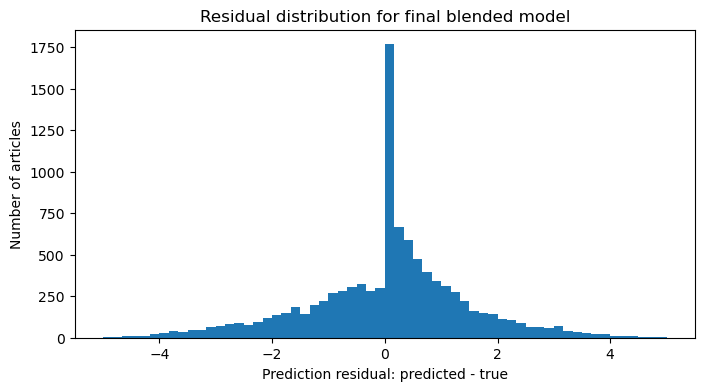

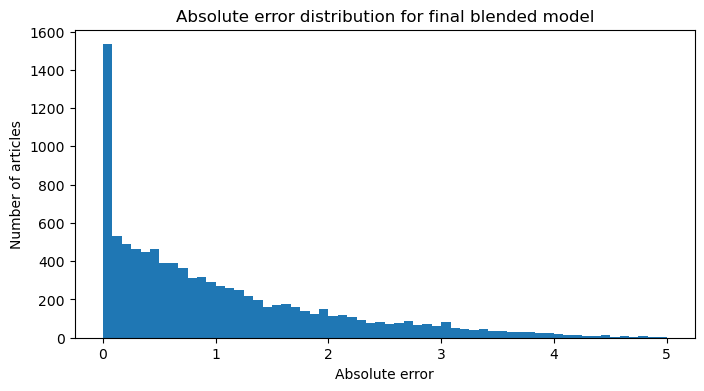

,target_bin,rows,mean_true_log_claps,mean_pred_log_claps,mean_residual,mae,median_abs_error
0,0,3905,0.000000,0.730376,0.730376,0.730376,0.369091
1,"(0, 1]",687,0.693147,1.317937,0.624790,0.921208,0.586750
2,"(1, 2]",891,1.481962,2.004191,0.522230,1.182935,0.976574
3,"(2, 4]",1942,3.178051,2.840991,-0.337060,1.243120,1.067979
4,"(4, 6]",2097,4.818503,3.837685,-0.980819,1.203661,0.840096
5,"(6, 8]",370,6.589502,4.833889,-1.755612,1.768959,1.511752
6,> 8,22,8.729548,5.706110,-3.023439,3.023439,2.721470


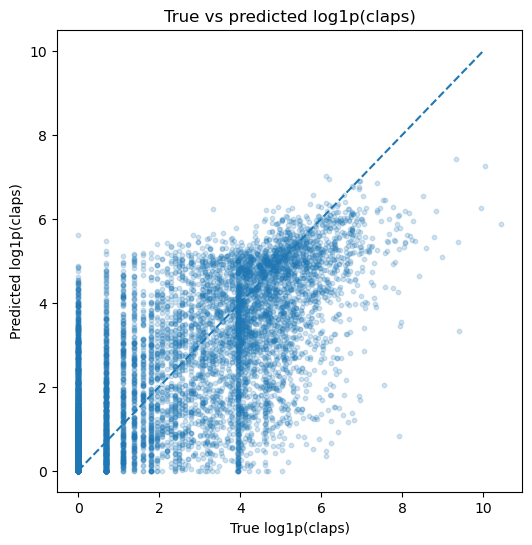

,post_id,published_at,title_text,author_clean,publication_clean,true_claps,predicted_claps,y_true_log_claps,y_pred_log_claps,residual,absolute_error
8351,c10dde42037a,2018-09-23 11:00:06+00:00,Bots Vs Scambots — How AI can tackle online fr...,Jonas Karlberg jonaskarlberg,,2707.0,1.270415,7.903966,0.819963,-7.084003,7.084003
6776,8748dd907f60,2018-09-15 13:26:55+00:00,"Get Everybody Moving Hey everyone, G.E.M. here...",G.E.M. gemtang,,12141.0,26.625907,9.404426,3.318754,-6.085672,6.085672
1621,af4089ce0292,2018-08-22 05:41:10+00:00,Technologies That Influenced Startups in 2018 ...,"Netsmartz, LLC netsmartzllc",,452.0,0.404062,6.115892,0.339370,-5.776523,5.776523
3404,3eb8d22a51a6,2018-08-30 07:53:42+00:00,Can Õpet Foundation Change Education for the B...,Crypto Talk cryptotales50,,450.0,0.613765,6.111467,0.478570,-5.632897,5.632897
3523,760e48f473fc,2018-08-30 15:38:22+00:00,Join Us LIVE to Learn About Predictive Analyti...,Endor Protocol endorprotocol,Noteworthy - The Journal Blog did-you-know-the...,0.0,273.321456,0.000000,5.614301,5.614301,5.614301
6142,b504cf4e51a0,2018-09-12 14:55:47+00:00,The Future of Cloud Storage is Here BigMIND by...,Zoolz Zoolz,,891.0,2.311286,6.793466,1.197337,-5.596129,5.596129
9459,dfd851a0d014,2018-09-28 00:16:43+00:00,Oxymoron Can I please talk to a human,hannah miller slmiller116,,515.0,0.943377,6.246107,0.664427,-5.581680,5.581680
4097,df9b91a1381c,2018-09-02 17:57:25+00:00,Melior Team collaborates with e-commerce compa...,Melior.AI meliorAI,Melior.AI melior-ai,778.0,2.164831,6.658011,1.152100,-5.505911,5.505911
8212,56665af7e9fa,2018-09-22 07:01:05+00:00,The Power Of Your Voice Artificial Intelligent...,Huong Pham phamhuonghlp,,1910.0,6.764171,7.555382,2.049520,-5.505862,5.505862
7847,5e265ed9da0a,2018-09-20 13:55:22+00:00,"CONTACT: 42@melior.ai London, 11 September 201...",Melior.AI meliorAI,Melior.AI melior-ai,607.0,1.507479,6.410175,0.919278,-5.490897,5.490897


In [57]:
# Error analysis for the final blended model

test_error_df = test_df.copy()

test_error_df["y_true_log_claps"] = y_test
test_error_df["y_pred_log_claps"] = final_blend_test_pred
test_error_df["residual"] = (
    test_error_df["y_pred_log_claps"] - test_error_df["y_true_log_claps"]
)
test_error_df["absolute_error"] = test_error_df["residual"].abs()

# Back-transform for interpretability.
test_error_df["true_claps"] = np.expm1(test_error_df["y_true_log_claps"])
test_error_df["predicted_claps"] = np.expm1(test_error_df["y_pred_log_claps"])

print("Final blend error summary:")
print(f"Test MAE:              {final_blend_test_mae:.5f}")
print(f"Mean residual:         {test_error_df['residual'].mean():.5f}")
print(f"Median residual:       {test_error_df['residual'].median():.5f}")
print(f"Residual std:          {test_error_df['residual'].std():.5f}")
print(f"Mean absolute error:   {test_error_df['absolute_error'].mean():.5f}")
print(f"Median absolute error: {test_error_df['absolute_error'].median():.5f}")


# ------------------------------------------------------------
# 1. Residual distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.hist(test_error_df["residual"], bins=60, range=(-5, 5))
plt.xlabel("Prediction residual: predicted - true")
plt.ylabel("Number of articles")
plt.title("Residual distribution for final blended model")
plt.show()


plt.figure(figsize=(8, 4))
plt.hist(test_error_df["absolute_error"], bins=60, range=(0, 5))
plt.xlabel("Absolute error")
plt.ylabel("Number of articles")
plt.title("Absolute error distribution for final blended model")
plt.show()


# ------------------------------------------------------------
# 2. MAE by target range
# ------------------------------------------------------------

test_error_df["target_bin"] = pd.cut(
    test_error_df["y_true_log_claps"],
    bins=[-0.001, 0.001, 1, 2, 4, 6, 8, np.inf],
    labels=[
        "0",
        "(0, 1]",
        "(1, 2]",
        "(2, 4]",
        "(4, 6]",
        "(6, 8]",
        "> 8",
    ],
)

target_bin_summary = (
    test_error_df
    .groupby("target_bin", observed=False)
    .agg(
        rows=("absolute_error", "size"),
        mean_true_log_claps=("y_true_log_claps", "mean"),
        mean_pred_log_claps=("y_pred_log_claps", "mean"),
        mean_residual=("residual", "mean"),
        mae=("absolute_error", "mean"),
        median_abs_error=("absolute_error", "median"),
    )
    .reset_index()
)

display(target_bin_summary)


# ------------------------------------------------------------
# 3. Scatter plot: true vs predicted
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(
    test_error_df["y_true_log_claps"],
    test_error_df["y_pred_log_claps"],
    alpha=0.2,
    s=10,
)
plt.plot([0, 10], [0, 10], linestyle="--")
plt.xlabel("True log1p(claps)")
plt.ylabel("Predicted log1p(claps)")
plt.title("True vs predicted log1p(claps)")
plt.show()


# ------------------------------------------------------------
# 4. Largest errors
# ------------------------------------------------------------

largest_errors = (
    test_error_df
    .sort_values("absolute_error", ascending=False)
    [
        [
            "post_id",
            "published_at",
            "title_text",
            "author_clean",
            "publication_clean",
            "true_claps",
            "predicted_claps",
            "y_true_log_claps",
            "y_pred_log_claps",
            "residual",
            "absolute_error",
        ]
    ]
    .head(20)
)

display(largest_errors)

The error analysis shows that the final Ridge/LightGBM blend performs well overall, but it still has the typical weaknesses of popularity prediction on a long-tailed target.

The final blended model achieved:

- Test MAE: **1.02867**
- Mean residual: **0.03220**
- Median residual: **0.06424**
- Residual standard deviation: **1.44249**
- Median absolute error: **0.71680**

The mean and median residuals are close to zero, which suggests that the final model is reasonably calibrated on average across the full held-out test set. However, this global average hides important differences across engagement levels. The mean absolute error is noticeably larger than the median absolute error, which means that most articles have moderate errors, but a smaller number of difficult articles create large misses and raise the overall MAE.

The residual histogram is centered near zero, but it has long tails in both directions. This means the model is not consistently wrong in only one direction overall, but it does make some large overpredictions and underpredictions. The absolute-error histogram is strongly right-skewed: many predictions have relatively small errors, while a smaller number of articles produce much larger errors.

The target-bin analysis shows a clear pattern:

| True target range | Rows | Mean residual | MAE |
|---|---:|---:|---:|
| `0` | 3,905 | **+0.73038** | 0.73038 |
| `(0, 1]` | 687 | **+0.62479** | 0.92121 |
| `(1, 2]` | 891 | **+0.52223** | 1.18294 |
| `(2, 4]` | 1,942 | **-0.33706** | 1.24312 |
| `(4, 6]` | 2,097 | **-0.98082** | 1.20366 |
| `(6, 8]` | 370 | **-1.75561** | 1.76896 |
| `> 8` | 22 | **-3.02344** | 3.02344 |

The model tends to overpredict zero-clap and very-low-clap articles. For the 3,905 zero-clap articles, the average prediction is above zero, producing a mean residual of **+0.73038**. This suggests that the model often identifies article characteristics associated with some engagement, even when the article ultimately receives no claps.

For medium- and high-engagement articles, the pattern reverses. Starting around the `(2, 4]` target range, the mean residual becomes negative, meaning the model increasingly underpredicts articles with higher true engagement. This underprediction becomes much stronger for rare viral articles: the `> 8` bin has only 22 articles, but its MAE is **3.02344**, far above the overall test MAE.

The true-vs-predicted scatter plot shows the same behavior visually. The dashed diagonal line represents perfect predictions. Points above the line are overpredictions, and points below the line are underpredictions. The model captures the general upward trend, but predictions are compressed toward the middle of the target range. Many low-clap articles are predicted too high, while the most popular articles fall well below the diagonal line. This is a common pattern in long-tailed popularity prediction: the model learns typical engagement levels better than rare extreme outcomes.

The vertical bands in the scatter plot are expected because the true target comes from integer clap counts transformed with `log1p`. Many articles share the same raw clap count, especially at low values, so they appear at the same true target value on the x-axis.

The largest-error table confirms the same failure modes. Many of the worst errors are articles with hundreds or thousands of true claps that the model predicted much lower. There is also a zero-clap article with a high predicted value, showing that the model can sometimes mistake features associated with popularity for actual engagement.

Overall, the final blend is strong for the majority of articles and reasonably calibrated in aggregate, but it is not equally calibrated across all engagement levels. It performs best in common engagement ranges and struggles at both extremes: true zero-clap articles and rare viral articles. This limitation is expected for Medium engagement data because popularity is highly long-tailed, noisy, and influenced by factors that may not be fully captured in the available article text and metadata.

<details>
<summary><span style="color:red">
about this section:
</span></summary>   

This section analyzes **where the final blended model makes mistakes** on the held-out test set.

The final MAE gives one overall number, but error analysis helps answer more useful questions:

* Is the model systematically overpredicting or underpredicting?
* Does it perform better for low-, medium-, or high-engagement articles?
* Does it struggle with rare viral articles?
* Which individual articles produced the largest errors?


## 1. Create a test error dataframe

```python
test_error_df = test_df.copy()
```

This copies the held-out test dataframe so we can add error-analysis columns without modifying the original `test_df`.


## 2. Store true and predicted log-clap values

```python
test_error_df["y_true_log_claps"] = y_test
test_error_df["y_pred_log_claps"] = final_blend_test_pred
```

These columns store:

| Column             | Meaning                                              |
| ------------------ | ---------------------------------------------------- |
| `y_true_log_claps` | Actual target value, `log1p(claps)`                  |
| `y_pred_log_claps` | Final blended model prediction on the same log scale |

The model is still evaluated on the **log-transformed target**, not raw claps.


## 3. Calculate residuals and absolute errors

```python
test_error_df["residual"] = (
    test_error_df["y_pred_log_claps"] - test_error_df["y_true_log_claps"]
)
test_error_df["absolute_error"] = test_error_df["residual"].abs()
```

The residual is:

```text
residual = prediction - actual
```

So:

* positive residual means the model **overpredicted**
* negative residual means the model **underpredicted**
* residual close to `0` means the prediction was close

The absolute error ignores direction:

```text
absolute_error = |prediction - actual|
```

This is what MAE averages.


## 4. Back-transform predictions for interpretability

```python
test_error_df["true_claps"] = np.expm1(test_error_df["y_true_log_claps"])
test_error_df["predicted_claps"] = np.expm1(test_error_df["y_pred_log_claps"])
```

Because the target was created with:

```python
log_claps = np.log1p(claps)
```

the inverse transformation is:

```python
claps = np.expm1(log_claps)
```

This makes the errors easier to understand in raw clap units.

For example:

```text
log1p(claps) = 4.615
```

corresponds to about:

```text
expm1(4.615) ≈ 100 claps
```

Important: the official metric is still calculated on `log1p(claps)`. The back-transformed clap values are mainly for interpretation.


## 5. Print overall error summary

```python
print("Final blend error summary:")
print(f"Test MAE:              {final_blend_test_mae:.5f}")
print(f"Mean residual:         {test_error_df['residual'].mean():.5f}")
print(f"Median residual:       {test_error_df['residual'].median():.5f}")
print(f"Residual std:          {test_error_df['residual'].std():.5f}")
print(f"Mean absolute error:   {test_error_df['absolute_error'].mean():.5f}")
print(f"Median absolute error: {test_error_df['absolute_error'].median():.5f}")
```

This summarizes the model’s test errors.

| Metric                  | Meaning                                                 |
| ----------------------- | ------------------------------------------------------- |
| `Test MAE`              | Average absolute error on `log1p(claps)`                |
| `Mean residual`         | Average signed error; shows overall bias                |
| `Median residual`       | Typical signed error                                    |
| `Residual std`          | Spread of signed errors                                 |
| `Mean absolute error`   | Same concept as MAE                                     |
| `Median absolute error` | Typical absolute error, less affected by large outliers |

If the mean residual is positive, the model overpredicts on average.
If it is negative, the model underpredicts on average.

## 6. Plot residual distribution

```python
plt.figure(figsize=(8, 4))
plt.hist(test_error_df["residual"], bins=60, range=(-5, 5))
plt.xlabel("Prediction residual: predicted - true")
plt.ylabel("Number of articles")
plt.title("Residual distribution for final blended model")
plt.show()
```

This plot shows the distribution of signed errors.

It helps us see whether the model is:

* centered near zero
* biased toward overprediction
* biased toward underprediction
* producing many extreme errors

A good residual distribution should ideally be centered near `0`, although real-world engagement data is long-tailed, so some large errors are expected.

## 7. Plot absolute error distribution

```python
plt.figure(figsize=(8, 4))
plt.hist(test_error_df["absolute_error"], bins=60, range=(0, 5))
plt.xlabel("Absolute error")
plt.ylabel("Number of articles")
plt.title("Absolute error distribution for final blended model")
plt.show()
```

This plot shows how large the errors are, regardless of direction.

It helps answer:

> Are most predictions close, or are there many large misses?

For long-tailed engagement prediction, most errors are usually moderate, while a smaller number of articles have very large errors.


## 8. Group error by target range

```python
test_error_df["target_bin"] = pd.cut(
    test_error_df["y_true_log_claps"],
    bins=[-0.001, 0.001, 1, 2, 4, 6, 8, np.inf],
    labels=[
        "0",
        "(0, 1]",
        "(1, 2]",
        "(2, 4]",
        "(4, 6]",
        "(6, 8]",
        "> 8",
    ],
)
```

This groups test articles based on their true `log1p(claps)` value.

The bins mean:

| Bin      |  Approximate raw clap range |
| -------- | --------------------------: |
| `0`      |             exactly 0 claps |
| `(0, 1]` |             about 1–2 claps |
| `(1, 2]` |             about 2–6 claps |
| `(2, 4]` |            about 6–54 claps |
| `(4, 6]` |          about 54–402 claps |
| `(6, 8]` |       about 402–2,980 claps |
| `> 8`    | more than about 2,980 claps |

This is useful because the model may behave very differently for low-, medium-, and high-engagement articles.

<details>
<summary><span style="color:red">
about on this:
</span></summary>  

I converted the log-scale bin boundaries back to raw claps using the inverse of `log1p`.

Our target is:

```python
log_claps = np.log1p(claps)
```

That means:

```python
log_claps = log(claps + 1)
```

To go back to raw claps, use:

```python
claps = np.expm1(log_claps)
```

which means:

```text
claps = exp(log_claps) - 1
```

So for each bin boundary:

| Log boundary |          Raw clap value |
| -----------: | ----------------------: |
|          `0` |        `exp(0) - 1 = 0` |
|          `1` |     `exp(1) - 1 ≈ 1.72` |
|          `2` |     `exp(2) - 1 ≈ 6.39` |
|          `4` |    `exp(4) - 1 ≈ 53.60` |
|          `6` |   `exp(6) - 1 ≈ 402.43` |
|          `8` | `exp(8) - 1 ≈ 2,979.96` |

So this bin:

```python
"(4, 6]"
```

means:

```text
4 < log1p(claps) <= 6
```

Back-transformed:

```text
exp(4) - 1 < claps <= exp(6) - 1
```

So approximately:

```text
53.6 < claps <= 402.4
```

Since clap counts are whole numbers, that is roughly:

```text
54 to 402 claps
```

A more precise table would be:

| Log bin  |  Approximate raw clap range |
| -------- | --------------------------: |
| `0`      |             exactly 0 claps |
| `(0, 1]` |                about 1 clap |
| `(1, 2]` |             about 2–6 claps |
| `(2, 4]` |            about 7–53 claps |
| `(4, 6]` |          about 54–402 claps |
| `(6, 8]` |       about 403–2,979 claps |
| `> 8`    | more than about 2,980 claps |

So the earlier “about 1–2 claps” for `(0, 1]` was a bit loose. More accurately, for integer clap counts, `(0, 1]` corresponds to **1 clap**.

</details>

## 9. Summarize error by target bin

```python
target_bin_summary = (
    test_error_df
    .groupby("target_bin", observed=False)
    .agg(
        rows=("absolute_error", "size"),
        mean_true_log_claps=("y_true_log_claps", "mean"),
        mean_pred_log_claps=("y_pred_log_claps", "mean"),
        mean_residual=("residual", "mean"),
        mae=("absolute_error", "mean"),
        median_abs_error=("absolute_error", "median"),
    )
    .reset_index()
)

display(target_bin_summary)
```

This creates a compact table showing model performance by true target range.

For each bin, it reports:

| Column                | Meaning                                      |
| --------------------- | -------------------------------------------- |
| `rows`                | Number of test articles in that target range |
| `mean_true_log_claps` | Average true target value in the bin         |
| `mean_pred_log_claps` | Average predicted value in the bin           |
| `mean_residual`       | Average over/underprediction in the bin      |
| `mae`                 | Average absolute error in the bin            |
| `median_abs_error`    | Median absolute error in the bin             |

This is one of the most important parts of the error analysis because it reveals whether the model struggles more with certain engagement ranges.

For our project, this is especially relevant because Medium engagement is long-tailed. The model is expected to do better in common engagement ranges and worse on rare viral articles.


## 10. True vs predicted scatter plot

```python
plt.figure(figsize=(6, 6))
plt.scatter(
    test_error_df["y_true_log_claps"],
    test_error_df["y_pred_log_claps"],
    alpha=0.2,
    s=10,
)
plt.plot([0, 10], [0, 10], linestyle="--")
plt.xlabel("True log1p(claps)")
plt.ylabel("Predicted log1p(claps)")
plt.title("True vs predicted log1p(claps)")
plt.show()
```

This plot compares true values to predicted values.

The dashed line represents perfect predictions:

```text
predicted = true
```

Points near the line are good predictions.

Points above the line are overpredictions.

Points below the line are underpredictions.

This plot usually makes the main limitation visible:

* very high-clap articles are often underpredicted
* zero- or very-low-clap articles may be overpredicted
* predictions are often pulled toward the middle because extreme engagement is hard to predict

## 11. Inspect largest individual errors

```python
largest_errors = (
    test_error_df
    .sort_values("absolute_error", ascending=False)
    [
        [
            "post_id",
            "published_at",
            "title_text",
            "author_clean",
            "publication_clean",
            "true_claps",
            "predicted_claps",
            "y_true_log_claps",
            "y_pred_log_claps",
            "residual",
            "absolute_error",
        ]
    ]
    .head(20)
)

display(largest_errors)
```

This shows the 20 articles with the largest absolute errors.

The selected columns make the errors interpretable:

| Column              | Why it is useful                         |
| ------------------- | ---------------------------------------- |
| `post_id`           | identifies the article                   |
| `published_at`      | shows when it was published              |
| `title_text`        | lets you inspect the article topic/title |
| `author_clean`      | shows author signal                      |
| `publication_clean` | shows publication signal                 |
| `true_claps`        | actual raw clap count                    |
| `predicted_claps`   | predicted raw clap count                 |
| `y_true_log_claps`  | actual log target                        |
| `y_pred_log_claps`  | predicted log target                     |
| `residual`          | direction of error                       |
| `absolute_error`    | size of error                            |

This helps diagnose whether the largest errors are mostly:

* viral articles that the model underpredicted
* low-clap articles that the model overpredicted
* articles from unseen authors/publications
* unusual topics or titles
* rows with missing metadata


## Why this section matters

A final test MAE tells us how well the model performs on average, but it does not explain **how** the model fails.

This section shows that the final blended model is not perfect and helps identify realistic limitations:

* popularity prediction is difficult because engagement is long-tailed
* rare viral articles are hard to predict from metadata/text alone
* some zero-clap or very-low-clap articles may be overpredicted
* predictions tend to be pulled toward common engagement ranges

So:  

This section analyzes the final blended model’s errors on the held-out chronological test set.

I calculate signed residuals, absolute errors, and back-transformed clap predictions for interpretability. The official metric remains MAE on `log1p(claps)`, but converting predictions back to raw clap units makes the largest errors easier to inspect.

The residual and absolute-error histograms show the overall error distribution. I also group errors by true target range to understand whether the model performs differently for zero-clap, low-engagement, medium-engagement, and high-engagement articles. Finally, I inspect the largest individual errors to identify the types of articles the model misses most severely.

This analysis is important because Medium engagement is highly long-tailed. The final blend performs well on common engagement ranges, but rare viral articles and some zero-clap articles remain difficult to predict.

</details>

## Interpreting the LightGBM component with feature importance

The final blend combines Ridge and LightGBM, but the blend is mostly LightGBM:

- Ridge weight: `0.32`
- LightGBM weight: `0.68`

Because LightGBM contributes most of the final prediction, the final LightGBM model’s feature importance is inspected.

This does not explain the full blended model perfectly, because Ridge also contributes predictions. However, it helps identify which compact features LightGBM relied on most, such as:

- engineered numeric features
- author/publication frequency features
- target-encoding features
- SVD-compressed sparse components

This step is interpretability-focused. It should not be used to tune the model on the test set.


Top LightGBM features by gain importance:


,feature,split_importance,gain_importance,gain_importance_normalized,feature_group
72,publication_target_encoding_lgb,1983,544725.662672,0.357524,Target encoding
68,author_target_encoding_lgb,1790,383604.774496,0.251774,Target encoding
51,usersFollowedByCount_value,869,171148.872794,0.112331,Engineered numeric
74,svd_sparse_001,678,65627.228084,0.043074,SVD compressed sparse
70,publication_frequency_lgb,414,39222.906451,0.025743,Frequency
66,author_frequency_lgb,747,35426.347903,0.023252,Frequency
52,log1p_usersFollowedByCount,168,27802.202768,0.018248,Engineered numeric
42,imageCount_value,230,14222.915220,0.009335,Engineered numeric
7,metadata_char_count,92,11445.827516,0.007512,Engineered numeric
106,svd_sparse_033,255,10893.899090,0.007150,SVD compressed sparse



Feature-group importance:


,feature_group,total_gain_importance,total_split_importance,feature_count,gain_importance_share
4,Target encoding,928330.437168,3773,2,0.609298
0,Engineered numeric,278074.863317,2934,65,0.182511
3,SVD compressed sparse,234951.674226,7025,150,0.154208
1,Frequency,81360.570272,1269,4,0.053400
2,Other,889.636967,3,2,0.000584


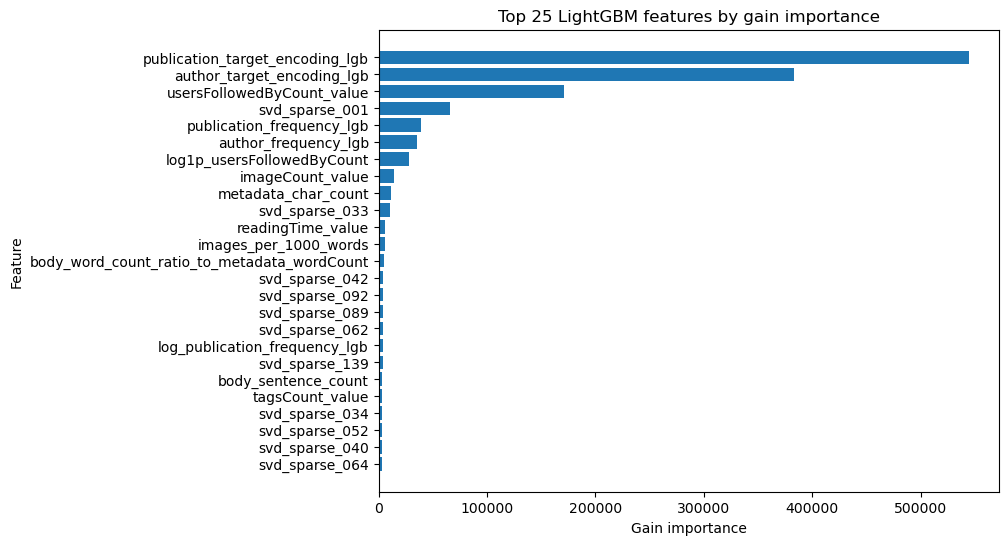

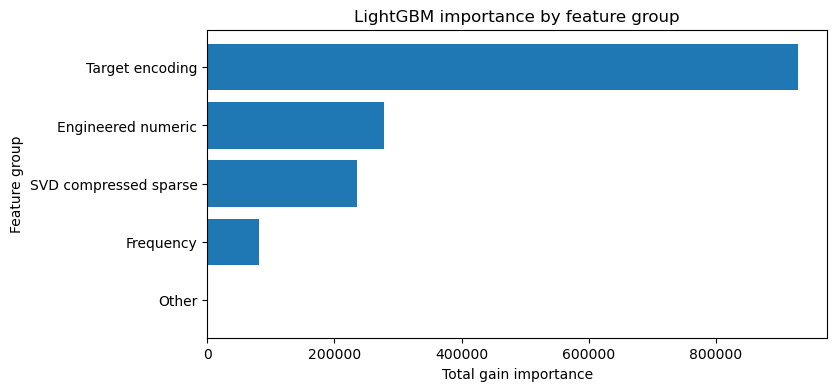

In [58]:
# Inspect LightGBM feature importance

feature_names = list(X_lgb_train_valid.columns)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "split_importance": final_lgbm_model.booster_.feature_importance(importance_type="split"),
    "gain_importance": final_lgbm_model.booster_.feature_importance(importance_type="gain"),
})

importance_df["gain_importance_normalized"] = (
    importance_df["gain_importance"]
    / importance_df["gain_importance"].sum()
)

def assign_feature_group(feature_name):
    if feature_name.startswith("svd_sparse_"):
        return "SVD compressed sparse"
    if "target_encoding" in feature_name:
        return "Target encoding"
    if "frequency" in feature_name:
        return "Frequency"
    if feature_name in numeric_feature_cols:
        return "Engineered numeric"
    return "Other"

importance_df["feature_group"] = importance_df["feature"].apply(assign_feature_group)

importance_df = importance_df.sort_values("gain_importance", ascending=False)

print("Top LightGBM features by gain importance:")
display(importance_df.head(30))

group_importance = (
    importance_df
    .groupby("feature_group", as_index=False)
    .agg(
        total_gain_importance=("gain_importance", "sum"),
        total_split_importance=("split_importance", "sum"),
        feature_count=("feature", "count"),
    )
    .sort_values("total_gain_importance", ascending=False)
)

group_importance["gain_importance_share"] = (
    group_importance["total_gain_importance"]
    / group_importance["total_gain_importance"].sum()
)

print("\nFeature-group importance:")
display(group_importance)


plt.figure(figsize=(8, 6))
top_features = importance_df.head(25).iloc[::-1]
plt.barh(top_features["feature"], top_features["gain_importance"])
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.title("Top 25 LightGBM features by gain importance")
plt.show()


plt.figure(figsize=(8, 4))
group_plot_df = group_importance.sort_values("total_gain_importance")
plt.barh(group_plot_df["feature_group"], group_plot_df["total_gain_importance"])
plt.xlabel("Total gain importance")
plt.ylabel("Feature group")
plt.title("LightGBM importance by feature group")
plt.show()


The LightGBM feature-importance analysis shows that the model relies most heavily on author/publication history, with additional signal from engineered numeric features and SVD-compressed sparse features.

The strongest individual features were:

| Feature | Meaning |
|---|---|
| `publication_target_encoding_lgb` | Smoothed historical average `log_claps` for the publication, computed from training data only |
| `author_target_encoding_lgb` | Smoothed historical average `log_claps` for the author, computed leakage-free |
| `usersFollowedByCount_value` | Cleaned numeric author follower-count feature from the dataset |
| `svd_sparse_001` | One compressed latent component from the high-dimensional sparse feature matrix |
| `publication_frequency_lgb` | Number of training articles associated with the publication |
| `author_frequency_lgb` | Number of training articles associated with the author |

The two target-encoding features dominate the LightGBM component:

| Feature group | Gain importance share |
|---|---:|
| Target encoding | **60.93%** |
| Engineered numeric | **18.25%** |
| SVD-compressed sparse features | **15.42%** |
| Frequency | **5.34%** |
| Other | **0.06%** |

At the individual-feature level, `publication_target_encoding_lgb` contributes about **35.75%** of total gain importance, while `author_target_encoding_lgb` contributes about **25.18%**. Together, these two features account for most of the LightGBM component’s gain importance. This suggests that historical author and publication engagement patterns are highly predictive in this dataset.

This result is reasonable for a Medium engagement task. Articles from publications or authors with stronger historical engagement are more likely to receive higher clap counts, while articles from less established or unseen authors/publications may be harder to predict.

The engineered numeric features also contribute meaningfully. The strongest numeric feature is `usersFollowedByCount_value`, which suggests that author reach is an important signal. Other useful numeric signals include image count, reading time, metadata length, sentence count, tag count, and other article-structure features.

The SVD-compressed sparse features contribute about **15.42%** of total gain importance. These features summarize the high-dimensional sparse representation used by Ridge, including text and categorical patterns. Individual SVD components are not directly interpretable like raw words or metadata fields, but their collective importance shows that compressed article-content signals still help LightGBM.

The frequency features contribute about **5.34%** of total gain importance. These features capture how often an author or publication appeared in the training data. They are less dominant than target encodings, but they still provide useful information about author/publication familiarity and historical coverage.

Overall, the feature-importance results support the final modeling strategy. The model is not relying only on article text, and it is not relying only on metadata. Instead, the LightGBM component combines:

- historical author/publication engagement strength
- author/publication frequency signals
- engineered article and author metadata
- SVD-compressed sparse article representation

Several caveats are important. First, gain importance is model-specific and should not be interpreted causally. A high-importance feature means LightGBM found the feature useful for prediction, not that the feature directly causes more claps. Second, feature importance can be affected by correlated predictors, especially when author frequency, publication frequency, and target encodings carry overlapping information. Third, this interpretation covers only the LightGBM component, not the full blended model, because Ridge still contributes **32%** of the final prediction.

Finally, target encoding is very influential. The encodings were built without validation/test target leakage, but because they dominate the LightGBM component, the next section runs an ablation experiment to measure how much performance depends on them. The strong importance of `usersFollowedByCount_value` should also be interpreted carefully because author metadata may reflect scrape-time information rather than publication-time information. A stricter launch-time production model should replace this with timestamped author-history features or remove it.

<details>
<summary><span style="color:red">
about this section:
</span></summary>  

This code cell inspects **which features the final LightGBM model used most**.

It does **not** explain the entire final blended model, because the final model is:

```text
0.32 × Ridge prediction + 0.68 × LightGBM prediction
```

But since LightGBM has the larger weight, looking at LightGBM feature importance helps us understand what the tree-based component relied on.


## 1. Get feature names

```python
feature_names = list(X_lgb_train_valid.columns)
```

`X_lgb_train_valid` is the final LightGBM training matrix used after combining train + validation data.

It contains the LightGBM feature columns, such as:

```text
engineered numeric features
author/publication frequency features
author/publication target encodings
SVD-compressed sparse features
```

This line stores all column names in a Python list so they can be matched with LightGBM’s importance values.


## 2. Create a feature-importance dataframe

```python
importance_df = pd.DataFrame({
    "feature": feature_names,
    "split_importance": final_lgbm_model.booster_.feature_importance(importance_type="split"),
    "gain_importance": final_lgbm_model.booster_.feature_importance(importance_type="gain"),
})
```

This creates a table with one row per LightGBM feature.

It includes two types of importance:

### `split_importance`

```python
importance_type="split"
```

This counts how many times a feature was used in tree splits.

For example, if `publication_target_encoding_lgb` was used in many tree decision rules, it will have high split importance.

But split importance only counts frequency. It does **not** tell us how useful those splits were.

### `gain_importance`

```python
importance_type="gain"
```

This measures how much a feature improved the model when it was used for splits.

In general, **gain importance is more informative** than split importance because it tells us which features contributed the most to reducing the model’s training objective.

So:

```text
split importance = how often the feature was used
gain importance = how useful the feature was when used
```

That is why we sort and plot features mainly by gain importance.


## 3. Normalize gain importance

```python
importance_df["gain_importance_normalized"] = (
    importance_df["gain_importance"]
    / importance_df["gain_importance"].sum()
)
```

This converts raw gain importance into a percentage-like share.

For example, if a feature has:

```text
gain_importance_normalized = 0.12
```

that means the feature accounts for about **12% of total gain importance**.

This makes it easier to compare features and feature groups.


## 4. Define feature groups

```python
def assign_feature_group(feature_name):
    if feature_name.startswith("svd_sparse_"):
        return "SVD compressed sparse"
    if "target_encoding" in feature_name:
        return "Target encoding"
    if "frequency" in feature_name:
        return "Frequency"
    if feature_name in numeric_feature_cols:
        return "Engineered numeric"
    return "Other"
```

This function assigns each feature to a broader feature group.

Instead of only looking at individual features, we also want to understand which **type** of feature mattered most.

The logic is:

### SVD features

```python
if feature_name.startswith("svd_sparse_"):
    return "SVD compressed sparse"
```

Features like:

```text
svd_sparse_000
svd_sparse_001
svd_sparse_002
```

are grouped as SVD-compressed sparse features.

These come from compressing the high-dimensional sparse TF-IDF/categorical matrix.


### Target-encoding features

```python
if "target_encoding" in feature_name:
    return "Target encoding"
```

Features like:

```text
author_target_encoding_lgb
publication_target_encoding_lgb
```

are grouped as target encoding.

These represent smoothed historical average `log_claps` values for authors or publications, built in a leakage-aware way.


### Frequency features

```python
if "frequency" in feature_name:
    return "Frequency"
```

Features like:

```text
author_frequency_lgb
log_author_frequency_lgb
publication_frequency_lgb
log_publication_frequency_lgb
```

are grouped as frequency features.

These tell LightGBM how often an author or publication appeared in the training data.


### Engineered numeric features

```python
if feature_name in numeric_feature_cols:
    return "Engineered numeric"
```

These are the manually engineered numeric features, such as:

```text
body_word_count
title_char_count
log1p_wordCount
is_weekend
hour_sin
links_per_1000_words
```


### Other

```python
return "Other"
```

This is a fallback group for any feature that does not match the previous rules.

Ideally, this group should be small or empty.


## 5. Apply the feature-group function

```python
importance_df["feature_group"] = importance_df["feature"].apply(assign_feature_group)
```

This creates a new column called:

```text
feature_group
```

Each feature is now labeled as one of:

```text
SVD compressed sparse
Target encoding
Frequency
Engineered numeric
Other
```


## 6. Sort by gain importance

```python
importance_df = importance_df.sort_values("gain_importance", ascending=False)
```

This sorts the feature table so the most important features by gain appear first.

That is why this line:

```python
display(importance_df.head(30))
```

shows the top 30 LightGBM features.


## 7. Display the top individual features

```python
print("Top LightGBM features by gain importance:")
display(importance_df.head(30))
```

This displays the 30 individual features with the highest gain importance.

This helps answer:

> Which specific LightGBM features contributed most to the model?

For example, if target-encoding features appear near the top, that suggests author/publication historical engagement signals were very useful.

If SVD features appear near the top, that suggests compressed text/categorical patterns added useful signal.


## 8. Aggregate importance by feature group

```python
# This code answers: Instead of asking which single feature was most important, which type of feature was most important overall?
group_importance = (
    importance_df
    .groupby("feature_group", as_index=False)
    .agg(
        total_gain_importance=("gain_importance", "sum"),
        total_split_importance=("split_importance", "sum"),
        feature_count=("feature", "count"),
    )
    .sort_values("total_gain_importance", ascending=False)
)
```

This groups the feature-importance table by feature type.

For each feature group, it calculates:

| Column                   | Meaning                                             |
| ------------------------ | --------------------------------------------------- |
| `total_gain_importance`  | Total gain from all features in that group          |
| `total_split_importance` | Total number of splits using features in that group |
| `feature_count`          | Number of features in that group                    |

This is useful because individual features can be noisy. Feature-group importance gives a more stable high-level view.

For example, instead of only asking:

> Was `author_target_encoding_lgb` important?

we can ask:

> How important were target-encoding features overall?


## 9. Calculate feature-group importance share

```python
group_importance["gain_importance_share"] = (
    group_importance["total_gain_importance"]
    / group_importance["total_gain_importance"].sum()
)
```

This converts each feature group’s total gain into a share of total gain.

For example, if the output shows:

```text
Target encoding = 0.6093
```

that means target-encoding features account for about **60.93%** of total LightGBM gain importance.

This makes the group-level interpretation easier.


## 10. Display feature-group importance

```python
print("\nFeature-group importance:")
display(group_importance)
```

This shows which feature groups contributed most to the LightGBM model.

Here, the group-level result showed that **target encoding was the largest feature group by gain importance**, followed by engineered numeric features, SVD-compressed sparse features, and frequency features.

That means LightGBM relied heavily on historical author/publication engagement signals, while also using row-level engineered features and compressed sparse text/categorical patterns.


## 11. Plot top 25 individual features

```python
plt.figure(figsize=(8, 6))
top_features = importance_df.head(25).iloc[::-1]
plt.barh(top_features["feature"], top_features["gain_importance"])
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.title("Top 25 LightGBM features by gain importance")
plt.show()
```

This creates a horizontal bar chart of the top 25 individual LightGBM features.

The line:

```python
top_features = importance_df.head(25).iloc[::-1]
```

takes the top 25 features and reverses their order so the most important feature appears at the top or in a more readable order in the horizontal plot.

This plot makes it easier to visually inspect which individual features dominate LightGBM.

## 12. Plot feature-group importance

```python
plt.figure(figsize=(8, 4))
group_plot_df = group_importance.sort_values("total_gain_importance")
plt.barh(group_plot_df["feature_group"], group_plot_df["total_gain_importance"])
plt.xlabel("Total gain importance")
plt.ylabel("Feature group")
plt.title("LightGBM importance by feature group")
plt.show()
```

This creates a horizontal bar chart showing total gain importance by feature group.

This is usually more interpretable than the individual-feature plot because it summarizes the model’s reliance on broad signal types.

It helps answer:

> Did LightGBM rely more on target encodings, engineered numeric features, SVD features, or frequency features?


## Important caution

Feature importance is useful, but it is not perfect.

We should not interpret it as:

> This feature causes more claps.

It only means:

> LightGBM used this feature often or gained predictive value from splits involving this feature.

Also, correlated features can share or distort importance. For example, author frequency, author target encoding, and publication target encoding may overlap in the information they provide.

So this section is best described as **model interpretation**, not causal analysis.

So:  

This section inspects the final LightGBM component using feature importance.

I calculate both split importance and gain importance. Split importance counts how often a feature is used in tree splits, while gain importance measures how much those splits improved the model objective. I focus mainly on gain importance because it better reflects how useful a feature was when selected.

I also group features into broader categories: engineered numeric features, author/publication frequency features, target-encoding features, and SVD-compressed sparse features. This makes the interpretation easier than looking only at individual feature names.

This analysis shows which signals the LightGBM component relied on most, but it should not be interpreted causally. A high-importance feature means the model found it useful for prediction, not that the feature directly causes higher engagement.


</details>

## Ablation check: LightGBM without target-encoding features

The feature-importance analysis showed that target-encoding features account for more than half of LightGBM’s total gain importance.

This is not necessarily a problem because the encodings are leakage-free with respect to validation and test targets:

- training rows use leave-one-out target encoding
- validation rows use statistics learned only from the training split
- test rows use statistics learned only from train + validation

Still, target encoding is so important that I measure how much it contributes. A stricter production system could also test rolling chronological encodings, especially if predictions must be made using only author/publication history available before each article’s publication time.

In this ablation experiment, I remove the target-encoding columns from the LightGBM validation feature matrices and train the same LightGBM configuration again. Then I compare:

- selected Ridge validation MAE
- full LightGBM validation MAE
- LightGBM without target encodings
- final Ridge/LightGBM blend validation MAE

This is a validation-only diagnostic. I do not use this result to retune the final test model.


Target-encoding columns removed:
['author_target_encoding_lgb', 'publication_target_encoding_lgb']

Feature matrix shapes:
Full LightGBM train shape:        (46261, 223)
No-target-encoding train shape:  (46261, 221)
Full LightGBM valid shape:        (9913, 223)
No-target-encoding valid shape:  (9913, 221)


,model,validation_mae
3,Final Ridge/LightGBM blend,1.090603
1,LightGBM full,1.120900
0,Selected Ridge,1.153614
2,LightGBM without target encoding,1.192705


Validation MAE comparison:
Selected Ridge:                 1.15361
Full LightGBM:                  1.12090
LightGBM without target enc.:   1.19271
Final blend:                    1.09060

Target-encoding contribution:
MAE increase without target encoding: 0.07181


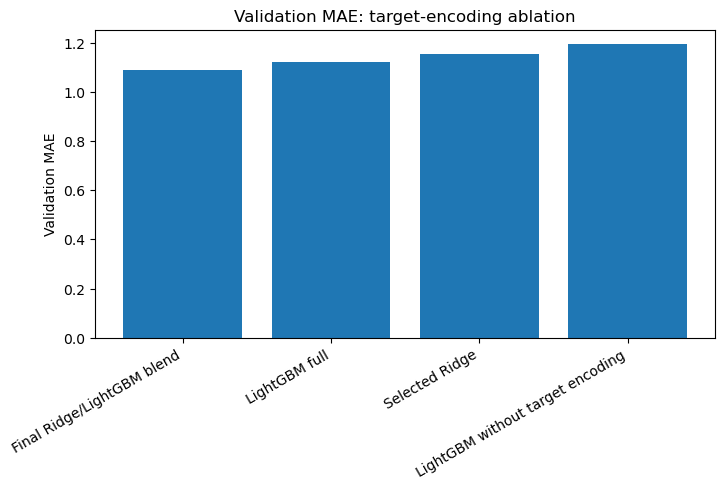

CPU times: user 20.1 s, sys: 14.2 s, total: 34.3 s
Wall time: 7.72 s


In [59]:
%%time

# Ablation check: LightGBM without target-encoding features

target_encoding_cols = [
    col for col in X_lgb_train.columns
    if "target_encoding" in col
]

print("Target-encoding columns removed:")
print(target_encoding_cols)

if len(target_encoding_cols) == 0:
    raise ValueError("No target-encoding columns found in X_lgb_train.")

X_lgb_train_no_te = X_lgb_train.drop(columns=target_encoding_cols)
X_lgb_valid_no_te = X_lgb_valid.drop(columns=target_encoding_cols)

print("\nFeature matrix shapes:")
print(f"Full LightGBM train shape:        {X_lgb_train.shape}")
print(f"No-target-encoding train shape:  {X_lgb_train_no_te.shape}")
print(f"Full LightGBM valid shape:        {X_lgb_valid.shape}")
print(f"No-target-encoding valid shape:  {X_lgb_valid_no_te.shape}")


# Use the same best LightGBM config selected earlier.
no_te_params = None

for config in lgbm_configs:
    if config["name"] == best_lgbm_config_name:
        no_te_params = config.copy()
        break

if no_te_params is None:
    raise ValueError(f"Could not find LightGBM config: {best_lgbm_config_name}")

no_te_params.pop("name")

# Use the same number of boosting rounds as the selected validation model.
no_te_params["n_estimators"] = int(lgbm_valid_model.best_iteration_)

lgbm_no_te_model = LGBMRegressor(
    **no_te_params,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

lgbm_no_te_model.fit(
    X_lgb_train_no_te,
    y_train_lgb,
)

lgb_valid_pred_no_te_raw = lgbm_no_te_model.predict(X_lgb_valid_no_te)

lgb_valid_pred_no_te = np.clip(
    lgb_valid_pred_no_te_raw,
    0,
    lgb_target_upper,
)

lgb_valid_mae_no_te = mean_absolute_error(
    y_valid,
    lgb_valid_pred_no_te,
)

ablation_results = pd.DataFrame([
    {
        "model": "Selected Ridge",
        "validation_mae": selected_ridge_valid_mae,
    },
    {
        "model": "LightGBM full",
        "validation_mae": lgb_valid_mae,
    },
    {
        "model": "LightGBM without target encoding",
        "validation_mae": lgb_valid_mae_no_te,
    },
    {
        "model": "Final Ridge/LightGBM blend",
        "validation_mae": best_blend_valid_mae,
    },
]).sort_values("validation_mae")

display(ablation_results)

print("Validation MAE comparison:")
print(f"Selected Ridge:                 {selected_ridge_valid_mae:.5f}")
print(f"Full LightGBM:                  {lgb_valid_mae:.5f}")
print(f"LightGBM without target enc.:   {lgb_valid_mae_no_te:.5f}")
print(f"Final blend:                    {best_blend_valid_mae:.5f}")

print("\nTarget-encoding contribution:")
print(f"MAE increase without target encoding: {lgb_valid_mae_no_te - lgb_valid_mae:.5f}")


plt.figure(figsize=(8, 4))
plt.bar(
    ablation_results["model"],
    ablation_results["validation_mae"],
)
plt.ylabel("Validation MAE")
plt.title("Validation MAE: target-encoding ablation")
plt.xticks(rotation=30, ha="right")
plt.show()

The target-encoding ablation confirms that author and publication history are important for LightGBM performance.

The full LightGBM model used two target-encoding features:

- `author_target_encoding_lgb`
- `publication_target_encoding_lgb`

The ablation removed exactly these two columns. This reduced the LightGBM feature matrix from **223** columns to **221** columns for both the training and validation sets.

After removing the target-encoding features, LightGBM validation performance became worse:

- Full LightGBM validation MAE: **1.12090**
- LightGBM without target encoding validation MAE: **1.19271**
- MAE increase: **0.07181**

This is a meaningful drop in performance. Relative to the full LightGBM validation MAE, the increase is about:

$$
\frac{0.07181}{1.12090} \approx 6.4\%
$$

So even though the absolute MAE difference may look modest, it represents a clear degradation in validation performance.

Without target encoding, LightGBM becomes worse than the selected Ridge baseline:

- Selected Ridge validation MAE: **1.15361**
- LightGBM without target encoding validation MAE: **1.19271**

This suggests that the leakage-free author/publication target encodings are a major reason why the full LightGBM model outperforms the Ridge baseline.

The final Ridge/LightGBM blend remains the best validation model:

- Final Ridge/LightGBM blend validation MAE: **1.09060**
- Full LightGBM validation MAE: **1.12090**
- Selected Ridge validation MAE: **1.15361**
- LightGBM without target encoding validation MAE: **1.19271**

One useful question is why performance did not collapse more. In the feature-importance section, target-encoding features accounted for about **60.93%** of LightGBM’s total gain importance. However, removing them increased validation MAE by **0.07181**, not by something much larger such as **0.30** or **0.50**.

This is because feature importance and ablation answer different questions. Feature importance asks: when target-encoding features are available, how much does LightGBM use them?   
Ablation asks: when target-encoding features are removed, how much can the remaining features compensate?

The model may rely heavily on target encodings when they are available, but other features still carry related signal. These include:

- `author_frequency_lgb`
- `publication_frequency_lgb`
- `usersFollowedByCount_value`
- `log1p_usersFollowedByCount`
- SVD-compressed sparse features
- engineered article metadata
- author and publication information indirectly represented through other feature blocks

Also, the no-target-encoding LightGBM model was not fully retuned. I reused the same selected LightGBM configuration and number of boosting rounds. This is useful for a controlled diagnostic because the main difference is the removal of target-encoding columns, but a fully retuned no-target-encoding model might recover some performance.

Because the target encodings were created without validation/test target leakage, they are valid features in this workflow. However, this ablation also shows that the model depends strongly on historical author/publication performance. If the model were applied to brand-new authors or publications, those target-encoding features would fall back toward the global mean, and performance could decrease.

Overall, the ablation supports keeping the target-encoding features in the final LightGBM model and confirms that the final Ridge/LightGBM blend is still the strongest validation model.

<details>
<summary><span style="color:red">
about this section:
</span></summary>  

This section is an **ablation experiment**.

An ablation means:

> Remove one important part of the model and measure how much performance gets worse.

Here, the removed part is:

```python
target-encoding features
```

The goal is to answer:

> How much does LightGBM depend on author/publication target encodings?


## 1. Find target-encoding columns

```python
target_encoding_cols = [
    col for col in X_lgb_train.columns
    if "target_encoding" in col
]
```

This searches the LightGBM training matrix for columns whose names contain:

```text
target_encoding
```

Here, these are:

```text
author_target_encoding_lgb
publication_target_encoding_lgb
```

These are the columns we want to remove for the ablation.


```python
print("Target-encoding columns removed:")
print(target_encoding_cols)
```

This prints the removed columns so the notebook clearly shows what was ablated.


```python
if len(target_encoding_cols) == 0:
    raise ValueError("No target-encoding columns found in X_lgb_train.")
```

This is a safety check.

If no target-encoding columns are found, the experiment would be meaningless. So the code stops with an error instead of silently continuing.

## 2. Remove target-encoding columns from train and validation

```python
X_lgb_train_no_te = X_lgb_train.drop(columns=target_encoding_cols)
X_lgb_valid_no_te = X_lgb_valid.drop(columns=target_encoding_cols)
```

This creates new LightGBM feature matrices without target-encoding columns.

So:

```text
X_lgb_train
```

contains all features, including target encoding.

But:

```text
X_lgb_train_no_te
```

contains everything except target encoding.

Same for validation.

This allows a fair comparison:

```text
LightGBM full feature set
vs.
LightGBM without target encodings
```

## 3. Print matrix shapes

```python
print("\nFeature matrix shapes:")
print(f"Full LightGBM train shape:        {X_lgb_train.shape}")
print(f"No-target-encoding train shape:  {X_lgb_train_no_te.shape}")
print(f"Full LightGBM valid shape:        {X_lgb_valid.shape}")
print(f"No-target-encoding valid shape:  {X_lgb_valid_no_te.shape}")
```

This confirms that the new matrices have fewer columns.

For example, if the full matrix has 223 columns and we remove 2 target-encoding columns, the no-target-encoding matrix should have 221 columns.

This is a useful sanity check.


## 4. Reuse the same best LightGBM configuration

```python
no_te_params = None

for config in lgbm_configs:
    if config["name"] == best_lgbm_config_name:
        no_te_params = config.copy()
        break
```

Earlier in the notebook, we tested several LightGBM configurations and selected the best one.

This loop finds that same best configuration again.

For example, if the best config was:

```text
l1_medium
```

then this block finds the dictionary for `l1_medium`.

The reason is:

> We want to test the effect of removing target encoding, not the effect of changing LightGBM hyperparameters.

So we keep the same selected LightGBM configuration.

```python
if no_te_params is None:
    raise ValueError(f"Could not find LightGBM config: {best_lgbm_config_name}")
```

This is another safety check.

If the selected config name cannot be found, the code stops instead of running an invalid comparison.


```python
no_te_params.pop("name")
```

The config dictionary contains a `"name"` key for tracking, but `LGBMRegressor` does not use a `name` parameter.

So this removes `"name"` before passing the dictionary into LightGBM.


## 5. Use the same number of boosting rounds

```python
no_te_params["n_estimators"] = int(lgbm_valid_model.best_iteration_)
```

This sets the number of trees for the ablation model to the same best iteration used by the selected full LightGBM model.

Earlier, LightGBM used early stopping to choose the best number of trees.

Here, instead of running early stopping again, the ablation model uses the same selected number of trees.

This keeps the comparison simpler and more controlled:

```text
same LightGBM config
same number of trees
only difference = target-encoding columns removed
```

## 6. Create the no-target-encoding LightGBM model

```python
lgbm_no_te_model = LGBMRegressor(
    **no_te_params,
    max_depth=-1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
```

This creates a new LightGBM model using the same parameters as the selected full LightGBM model.

### `**no_te_params`

This unpacks the parameter dictionary into the model.

For example:

```python
LGBMRegressor(**no_te_params)
```

is like writing:

```python
LGBMRegressor(
    objective="regression_l1",
    n_estimators=242,
    learning_rate=0.03,
    ...
)
```

depending on the selected config.

### `max_depth=-1`

No explicit tree-depth limit. Complexity is controlled by other parameters like `num_leaves`, `min_child_samples`, and regularization.

### `random_state=RANDOM_STATE`

Keeps results reproducible.

### `n_jobs=-1`

Uses all available CPU cores.

### `verbosity=-1`

Suppresses extra LightGBM logs.


## 7. Train the ablation model

```python
lgbm_no_te_model.fit(
    X_lgb_train_no_te,
    y_train_lgb,
)
```

This trains LightGBM on the training matrix **without target-encoding features**.

The target is still:

```text
y_train_lgb
```

which in here is:

```text
log_claps_clipped
```

So the only major change is the removed feature columns.


## 8. Predict on validation data

```python
lgb_valid_pred_no_te_raw = lgbm_no_te_model.predict(X_lgb_valid_no_te)
```

This creates validation predictions from the no-target-encoding LightGBM model.

These predictions are raw model outputs before clipping.


## 9. Clip predictions to the valid range

```python
lgb_valid_pred_no_te = np.clip(
    lgb_valid_pred_no_te_raw,
    0,
    lgb_target_upper,
)
```

This keeps predictions inside the valid target range.

The lower bound is:

```text
0
```

because:

```text
log1p(claps) cannot be negative
```

The upper bound is:

```text
lgb_target_upper
```

because LightGBM was trained on the clipped target:

```text
log_claps_clipped
```

So this keeps the ablation model’s predictions consistent with the same clipped-target setup used by the full LightGBM model.

## 10. Evaluate validation MAE

```python
lgb_valid_mae_no_te = mean_absolute_error(
    y_valid,
    lgb_valid_pred_no_te,
)
```

This calculates validation MAE for the LightGBM model without target encodings.

Important detail:

```text
The model is trained on y_train_lgb = log_claps_clipped,
but evaluated against y_valid = original log_claps.
```

That makes the result comparable to:

* selected Ridge
* full LightGBM
* final Ridge/LightGBM blend

## 11. Create comparison table

```python
ablation_results = pd.DataFrame([
    {
        "model": "Selected Ridge",
        "validation_mae": selected_ridge_valid_mae,
    },
    {
        "model": "LightGBM full",
        "validation_mae": lgb_valid_mae,
    },
    {
        "model": "LightGBM without target encoding",
        "validation_mae": lgb_valid_mae_no_te,
    },
    {
        "model": "Final Ridge/LightGBM blend",
        "validation_mae": best_blend_valid_mae,
    },
]).sort_values("validation_mae")
```

This creates a summary table comparing validation MAE across four models:

| Model                              | Meaning                                      |
| ---------------------------------- | -------------------------------------------- |
| `Selected Ridge`                   | Best Ridge baseline selected earlier         |
| `LightGBM full`                    | Best LightGBM model with all features        |
| `LightGBM without target encoding` | Ablation model with target encodings removed |
| `Final Ridge/LightGBM blend`       | Final validation-selected blend              |

Then:

```python
.sort_values("validation_mae")
```

sorts the table from best to worst.

Lower MAE is better.

```python
display(ablation_results)
```

This displays the comparison table in the notebook.

## 12. Print readable MAE comparison

```python
print("Validation MAE comparison:")
print(f"Selected Ridge:                 {selected_ridge_valid_mae:.5f}")
print(f"Full LightGBM:                  {lgb_valid_mae:.5f}")
print(f"LightGBM without target enc.:   {lgb_valid_mae_no_te:.5f}")
print(f"Final blend:                    {best_blend_valid_mae:.5f}")
```

This prints the same results in a compact text format.

It makes the conclusion easier to read.

## 13. Print target-encoding contribution

```python
print("\nTarget-encoding contribution:")
print(f"MAE increase without target encoding: {lgb_valid_mae_no_te - lgb_valid_mae:.5f}")
```

This calculates how much worse LightGBM gets when target encodings are removed.

The formula is:

```text
MAE increase = no-target-encoding LightGBM MAE - full LightGBM MAE
```

If this value is positive, removing target encoding made the model worse.

For example, if:

```text
Full LightGBM MAE = 1.12090
No-target-encoding MAE = 1.19271
```

then:

```text
MAE increase = 1.19271 - 1.12090 = 0.07181
```

That means target encodings improve LightGBM validation MAE by about **0.07181**.

## 14. Plot the ablation results

```python
plt.figure(figsize=(8, 4))
plt.bar(
    ablation_results["model"],
    ablation_results["validation_mae"],
)
plt.ylabel("Validation MAE")
plt.title("Validation MAE: target-encoding ablation")
plt.xticks(rotation=30, ha="right")
plt.show()
```

This creates a bar chart comparing validation MAE across the four models.

The plot makes it easy to see:

* whether removing target encoding hurts LightGBM
* how full LightGBM compares to Ridge
* whether the final blend is still best

## Why this experiment matters

The previous feature-importance section showed that target encoding was the most important LightGBM feature group.

This ablation checks whether that importance translates into actual validation performance.

The logic is:

```text
If removing target encoding barely changes MAE:
    target encoding looked important but may not be essential.

If removing target encoding makes MAE worse:
    target encoding is truly contributing useful predictive signal.
```

Here, the no-target-encoding model performs worse, so the experiment confirms that author/publication target encodings are meaningful for LightGBM.


So:  

This ablation experiment tests how much LightGBM depends on target-encoding features. I remove all columns containing `target_encoding` from the LightGBM train and validation matrices, then retrain the same selected LightGBM configuration using the same number of boosting rounds.

The comparison is designed to isolate the effect of target encoding: the model configuration, target, and validation metric stay the same, while only the target-encoding columns are removed.

The no-target-encoding model is evaluated against the original validation `log_claps` target, just like the full LightGBM model. The MAE increase shows how much validation performance is lost when author/publication historical engagement signals are removed.

</details>

## Saving the final model results and held-out predictions

At this point, the final model has been selected and evaluated.

The best model is the Ridge/LightGBM blend, using:

- clipped-target Ridge predictions
- LightGBM predictions trained on `log_claps_clipped`
- validation-selected blend weights
- validation-selected mean shift

The test set was used only for final reporting and diagnostics.

In this final step, I create two output files:

1. A model comparison table with validation MAE, test MAE, and prediction mean.
2. A held-out test prediction file containing article IDs, true values, predictions, residuals, and absolute errors.

These files make the results easier to inspect later and provide a clean final artifact for the notebook.

In [60]:
# ------------------------------------------------------------
# 1. Final model comparison table
# ------------------------------------------------------------

final_model_comparison = pd.DataFrame([
    {
        "model": "Selected Ridge",
        "validation_mae": selected_ridge_valid_mae,
        "test_mae": selected_ridge_test_mae,
        "test_prediction_mean": selected_ridge_test_pred.mean(),
    },
    {
        "model": "LightGBM",
        "validation_mae": lgb_valid_mae,
        "test_mae": lgb_test_mae,
        "test_prediction_mean": lgb_test_pred.mean(),
    },
    {
        "model": "Ridge/LightGBM blend",
        "validation_mae": best_blend_valid_mae,
        "test_mae": final_blend_test_mae,
        "test_prediction_mean": final_blend_test_pred.mean(),
    },
    {
        "model": "LightGBM without target encoding",
        "validation_mae": lgb_valid_mae_no_te,
        "test_mae": np.nan,
        "test_prediction_mean": np.nan,
    },
]).sort_values("test_mae", na_position="last")

display(final_model_comparison)

comparison_path = OUTPUT_DIR / "final_model_comparison.csv"
final_model_comparison.to_csv(comparison_path, index=False)

print(f"Final model comparison saved to: {comparison_path}")


# ------------------------------------------------------------
# 2. Held-out test prediction file
# ------------------------------------------------------------

final_test_predictions = test_df[[
    "post_id",
    "published_at",
    "title_text",
    "author_clean",
    "publication_clean",
    "claps",
    "log_claps",
]].copy()

final_test_predictions["pred_log_claps"] = final_blend_test_pred
final_test_predictions["pred_claps"] = np.expm1(final_test_predictions["pred_log_claps"])

final_test_predictions["residual_log"] = (
    final_test_predictions["pred_log_claps"]
    - final_test_predictions["log_claps"]
)

final_test_predictions["absolute_error_log"] = (
    final_test_predictions["residual_log"].abs()
)

final_test_predictions = final_test_predictions.sort_values(
    "absolute_error_log",
    ascending=False,
)

display(final_test_predictions.head(20))

predictions_path = OUTPUT_DIR / "final_blend_test_predictions.csv"
final_test_predictions.to_csv(predictions_path, index=False)

print(f"Final held-out test predictions saved to: {predictions_path}")


# ------------------------------------------------------------
# 3. Compact final report
# ------------------------------------------------------------

best_row = final_model_comparison.iloc[0]

print("\nFinal selected model:")
print(f"Model:              {best_row['model']}")
print(f"Validation MAE:     {best_row['validation_mae']:.5f}")
print(f"Held-out test MAE:  {best_row['test_mae']:.5f}")
print(f"Prediction mean:    {best_row['test_prediction_mean']:.5f}")
print(f"True test mean:     {y_test.mean():.5f}")

print("\nFinal blend settings:")
print(f"Ridge weight:       {best_blend_ridge_weight:.2f}")
print(f"LightGBM weight:    {best_blend_lgbm_weight:.2f}")
print(f"Use mean shift:     {best_blend_uses_shift}")
print(f"Blend mean shift:   {best_blend_shift:.5f}")


,model,validation_mae,test_mae,test_prediction_mean
2,Ridge/LightGBM blend,1.090603,1.028670,2.120454
1,LightGBM,1.120900,1.048089,2.176106
0,Selected Ridge,1.153614,1.107153,2.175902
3,LightGBM without target encoding,1.192705,NaN,NaN


Final model comparison saved to: medium_claps_outputs/final_model_comparison.csv


,post_id,published_at,title_text,author_clean,publication_clean,claps,log_claps,pred_log_claps,pred_claps,residual_log,absolute_error_log
8351,c10dde42037a,2018-09-23 11:00:06+00:00,Bots Vs Scambots — How AI can tackle online fr...,Jonas Karlberg jonaskarlberg,,2707.0,7.903966,0.819963,1.270415,-7.084003,7.084003
6776,8748dd907f60,2018-09-15 13:26:55+00:00,"Get Everybody Moving Hey everyone, G.E.M. here...",G.E.M. gemtang,,12141.0,9.404426,3.318754,26.625907,-6.085672,6.085672
1621,af4089ce0292,2018-08-22 05:41:10+00:00,Technologies That Influenced Startups in 2018 ...,"Netsmartz, LLC netsmartzllc",,452.0,6.115892,0.339370,0.404062,-5.776523,5.776523
3404,3eb8d22a51a6,2018-08-30 07:53:42+00:00,Can Õpet Foundation Change Education for the B...,Crypto Talk cryptotales50,,450.0,6.111467,0.478570,0.613765,-5.632897,5.632897
3523,760e48f473fc,2018-08-30 15:38:22+00:00,Join Us LIVE to Learn About Predictive Analyti...,Endor Protocol endorprotocol,Noteworthy - The Journal Blog did-you-know-the...,0.0,0.000000,5.614301,273.321456,5.614301,5.614301
6142,b504cf4e51a0,2018-09-12 14:55:47+00:00,The Future of Cloud Storage is Here BigMIND by...,Zoolz Zoolz,,891.0,6.793466,1.197337,2.311286,-5.596129,5.596129
9459,dfd851a0d014,2018-09-28 00:16:43+00:00,Oxymoron Can I please talk to a human,hannah miller slmiller116,,515.0,6.246107,0.664427,0.943377,-5.581680,5.581680
4097,df9b91a1381c,2018-09-02 17:57:25+00:00,Melior Team collaborates with e-commerce compa...,Melior.AI meliorAI,Melior.AI melior-ai,778.0,6.658011,1.152100,2.164831,-5.505911,5.505911
8212,56665af7e9fa,2018-09-22 07:01:05+00:00,The Power Of Your Voice Artificial Intelligent...,Huong Pham phamhuonghlp,,1910.0,7.555382,2.049520,6.764171,-5.505862,5.505862
7847,5e265ed9da0a,2018-09-20 13:55:22+00:00,"CONTACT: 42@melior.ai London, 11 September 201...",Melior.AI meliorAI,Melior.AI melior-ai,607.0,6.410175,0.919278,1.507479,-5.490897,5.490897


Final held-out test predictions saved to: medium_claps_outputs/final_blend_test_predictions.csv

Final selected model:
Model:              Ridge/LightGBM blend
Validation MAE:     1.09060
Held-out test MAE:  1.02867
Prediction mean:    2.12045
True test mean:     2.08826

Final blend settings:
Ridge weight:       0.32
LightGBM weight:    0.68
Use mean shift:     True
Blend mean shift:   -0.06047


The final model outputs were saved successfully.

Two output files were created:

- `medium_claps_outputs/final_model_comparison.csv`
- `medium_claps_outputs/final_blend_test_predictions.csv`

The final selected model is the **Ridge/LightGBM blend**.

Its final performance in the executed full-data run was:

- Validation MAE: **1.09060**
- Held-out test MAE: **1.02867**
- Test prediction mean: **2.12045**
- True test target mean: **2.08826**

The final blend settings were:

- Ridge weight: **0.32**
- LightGBM weight: **0.68**
- Mean shift used: **True**
- Blend mean shift: **-0.06047**

The saved prediction file includes the held-out test article IDs, titles, authors, publications, true clap counts, predicted clap values, residuals, and absolute errors. This makes the final results reproducible and easy to inspect after the notebook is finished.

The largest-error examples show the same pattern found during error analysis: the model still struggles with rare viral articles and some zero-clap articles that look popular based on their metadata or text. However, the final blended model is the best overall model in the notebook and gives the lowest held-out test MAE.


<details>
<summary><span style="color:red">
about this section:
</span></summary>  

This section saves the final results from the notebook into clean output files.

It does three things:

1. Creates a final model comparison table.
2. Creates a held-out test prediction file.
3. Prints a compact final report.


## 1. Final model comparison table

```python
final_model_comparison = pd.DataFrame([
    {
        "model": "Selected Ridge",
        "validation_mae": selected_ridge_valid_mae,
        "test_mae": selected_ridge_test_mae,
        "test_prediction_mean": selected_ridge_test_pred.mean(),
    },
    {
        "model": "LightGBM",
        "validation_mae": lgb_valid_mae,
        "test_mae": lgb_test_mae,
        "test_prediction_mean": lgb_test_pred.mean(),
    },
    {
        "model": "Ridge/LightGBM blend",
        "validation_mae": best_blend_valid_mae,
        "test_mae": final_blend_test_mae,
        "test_prediction_mean": final_blend_test_pred.mean(),
    },
    {
        "model": "LightGBM without target encoding",
        "validation_mae": lgb_valid_mae_no_te,
        "test_mae": np.nan,
        "test_prediction_mean": np.nan,
    },
]).sort_values("test_mae", na_position="last")
```

This creates a summary table comparing the main models.

Each row represents one model:

| Model                              | Meaning                                  |
| ---------------------------------- | ---------------------------------------- |
| `Selected Ridge`                   | The best Ridge baseline selected earlier |
| `LightGBM`                         | The final LightGBM model                 |
| `Ridge/LightGBM blend`             | The final blended model                  |
| `LightGBM without target encoding` | Validation-only ablation model           |

For each model, the table stores:

| Column                 | Meaning                                  |
| ---------------------- | ---------------------------------------- |
| `validation_mae`       | Validation MAE on `log1p(claps)`         |
| `test_mae`             | Held-out test MAE on `log1p(claps)`      |
| `test_prediction_mean` | Average test prediction on the log scale |

The ablation model has:

```python
"test_mae": np.nan
"test_prediction_mean": np.nan
```

because it was only used as a validation diagnostic. It was not evaluated on the test set.

This line:

```python
.sort_values("test_mae", na_position="last")
```

sorts the table by test MAE, with missing values placed last.

So the best test-performing evaluated model appears first.


## 2. Display and save the comparison table

```python
display(final_model_comparison)
```

This displays the table in the notebook.

```python
comparison_path = OUTPUT_DIR / "final_model_comparison.csv"
final_model_comparison.to_csv(comparison_path, index=False)
```

This saves the table as a CSV file.

The file name is:

```text
final_model_comparison.csv
```

inside our output directory.

```python
print(f"Final model comparison saved to: {comparison_path}")
```

This prints the saved file path so we can confirm where the file was written.


## 3. Create the held-out test prediction file

```python
final_test_predictions = test_df[[
    "post_id",
    "published_at",
    "title_text",
    "author_clean",
    "publication_clean",
    "claps",
    "log_claps",
]].copy()
```

This creates a new dataframe from the held-out test set.

It keeps useful columns for inspecting predictions:

| Column              | Meaning                             |
| ------------------- | ----------------------------------- |
| `post_id`           | Article identifier                  |
| `published_at`      | Article publication timestamp       |
| `title_text`        | Cleaned article title text          |
| `author_clean`      | Cleaned author field                |
| `publication_clean` | Cleaned publication field           |
| `claps`             | Actual raw clap count               |
| `log_claps`         | Actual target value, `log1p(claps)` |

The `.copy()` is used so changes to `final_test_predictions` do not accidentally modify `test_df`.


## 4. Add final model predictions

```python
final_test_predictions["pred_log_claps"] = final_blend_test_pred
```

This adds the final blended model prediction on the log scale.

This is the official prediction scale because the project predicts:

```text
log1p(claps)
```

not raw claps directly.


```python
final_test_predictions["pred_claps"] = np.expm1(final_test_predictions["pred_log_claps"])
```

This converts the predicted log values back to approximate raw claps for interpretability.

Since:

```python
log_claps = np.log1p(claps)
```

the inverse is:

```python
claps = np.expm1(log_claps)
```

So `pred_claps` is easier for humans to read, but the official model metric is still based on `pred_log_claps`.


## 5. Add residuals and absolute errors

```python
final_test_predictions["residual_log"] = (
    final_test_predictions["pred_log_claps"]
    - final_test_predictions["log_claps"]
)
```

This calculates signed prediction error on the log scale:

```text
residual_log = predicted log_claps - true log_claps
```

Interpretation:

|  Residual | Meaning              |
| --------: | -------------------- |
|  Positive | Model overpredicted  |
|  Negative | Model underpredicted |
| Near zero | Prediction was close |


```python
final_test_predictions["absolute_error_log"] = (
    final_test_predictions["residual_log"].abs()
)
```

This calculates the absolute error:

```text
absolute_error_log = |predicted log_claps - true log_claps|
```

This is the same kind of error that MAE averages.


## 6. Sort by largest errors

```python
final_test_predictions = final_test_predictions.sort_values(
    "absolute_error_log",
    ascending=False,
)
```

This sorts the test predictions so the largest errors appear first.

That makes the file useful for error analysis because we can immediately inspect the hardest articles.


```python
display(final_test_predictions.head(20))
```

This displays the 20 largest-error test predictions in the notebook.


## 7. Save the held-out prediction file

```python
predictions_path = OUTPUT_DIR / "final_blend_test_predictions.csv"
final_test_predictions.to_csv(predictions_path, index=False)
```

This saves the full held-out test prediction table as:

```text
final_blend_test_predictions.csv
```

This file contains all test articles with:

* article identifiers
* true claps
* true `log_claps`
* predicted `log_claps`
* back-transformed predicted claps
* residuals
* absolute errors

This is a clean final artifact because it lets us inspect predictions later without rerunning the full notebook.


```python
print(f"Final held-out test predictions saved to: {predictions_path}")
```

This prints the saved file path.


## 8. Compact final report

```python
best_row = final_model_comparison.iloc[0]
```

Because `final_model_comparison` was sorted by `test_mae`, the first row should be the best evaluated model by held-out test MAE.

So `best_row` stores the final selected model summary.

In our notebook, this should be the:

```text
Ridge/LightGBM blend
```

```python
print("\nFinal selected model:")
print(f"Model:              {best_row['model']}")
print(f"Validation MAE:     {best_row['validation_mae']:.5f}")
print(f"Held-out test MAE:  {best_row['test_mae']:.5f}")
print(f"Prediction mean:    {best_row['test_prediction_mean']:.5f}")
print(f"True test mean:     {y_test.mean():.5f}")
```

This prints the final model’s key metrics:

| Printed value       | Meaning                               |
| ------------------- | ------------------------------------- |
| `Model`             | Best evaluated model                  |
| `Validation MAE`    | Validation performance                |
| `Held-out test MAE` | Final test performance                |
| `Prediction mean`   | Average predicted `log_claps` on test |
| `True test mean`    | Average actual `log_claps` on test    |

Comparing prediction mean and true test mean helps check average calibration.


## 9. Print final blend settings

```python
print("\nFinal blend settings:")
print(f"Ridge weight:       {best_blend_ridge_weight:.2f}")
print(f"LightGBM weight:    {best_blend_lgbm_weight:.2f}")
print(f"Use mean shift:     {best_blend_uses_shift}")
print(f"Blend mean shift:   {best_blend_shift:.5f}")
```

This prints the settings used by the final blend.

In here, the final blend was:

```text
Ridge weight:    0.32
LightGBM weight: 0.68
```

That means the final prediction is approximately:

```text
final prediction =
0.32 × Ridge prediction
+ 0.68 × LightGBM prediction
+ optional mean shift
```

The mean shift is a validation-selected calibration adjustment. It is used only because it improved validation MAE.


## Why this section matters

This final saving section is important because it turns the notebook results into reusable artifacts.

Instead of only showing metrics inside the notebook, we save:

```text
final_model_comparison.csv
```

and:

```text
final_blend_test_predictions.csv
```

These files make the project easier to review, debug, and share.

So:  

This final section saves the main results as reusable artifacts. The model comparison table summarizes validation MAE, held-out test MAE, and prediction means for the evaluated models. The held-out prediction file stores article-level predictions, residuals, and absolute errors for the final Ridge/LightGBM blend.

The ablation model is included in the comparison table with validation MAE only because it was used as a validation diagnostic and was not evaluated on the held-out test set. The final selected model is the Ridge/LightGBM blend, which has the best held-out test MAE among the evaluated final models.

</details>

## Final summary and possible future improvements

This notebook built a Medium clap-prediction workflow using the MedData Medium dataset.

The target is `claps`, and the main modeling target is:

$$
\log(1 + \text{claps})
$$

The workflow included:

1. Loading and cleaning the Medium dataset.
2. Keeping a clean English-only supervised subset.
3. Exploring the target and raw features.
4. Engineering text, metadata, numeric, author, publication, and time features.
5. Building a chronological train/validation/test split.
6. Fitting TF-IDF vectorizers, categorical vectorizers, imputers, scalers, target encoders, and SVD models only on the appropriate training data.
7. Training a Ridge baseline on sparse features.
8. Testing a clipped-target Ridge model.
9. Training LightGBM on compact numeric, target-encoded, and SVD-compressed sparse features.
10. Blending Ridge and LightGBM using validation MAE.
11. Evaluating the final model on a held-out chronological test set.
12. Running error analysis, feature-importance interpretation, and a target-encoding ablation.
13. Saving final model comparison and prediction outputs.

The final selected model from the executed run was the shifted Ridge/LightGBM blend:

- Ridge weight: **0.32**
- LightGBM weight: **0.68**
- Validation-selected mean shift: **-0.06047**
- Final validation MAE: **1.09060**
- Final held-out test MAE: **1.02867**

This project demonstrates several portfolio-relevant machine learning practices:

- time-aware validation instead of a random split
- careful separation of train, validation, and test usage
- leakage-aware TF-IDF, target encoding, SVD, imputation, and scaling
- comparison of linear sparse modeling and nonlinear gradient boosting
- validation-selected blending and calibration
- model interpretation, error analysis, and ablation testing
- saved final artifacts for reproducibility

Possible future improvements include:

- using rolling or out-of-fold target encoding for stricter time-aware author/publication history
- replacing scrape-time author metadata with timestamped author-history features
- adding stronger semantic text embeddings, such as Sentence-BERT or transformer embeddings
- modeling zero-clap articles separately with a two-stage classifier + regressor
- experimenting with quantile loss or other objectives for long-tailed popularity
- tuning LightGBM hyperparameters more deeply
- testing separate models for low-, medium-, and high-clap articles
- checking performance on newer Medium data if a more recent dataset becomes available

Overall, the final model is a strong, leakage-aware baseline for predicting Medium article claps from article text, metadata, author/publication signals, and publication timing.
